# Stack Overflow 2025 Developer Survey: Salary & Job Satisfaction Analysis
## by Camila da Fonseca

## 1. Business Understanding

This project analyzes responses from thousands of developers worldwide collected in the 2025 Stack Overflow Developer Survey. The dataset encompasses a wide range of information, including demographics, education, professional experience, job satisfaction, salary levels, and the technologies used across different industries. By bringing together such diverse perspectives, the survey provides a rich foundation for identifying global trends, emerging preferences, and the challenges developers face in their careers.

The goal of this investigation is to explore the professional landscape of developers and examine how factors such as country, experience, technology stack, industry, and work arrangement shape key career outcomes.

The study investigates five central questions:
1. What is the expected annual salary (ConvertedCompYearly) given a developer’s country, years of experience, and technology stack?
2. Does industry affect salary and satisfaction independently of experience?
3. Is remote work associated with higher or lower salaries when controlling for country and experience?
4. Is high job satisfaction (JobSat ≥ 8) significantly influenced by factors such as remote work, management role, and experience level, after controlling for country and industry?   
   
The primary objective is to uncover patterns and trends that help distinguish how different groups of developers experience compensation, satisfaction, and work dynamics in the global tech ecosystem.

### 1.1 Dataset Overview

File type: *CSV file*

Method: *The data was download manually from Stack Overflow Survey web page ( https://survey.stackoverflow.co/).* 

**Dataset variables**

*  ResponseId (int64): Unique identifier for each survey response.
  
*  MainBranch (object): Primary professional identity of the respondent.\
   Observed values: “I am a developer by profession”, “I am not primarily a developer, but I write code sometimes”, etc.
  
*  Age (object): Reported age range of the respondent.\
   Observed values: “18–24 years old”, “25–34 years old”, “35–44 years old”, etc.
  
*  EdLevel (object): Highest level of formal education completed.\
   Observed values: “Bachelor’s degree”, “Master’s degree”, “Some college”, “Doctoral degree”.
  
*  Employment (object): Current employment status.\
   Observed values: “Employed full-time”, “Independent contractor”, “Unemployed”.
   
*  ConvertedCompYearly (float64): Annual compensation (salary) in USD, standardized across currencies.
  
*  WorkExp (float64): Number of years of professional coding experience.
  
*  YearsCode (object): Total years of coding experience (including learning and hobby).\
   Observed values: numeric values, “Less than 1 year”, “More than 50 years”.
  
*  Country (object): Country of residence.
  
*  OrgSize (object): Size of the respondent’s organization, measured in number of employees.\
   Observed values: “1–9 employees”, “100–499 employees”, “10,000 or more employees”.
  
*  DevType (object, multiple selection): Types of developer roles performed.\
   Examples: “Back-end developer”, “Front-end developer”, “Data scientist or machine learning specialist”.
  
*  LanguageHaveWorkedWith (object, multiple selection): Programming languages used in the past year.\
   Examples: “Python; JavaScript; SQL”.
  
*  LanguageWantToWorkWith (object, multiple selection): Programming languages developers want to work with in the future.
   
*  PlatformHaveWorkedWith (object, multiple selection): Platforms worked with.\
   Examples: "AWS", "Windows", "Linux".
   
*  AIModelsHaveWorkedWith (object, multiple selection): AI models or tools used by the respondent.\
   Examples: "GPT", "Gemini", "Claude".
   
*  AIThreat (object): Perception of whether AI threatens the developer’s job.\
   Observed values: “Yes”, “No”, “Unsure”.
  
*  AIAcc (object): Level of trust in AI accuracy.\
   Observed values: “I completely trust the accuracy”, “I somewhat trust the accuracy”, “I do not trust the accuracy”.

*  RemoteWork (object): Work arrangement.\
   Observed values: “Remote”, “Hybrid”, “In-person”.
  
*  Industry (object): Industry in which the respondent works.\
   Examples: “Software development”, “Finance”, “Healthcare”.
  
*  ICorPM (object): Whether the respondent is an Individual Contributor (IC) or People Manager (PM).

*  JobSat (object): Reported job satisfaction on a scale (1–10).
  
*  SOVisitFreq (object): Frequency of visiting Stack Overflow.\
   Observed values: “Daily”, “Weekly”, “Monthly or less”.

## 2. Data Understanding

### 2.1 Imports

In [1]:
# Standard library
import re
import os
from textwrap import shorten

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.signal import find_peaks

# Scikit-learn — Model Selection
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

# Scikit-learn — Linear Models
from sklearn.linear_model import (
    LassoCV,
    LinearRegression,
    LogisticRegressionCV,
    RidgeCV,
)

# Scikit-learn — Ensemble Models
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)

# Scikit-learn — Preprocessing
from sklearn.preprocessing import StandardScaler

# Scikit-learn — Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

print("All imports completed successfully!")

All imports completed successfully!


### 2.1 Data Loading

To ensure full reproducibility and avoid absolute file paths, the dataset 
`survey.csv` is stored in a `data/` folder at the project root. 

This notebook is located in the `notebook/` folder, so the dataset is loaded 
using a relative path (`../data/survey.csv`). This makes the project portable 
and allows it to run in any environment without modifying the code.

In [2]:
# Relative path from the notebook/ folder to the data/ folder
data_path = "../data/survey.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found. Expected file at '{data_path}'. "
        "Make sure 'survey.csv' is stored inside the 'data' folder at the project root."
    )

raw_data = pd.read_csv(data_path)
raw_data.head(1)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0


In [3]:
# Selection of necessary columns for analysis
columns = [
    "ConvertedCompYearly",      # Salary
    "Country",                  # Country
    "WorkExp",                  # Professional experience
    "YearsCode",                # Years of coding
    "EdLevel",                  # Education level
    "DevType",                  # Developer type (multi-select)
    "LanguageHaveWorkedWith",   # Languages used
    "OrgSize",                  # Organization size
    "Industry",                 # Industry
    "RemoteWork",               # Work arrangement
    "ICorPM",                   # IC or PM
    "JobSat"                    # Job satisfaction
]

df = raw_data[columns].copy()

# Check first rows
df.head(1)

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,ICorPM,JobSat
0,61256.0,Ukraine,8.0,14.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,People manager,10.0


### 2.3 Data Assess

Assess the data according to data quality and tidiness metrics.

#### 2.3.1 Quality Issues:

Inspecting the dataframe visually

In [4]:
# Display the first 5 rows of the DataFrame to inspect structure, columns, and initial values
df.head()

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,ICorPM,JobSat
0,61256.0,Ukraine,8.0,14.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,People manager,10.0
1,104413.0,Netherlands,2.0,10.0,"Associate degree (A.A., A.S., etc.)","Developer, back-end",Java,500 to 999 employees,Retail and Consumer Services,"Hybrid (some in-person, leans heavy to flexibi...",Individual contributor,9.0
2,53061.0,Ukraine,10.0,12.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, front-end",Dart;HTML/CSS;JavaScript;TypeScript,NaN,Software Development,NaN,NaN,8.0
3,36197.0,Ukraine,4.0,5.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end",Java;Kotlin;SQL,"10,000 or more employees",Retail and Consumer Services,Remote,Individual contributor,6.0
4,60000.0,Ukraine,21.0,22.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Engineering manager,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,NaN,Software Development,NaN,NaN,7.0


Inspecting the dataframe programmatically

In [5]:
# Check data types and non-null counts to detect missing values
# 'memory_usage="deep"' provides detailed memory consumption per column
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49123 entries, 0 to 49122
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ConvertedCompYearly     23928 non-null  float64
 1   Country                 35402 non-null  object 
 2   WorkExp                 42844 non-null  float64
 3   YearsCode               43000 non-null  float64
 4   EdLevel                 48087 non-null  object 
 5   DevType                 43636 non-null  object 
 6   LanguageHaveWorkedWith  31643 non-null  object 
 7   OrgSize                 34144 non-null  object 
 8   Industry                33607 non-null  object 
 9   RemoteWork              33747 non-null  object 
 10  ICorPM                  33211 non-null  object 
 11  JobSat                  26643 non-null  float64
dtypes: float64(4), object(8)
memory usage: 28.3 MB


In [6]:
# Check the number of missing (null) values in each column
df.isnull().sum()

ConvertedCompYearly       25195
Country                   13721
WorkExp                    6279
YearsCode                  6123
EdLevel                    1036
DevType                    5487
LanguageHaveWorkedWith    17480
OrgSize                   14979
Industry                  15516
RemoteWork                15376
ICorPM                    15912
JobSat                    22480
dtype: int64

**Insight: All columns have null values that need to be handled by either imputing or dropping them.** 

In [7]:
# Display the dataset's shape to understand its structure (rows, columns)
df.shape

(49123, 12)

In [8]:
# Display the data types of each column
df.dtypes

ConvertedCompYearly       float64
Country                    object
WorkExp                   float64
YearsCode                 float64
EdLevel                    object
DevType                    object
LanguageHaveWorkedWith     object
OrgSize                    object
Industry                   object
RemoteWork                 object
ICorPM                     object
JobSat                    float64
dtype: object

**Insight: Memory usage (31.7 MB) can be optimized by converting the `ConvertedCompYearly`, `WorkExp`, `YearsCode`, and `JobSat` columns from float to int data types.**


In [9]:
# Count the number of distinct (unique) values in each column
df.nunique()

ConvertedCompYearly        6234
Country                     177
WorkExp                      72
YearsCode                    78
EdLevel                       8
DevType                      32
LanguageHaveWorkedWith    15467
OrgSize                       9
Industry                     15
RemoteWork                    5
ICorPM                        2
JobSat                       11
dtype: int64

**Insight: The identified string columns -`Country`, `OrgSize`, `Industry`, `RemoteWork`, `ICorPM`, `DevType`, and `EdLevel`) contain repetitive values with low cardinality. Converting these to pandas' category data type will substantially reduce memory overhead while optimizing the performance of groupby and aggregation methods used during exploratory data analysis.**

In [10]:
# Check for duplicated rows in the dataset
df.duplicated().sum()

5510

**Insight: Duplicate entries were identified. Although the dataset uses unique ResponseId values, these redundant records add no new information and risk biasing the model by giving excessive weight to certain duplicated profiles.**

In [11]:
# Generate descriptive statistics summarizing central tendency, dispersion, and shape
df.describe()

,ConvertedCompYearly,WorkExp,YearsCode,JobSat
count,2.392800e+04,42844.000000,43000.000000,26643.000000
mean,1.017916e+05,13.370810,16.575256,7.202042
std,4.619345e+05,10.801917,11.789269,1.997234
min,1.000000e+00,1.000000,1.000000,0.000000
25%,3.817100e+04,5.000000,8.000000,6.000000
50%,7.538350e+04,10.000000,14.000000,8.000000
75%,1.206302e+05,20.000000,24.000000,8.000000
max,5.000000e+07,100.000000,100.000000,10.000000


In [12]:
# Display sorted unique values from the 'WorkExp' column
work_exp_values = df["WorkExp"].unique()
work_exp_values.sort()

print(work_exp_values)

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  63.  65.  66.  68.  69.  70.  75.  82.  88.
  99. 100.  nan]


In [13]:
# Display sorted unique values from the 'YearsCode' column
years_code_values = df["YearsCode"].unique()
years_code_values.sort()

print(years_code_values)

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  67.  68.  69.  70.  75.
  76.  78.  82.  89.  90.  98.  99. 100.  nan]


**Insight: Outliars entries were identified in `ConvertedCompYearly`, `WorkExp` and `YearsCode` columns.**

**Summary of data quality issues identified:**
*  Missing values handling
*  Data type optimization
*  Duplicate records
*  Outliers

#### 2.3.2 Tidiness Issues:

Inspecting the dataframe visually

In [14]:
# Display the last 5 rows of the DataFrame to inspect structure, columns, and values
df.tail()

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,ICorPM,JobSat
49118,NaN,NaN,9.0,13.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",NaN,500 to 999 employees,Software Development,"Hybrid (some remote, leans heavy to in-person)",Individual contributor,8.0
49119,NaN,NaN,13.0,15.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",NaN,"1,000 to 4,999 employees",NaN,"Hybrid (some remote, leans heavy to in-person)",Individual contributor,NaN
49120,NaN,NaN,2.0,NaN,"Secondary school (e.g. American high school, G...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
49121,NaN,France,10.0,14.0,"Associate degree (A.A., A.S., etc.)","Developer, full-stack",C#;SQL,20 to 99 employees,Manufacturing,"Hybrid (some remote, leans heavy to in-person)",Individual contributor,7.0
49122,NaN,Italy,10.0,15.0,Some college/university study without earning ...,"Developer, full-stack",NaN,Less than 20 employees,Software Development,"Your choice (very flexible, you can come in wh...",Individual contributor,8.0


Inspecting the dataframe programmatically

In [15]:
# Inspect columns that may contain multiple values separated by delimiters
potential_multi_value_cols = []

for column in df.columns:
    sample_values = df[column].dropna().head(10)

    # Search for common delimiters such as ';' or '|'
    if sample_values.astype(str).str.contains(r";|\|").any():
        potential_multi_value_cols.append(column)

print("Columns with possible multiple values:", potential_multi_value_cols)

Columns with possible multiple values: ['LanguageHaveWorkedWith']


#### Summary of data tidness issues identified:
*  Multiple variables stored in a single column

#### 2.3.3 Identified features engineering: 

In [16]:
# Display the frequency count of each unique value in the 'JobSat' column
df["JobSat"].value_counts()

JobSat
8.0     6964
7.0     5586
9.0     3595
6.0     3226
10.0    2921
5.0     1894
3.0      810
4.0      802
2.0      438
0.0      242
1.0      165
Name: count, dtype: int64

In [17]:
# Display the frequency count of each unique value in the 'RemoteWork' column
df["RemoteWork"].value_counts()

RemoteWork
Remote                                                                          10924
Hybrid (some remote, leans heavy to in-person)                                   6728
In-person                                                                        6034
Hybrid (some in-person, leans heavy to flexibility)                              5824
Your choice (very flexible, you can come in when you want or just as needed)     4237
Name: count, dtype: int64

In [18]:
# Display the frequency count of each unique value in the 'ICorPM' column
df["ICorPM"].value_counts()

ICorPM
Individual contributor    28315
People manager             4896
Name: count, dtype: int64

**Insight: The variables "JobSat" (scores ≥ 8 = high satisfaction), "RemoteWork" (flexible or not) and "ICorPM" (Individual contributor or not) can be converted to a binary representation (0/1) to enable clearer comparisons and model interpretation.**

In [19]:
# Display the frequency count of each unique value in the 'EdLevel' column
df["EdLevel"].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20247
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12575
Some college/university study without earning a degree                                 6175
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     3627
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2620
Associate degree (A.A., A.S., etc.)                                                    1560
Other (please specify):                                                                 701
Primary/elementary school                                                               582
Name: count, dtype: int64

In [20]:
# Display the frequency count of each unique value in the 'OrgSize' column
df["OrgSize"].value_counts()

OrgSize
20 to 99 employees                                    6680
100 to 499 employees                                  6104
Less than 20 employees                                5597
10,000 or more employees                              4959
1,000 to 4,999 employees                              4152
500 to 999 employees                                  2359
Just me - I am a freelancer, sole proprietor, etc.    1760
5,000 to 9,999 employees                              1604
I don’t know                                           929
Name: count, dtype: int64

**Insight: Using only dummy encoding for EdLevel and OrgSize would treat each variable as independent categories, disregarding their inherent hierarchical relationship. This approach fails to capture the progressive nature of the data.**

**Summary of identified feature engineering:**
*  Binary categorical feature
*  Ordinal categorical feature


## 3. Data Wrangling

### 3.1 Cleaning

#### 3.1.1 Quality Issues: Cleaning

##### 3.1.1.1 Missing values:

Since machine learning models cannot handle null values, the decision was made to drop rows containing missing data. This approach ensures a clean dataset for modeling and avoids the complexity of imputing values that could introduce bias or distort the true distribution of the features.

In [21]:
# Drop rows containing missing (NA) values
df = df.dropna()

In [22]:
# Check the number of missing (NA) values in each column
df.isna().sum()

ConvertedCompYearly       0
Country                   0
WorkExp                   0
YearsCode                 0
EdLevel                   0
DevType                   0
LanguageHaveWorkedWith    0
OrgSize                   0
Industry                  0
RemoteWork                0
ICorPM                    0
JobSat                    0
dtype: int64

##### 3.1.1.2 Data type optimization:

For numerical column that represent discrete values (annual salary, years of experience, and satisfaction scores) and are appropriately stored as integers to ensure optimal memory usage and efficient processing in machine learning models.\
Simultaneously, categorical columns -`Country`, `OrgSize`, `Industry`, `RemoteWork`, `ICorPM` and `EdLevel`- contain repetitive values with low cardinality. Converting these to pandas' category data type will substantially reduce memory overhead while optimizing the performance of groupby and aggregation methods used during exploratory data analysis.

In [23]:
# Check the maximum values for each selected numeric column
df[["ConvertedCompYearly", "WorkExp", "YearsCode", "JobSat"]].max()

ConvertedCompYearly    33552715.0
WorkExp                     100.0
YearsCode                   100.0
JobSat                       10.0
dtype: float64

In [24]:
# Check the minimum and maximum values that can be represented by int8
np.iinfo("int8")

iinfo(min=-128, max=127, dtype=int8)

In [25]:
# Check the minimum and maximum values that can be represented by int32
np.iinfo("int32")

iinfo(min=-2147483648, max=2147483647, dtype=int32)

In [26]:
# Convert the 'ConvertedCompYearly' column data type to int32
df[["ConvertedCompYearly"]] = df[["ConvertedCompYearly"]].astype("int32")

In [27]:
# Convert the 'WorkExp', 'YearsCode', and 'JobSat' columns data types to int8
df[["WorkExp", "YearsCode", "JobSat"]] = df[["WorkExp", "YearsCode", "JobSat"]].astype("int8")

In [28]:
# Convert selected columns' data types to 'category'
df[["Country", "OrgSize", "Industry", "RemoteWork", "ICorPM", "EdLevel"]] = (
    df[["Country", "OrgSize", "Industry", "RemoteWork", "ICorPM", "EdLevel"]]
    .astype("category")
)

In [29]:
# Check data types after casting and review memory usage optimization
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 15889 entries, 0 to 49010
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   ConvertedCompYearly     15889 non-null  int32   
 1   Country                 15889 non-null  category
 2   WorkExp                 15889 non-null  int8    
 3   YearsCode               15889 non-null  int8    
 4   EdLevel                 15889 non-null  category
 5   DevType                 15889 non-null  object  
 6   LanguageHaveWorkedWith  15889 non-null  object  
 7   OrgSize                 15889 non-null  category
 8   Industry                15889 non-null  category
 9   RemoteWork              15889 non-null  category
 10  ICorPM                  15889 non-null  category
 11  JobSat                  15889 non-null  int8    
dtypes: category(6), int32(1), int8(3), object(2)
memory usage: 3.0 MB


Insight: Memory usage reduced from 31.7 MB to 3 MB

##### 3.1.1.3 Duplicated records:

Since redundant entries with identical feature values provide no new information and may bias the model by overweighting certain profiles, dropping duplicate rows ensures a cleaner dataset, balanced representation, and more reliable machine learning outcomes.


In [30]:
# Drop duplicate rows from the dataset
df = df.drop_duplicates()

In [31]:
# Check the number of duplicated rows in the dataset
df.duplicated().sum()

0

##### 3.1.1.4 Outliers:

Since extreme values in features such as ConvertedCompYearly, WorkExp, and YearsCode can distort statistical distributions, inflate errors, and mislead the learning process, identifying and treating outliers ensures more robust models, stable training, and predictions that better reflect real-world patterns.


###### 3.1.1.4.1 Helper functions to identify and handle outliers:

In [32]:
def plot_distribution_analysis(df: pd.DataFrame, col: str) -> None:
    """
    Plot data normality diagnostics (histograms, boxplots, and Q-Q plots).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the data.
    col : str
        Column name for analysis.
    """
    # Filter data
    data = df[col]

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))

    # Original histogram
    sns.histplot(data, ax=axes[0, 0])
    axes[0, 0].set_title("Histogram - Original Scale")

    # Histogram (log1p)
    sns.histplot(np.log1p(data), ax=axes[0, 1])
    axes[0, 1].set_title("Histogram - Logarithmic Scale")

    # Original boxplot
    sns.boxplot(y=data, ax=axes[1, 0])
    axes[1, 0].set_title("Boxplot - Original Scale")

    # Boxplot (log1p)
    sns.boxplot(y=np.log1p(data), ax=axes[1, 1])
    axes[1, 1].set_title("Boxplot - Logarithmic Scale")

    # Original Q–Q plot
    stats.probplot(data, dist="norm", plot=axes[2, 0])
    axes[2, 0].set_title("Q-Q Plot - Original Scale")

    # Q–Q plot (log1p)
    stats.probplot(np.log1p(data), dist="norm", plot=axes[2, 1])
    axes[2, 1].set_title("Q-Q Plot - Logarithmic Scale")

    plt.tight_layout()
    plt.show()


In [33]:
def main_stats(df, col):
    """
    Perform initial exploratory analysis of a numeric column.

    This function prints key descriptive statistics and evaluates asymmetry
    by comparing the mean and median values.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    col : str
        The column name for analysis.

    Returns
    -------
    dict
        Dictionary containing basic statistics and asymmetry information.
    """
    print(f"{col} analysis")
    print(f"n = {len(df[col])}")
    print(f"Range: {df[col].max() - df[col].min():.2f}")

    mean_value = df[col].mean()
    median_value = df[col].median()
    asymmetry = mean_value - median_value

    print(f"Mean: {mean_value:.2f}")
    print(f"Median: {median_value:.2f}")
    print(f"Asymmetry (Mean vs Median): {asymmetry:.2f}")

    if abs(asymmetry) < (0.05 * mean_value):
        print("✓ Mean ≈ Median: Symmetric distribution")
    elif asymmetry > 0:
        print("↗ Mean > Median: Positive skewness (right-tailed)")
    else:
        print("↘ Mean < Median: Negative skewness (left-tailed)")

    std_dev = df[col].std()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    print(f"Standard deviation: {std_dev:.2f}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")

    return {
        "n": len(df[col]),
        "range": df[col].max() - df[col].min(),
        "mean": mean_value,
        "median": median_value,
        "asymmetry": asymmetry,
        "std_dev": std_dev,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
    }

In [34]:
def distribution_form(df, col):
    """
    Analyze the shape of a column's distribution.

    This function evaluates the distribution form using skewness and kurtosis,
    providing printed interpretations and returning their numeric values
    along with qualitative classifications.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    col : str
        Name of the column to analyze.

    Returns
    -------
    dict
        Dictionary with skewness and kurtosis values and their classifications.
    """
    skew_val = df[col].skew()
    kurtosis_val = df[col].kurtosis()

    print(f"{col} distribution analysis:")

    # Interpretation of skewness
    if abs(skew_val) < 0.5:
        skew_label = "symmetric"
    elif abs(skew_val) < 1:
        skew_label = "moderate_skew"
    else:
        skew_label = "strong_skew"

    print(f"Skewness: {skew_val:.3f} ({skew_label})")

    # Interpretation of kurtosis
    if kurtosis_val < -1:
        kurtosis_label = "light_tailed"
    elif kurtosis_val > 1:
        kurtosis_label = "heavy_tailed"
    else:
        kurtosis_label = "normal_tailed"

    print(f"Kurtosis: {kurtosis_val:.3f} ({kurtosis_label})")

    return {
        "skewness": round(skew_val, 3),
        "skewness_label": skew_label,
        "kurtosis": round(kurtosis_val, 3),
        "kurtosis_label": kurtosis_label,
    }

In [35]:
def normality_test(df, col, skewness_val=None, kurtosis_val=None):
    """
    Perform a normality test and classify the distribution.

    This function applies the D'Agostino–Pearson test to evaluate normality
    and combines it with skewness and kurtosis thresholds to classify the
    distribution as "normal", "near_normal", or "non_normal".

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data (already cleaned).
    col : str
        Name of the column to test.
    skewness_val : float, optional
        Pre-calculated skewness value. If None, it will be computed.
    kurtosis_val : float, optional
        Pre-calculated kurtosis value. If None, it will be computed.

    Returns
    -------
    str
        Distribution classification: "normal", "near_normal", or "non_normal".
    """
    data = df[col].dropna()

    # D'Agostino–Pearson normality test
    stat, p_value = stats.normaltest(data)

    # Compute skewness and kurtosis if not provided
    skewness_calc = skewness_val if skewness_val is not None else data.skew()
    kurtosis_calc = kurtosis_val if kurtosis_val is not None else data.kurtosis()

    # Classification based on multiple criteria
    if p_value > 0.05 and abs(skewness_calc) < 1.0 and abs(kurtosis_calc) < 2.0:
        classification = "normal"
    elif p_value > 0.01 or (abs(skewness_calc) < 1.5 and abs(kurtosis_calc) < 3.0):
        classification = "near_normal"
    else:
        classification = "non_normal"

    print(
        f"{col} → stat={stat:.3f}, p={p_value:.3f}, "
        f"skew={skewness_calc:.3f}, kurt={kurtosis_calc:.3f} → {classification}"
    )

    return classification

In [36]:
def choose_bins_method(
    n,
    data_range=None,
    data_std=None,
    iqr=None,
    skew_type=None,
    kurtosis_type=None,
    normality_type=None,
):
    """
    Select the most suitable binning method(s) based on data characteristics.

    This function recommends histogram binning methods according to
    sample size, skewness, kurtosis, and normality.

    Parameters
    ----------
    n : int
        Sample size.
    data_range : float, optional
        Range (max - min) of the data.
    data_std : float, optional
        Standard deviation of the data.
    iqr : float, optional
        Interquartile range of the data.
    skew_type : str, optional
        One of {"symmetric", "moderate_skew", "strong_skew"}.
    kurtosis_type : str, optional
        One of {"light_tailed", "normal_tailed", "heavy_tailed"}.
    normality_type : str, optional
        One of {"normal", "non_normal"}.

    Returns
    -------
    list of str
        List of recommended binning methods, ordered by preference.
    """
    if n <= 0:
        raise ValueError("Sample size must be positive")

    methods = []

    # Small samples (n < 100)
    if n < 100:
        if normality_type == "normal":
            methods.append("Sturges")
        else:
            if skew_type == "strong_skew":
                methods.append("Doane")
            elif kurtosis_type == "heavy_tailed":
                if iqr and data_range and iqr > 0:
                    if data_range / iqr > 4:
                        methods.append("Freedman-Diaconis")
                methods.append("Doane")
            else:
                methods.append("Square-Root")

    # Medium samples (100 ≤ n < 1000)
    elif n < 1000:
        if normality_type == "normal":
            if skew_type == "symmetric":
                methods.append("Scott")
            else:
                methods.append("Doane")
        else:
            if kurtosis_type == "heavy_tailed":
                if iqr:
                    methods.append("Freedman-Diaconis")
                methods.append("Doane")
            elif skew_type == "strong_skew":
                methods.append("Doane")
            elif skew_type == "moderate_skew":
                if data_std and iqr and data_std > 0:
                    if iqr / data_std < 1.3:
                        methods.append("Freedman-Diaconis")
                methods.append("Scott")
            else:
                methods.append("Scott")

    # Large samples (n ≥ 1000)
    else:
        if normality_type == "normal":
            methods.append("Scott")
        else:
            if kurtosis_type == "heavy_tailed" or skew_type == "strong_skew":
                if iqr:
                    methods.append("Freedman-Diaconis")
                methods.append("Scott")
            else:
                methods.append("Scott")

        # Rice as a robust alternative for large datasets
        methods.append("Rice")

    # Remove duplicates while preserving order
    seen = set()
    methods = [m for m in methods if not (m in seen or seen.add(m))]

    return methods

In [37]:
def compares_bins_methods(df, col):
    """
    Calculate the number of bins using different methods for histogram creation.

    This function compares several binning algorithms — including Sturges, Scott,
    Freedman–Diaconis, Doane, Rice, and Square-Root — to determine how each one
    would partition the data.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    col : str
        Name of the numeric column to analyze.

    Returns
    -------
    dict
        Dictionary with method names as keys and the corresponding number of bins as values.
    """
    n = len(df[col])
    methods = {
        "Sturges": len(np.histogram_bin_edges(df[col], bins="sturges")) - 1,
        "Scott": len(np.histogram_bin_edges(df[col], bins="scott")) - 1,
        "Freedman–Diaconis": len(np.histogram_bin_edges(df[col], bins="fd")) - 1,
        "Doane": len(np.histogram_bin_edges(df[col], bins="doane")) - 1,
        "Rice": int(np.ceil(2 * n ** (1 / 3))),
        "Square-Root": int(np.ceil(np.sqrt(n))),
    }

    return methods

In [38]:
def get_histogram_data(df, col, bins=None):
    """
    Return histogram data in the format (counts, bin_edges).

    This function wraps NumPy's `np.histogram` to generate the histogram
    counts and bin edges for a given column.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    col : str
        Name of the numeric column to analyze.
    bins : int or sequence or str, optional
        Number of bins or binning strategy to use. Default is None.

    Returns
    -------
    tuple of (numpy.ndarray, numpy.ndarray)
        Histogram counts and bin edges, in the same format as `np.histogram`.
    """
    return np.histogram(df[col], bins=bins)

In [39]:
def analyze_modality(histogram_data):
    """
    Analyze the modality (number of peaks) in histogram data.

    This function receives histogram output (counts, bin_edges) and detects
    the number of peaks using `scipy.signal.find_peaks`. It performs a
    two-pass detection: a strict first pass and a relaxed fallback.

    Parameters
    ----------
    histogram_data : tuple of (numpy.ndarray, numpy.ndarray)
        Histogram data in the format (counts, bin_edges), such as the
        output of `get_histogram_data`.

    Returns
    -------
    dict
        Dictionary containing:
        - modality : str
            One of {"unimodal", "bimodal", "multimodal_k", "no_peaks"}.
        - n_peaks : int
            Number of peaks detected.
    """
    counts, _ = histogram_data
    y = np.asarray(counts, dtype=float)

    # Light anti-aliasing to reduce noise between bins
    if y.size >= 3:
        y = np.convolve(y, np.ones(3) / 3, mode="same")

    # First pass (strict detection)
    peaks, _ = find_peaks(
        y,
        height=np.percentile(y, 75),
        distance=3,
        prominence=max(np.std(y) * 0.5, 1e-12),
    )

    # Fallback (more relaxed) if no peaks are found
    if len(peaks) == 0:
        peaks, _ = find_peaks(
            y,
            height=np.mean(y),
            distance=2,
            prominence=max(np.max(y) * 0.02, 1e-12),
        )

    n_peaks = int(len(peaks))

    if n_peaks == 0:
        modality = "no_peaks"
    elif n_peaks == 1:
        modality = "unimodal"
    elif n_peaks == 2:
        modality = "bimodal"
    else:
        modality = f"multimodal_{n_peaks}"

    return {
        "modality": modality,
        "n_peaks": n_peaks,
    }

In [40]:
def analyze_boundedness(df, col, mode="strict", custom_tolerance=None):
    """
    Classify the data support as 'nonnegative' or 'unbounded'.

    The decision is based on the fraction of negative values (considerando uma
    tolerância numérica adaptativa `eps`). Se a fração de negativos estiver
    abaixo de uma tolerância calculada, a variável é classificada como
    'nonnegative'; caso contrário, como 'unbounded'.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.
    col : str
        Nome da coluna a ser analisada.
    mode : {"strict", "lenient", "custom"}, default="strict"
        Define a tolerância máxima aceitável para negativos:
        - "strict"  : tolerâncias conservadoras (≤ 0.1% ou ≥ 1 ponto)
        - "lenient" : tolerâncias permissivas (≤ 1%   ou ≥ 5 pontos)
        - "custom"  : usa `custom_tolerance`
    custom_tolerance : float, optional
        Fração máxima de negativos permitida quando `mode="custom"`.
        Deve estar no intervalo [0, 0.5].

    Returns
    -------
    str
        "nonnegative" ou "unbounded".
    """
    values = df[col]
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    x = arr[finite]

    if x.size == 0:
        # Sem dados válidos: não é possível garantir limites
        return "unbounded"

    # --- tolerâncias ---
    if mode == "strict":
        max_frac, min_points = 0.001, 1  # 0.1% ou ≥ 1 ponto
    elif mode == "lenient":
        max_frac, min_points = 0.01, 5   # 1% ou ≥ 5 pontos
    elif mode == "custom" and custom_tolerance is not None:
        if not (0 <= custom_tolerance <= 0.5):
            raise ValueError("custom_tolerance must be in [0, 0.5].")
        max_frac, min_points = custom_tolerance, 1
    else:
        raise ValueError(
            "Invalid mode. Use 'strict', 'lenient', or 'custom' with custom_tolerance."
        )

    tol_frac = max(max_frac, min_points / x.size)

    # Tolerância numérica adaptativa
    data_scale = max(1.0, float(np.nanmax(np.abs(x))))
    eps = np.finfo(float).eps * data_scale * 10

    # Decisão baseada apenas em valores negativos (abaixo de -eps)
    pct_neg = float(np.mean(x < -eps))

    if pct_neg <= tol_frac:
        return "nonnegative"
    return "unbounded"

In [41]:
def pick_outlier_methods_ranked(
    n: int,
    skew_label: str,            # "symmetric" | "moderate_skew" | "strong_skew"
    tails_label: str,           # "light_tailed" | "normal_tailed" | "heavy_tailed"
    boundedness: str,           # "nonnegative" | "unbounded"
    modality: str = "unimodal", # "unimodal" | "bimodal" | "multimodal"
):
    """
    Return a ranked list of univariate outlier-detection methods by suitability.

    Parameters
    ----------
    n : int
        Sample size (not directly used in the ranking).
    skew_label : str
        One of {"symmetric", "moderate_skew", "strong_skew"}.
    tails_label : str
        One of {"light_tailed", "normal_tailed", "heavy_tailed"}.
    boundedness : str
        One of {"nonnegative", "unbounded"}.
    modality : str, default="unimodal"
        One of {"unimodal", "bimodal", "multimodal"}.

    Returns
    -------
    dict
        {
            "recommended_methods": list[dict],
            "suggested_transform": str | None
        }
    """
    s = skew_label.strip().lower().replace("-", "_")
    t = tails_label.strip().lower().replace("-", "_")
    b = boundedness.strip().lower().replace("-", "_")
    m = modality.strip().lower().replace("-", "_")  # kept for future use

    near_normal = s == "symmetric" and t == "normal_tailed"
    methods = []

    # Univariate methods

    # 1) Z-Score (best for normal)
    if near_normal:
        methods.append(
            {
                "method": "zscore",
                "params": {"threshold": 3.0},
                "priority": "high",
                "why": (
                    "Normal data: optimal classical method for detecting "
                    "extreme deviations"
                ),
            }
        )

    # 2) IQR (robust all-rounder)
    iqr_priority = "high" if not near_normal else "medium"
    base_k = 2.0 if (t == "heavy_tailed" or s == "strong_skew") else 1.5

    iqr_method = {
        "method": "iqr",
        "params": {"k": base_k},
        "priority": iqr_priority,
        "why": "Robust to non-normality and heavy tails",
    }

    # Add asymmetry if applicable
    if s != "symmetric":
        if s == "strong_skew":
            iqr_method["params"]["k_lower"] = 2.5
            iqr_method["params"]["k_upper"] = 1.8
            iqr_method["why"] += " with asymmetrical fences for strong asymmetry"
        else:
            iqr_method["params"]["k_lower"] = 2.0
            iqr_method["params"]["k_upper"] = 1.5
            iqr_method["why"] += " with asymmetrical fences for moderate asymmetry"

    methods.append(iqr_method)

    # 3) MAD — excellent for heavy-tailed
    if t == "heavy_tailed" or s == "strong_skew":
        methods.append(
            {
                "method": "mad",
                "params": {"threshold": 3.5},
                "priority": "high",
                "why": "More robust than IQR to very heavy tails and extreme outliers",
            }
        )

    # 4) Modified Z-Score — robust alternative to z-score
    if near_normal or t == "light_tailed":
        methods.append(
            {
                "method": "modified_zscore",
                "params": {"threshold": 3.5},
                "priority": "medium",
                "why": (
                    "Robust version of z-score using MAD, good for approximately "
                    "normal data"
                ),
            }
        )

    # 5) Quantile-based — conservative, good for exploratory
    methods.append(
        {
            "method": "quantile",
            "params": {"lower": 0.025, "upper": 0.975},
            "priority": "low",
            "why": "Conservative approach, independent of distribution",
        }
    )

    # Suggested transformations
    transform = None
    if not near_normal:
        if b == "nonnegative" and s in {"moderate_skew", "strong_skew"}:
            transform = "log1p"
        elif b == "unbounded" and s != "symmetric":
            transform = "yeo_johnson"

    # Ordering by priority
    priority_order = {"high": 0, "medium": 1, "low": 2}
    methods.sort(key=lambda x: priority_order[x["priority"]])

    return {"recommended_methods": methods, "suggested_transform": transform}

In [42]:
def remove_outliers_iqr_standard(df, column):
    """
    Identify and remove outliers from a column using the IQR method.

    This function removes extreme values that fall outside the
    interval [Q1 - 1.5 × IQR, Q3 + 1.5 × IQR].

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    column : str
        Name of the column to process.

    Returns
    -------
    pandas.DataFrame
        A copy of the DataFrame with outliers removed from the specified column.
    """
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[(df[column] >= lower) & (df[column] <= upper)].copy()

In [43]:
def remove_outliers_iqr_flex(df, column):
    """
    Remove outliers using a more flexible IQR-based method.

    This version applies asymmetrical thresholds, allowing for more tolerance
    on the upper tail — useful for distributions with mild right skewness.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    column : str
        Name of the column to process.

    Returns
    -------
    pandas.DataFrame
        A copy of the DataFrame with outliers removed from the specified column.
    """
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 2.5 * iqr
    upper = q3 + 1.8 * iqr

    return df[(df[column] >= lower) & (df[column] <= upper)].copy()

###### 3.1.1.4.2 ConvertedCompYearly outliars cleaning:

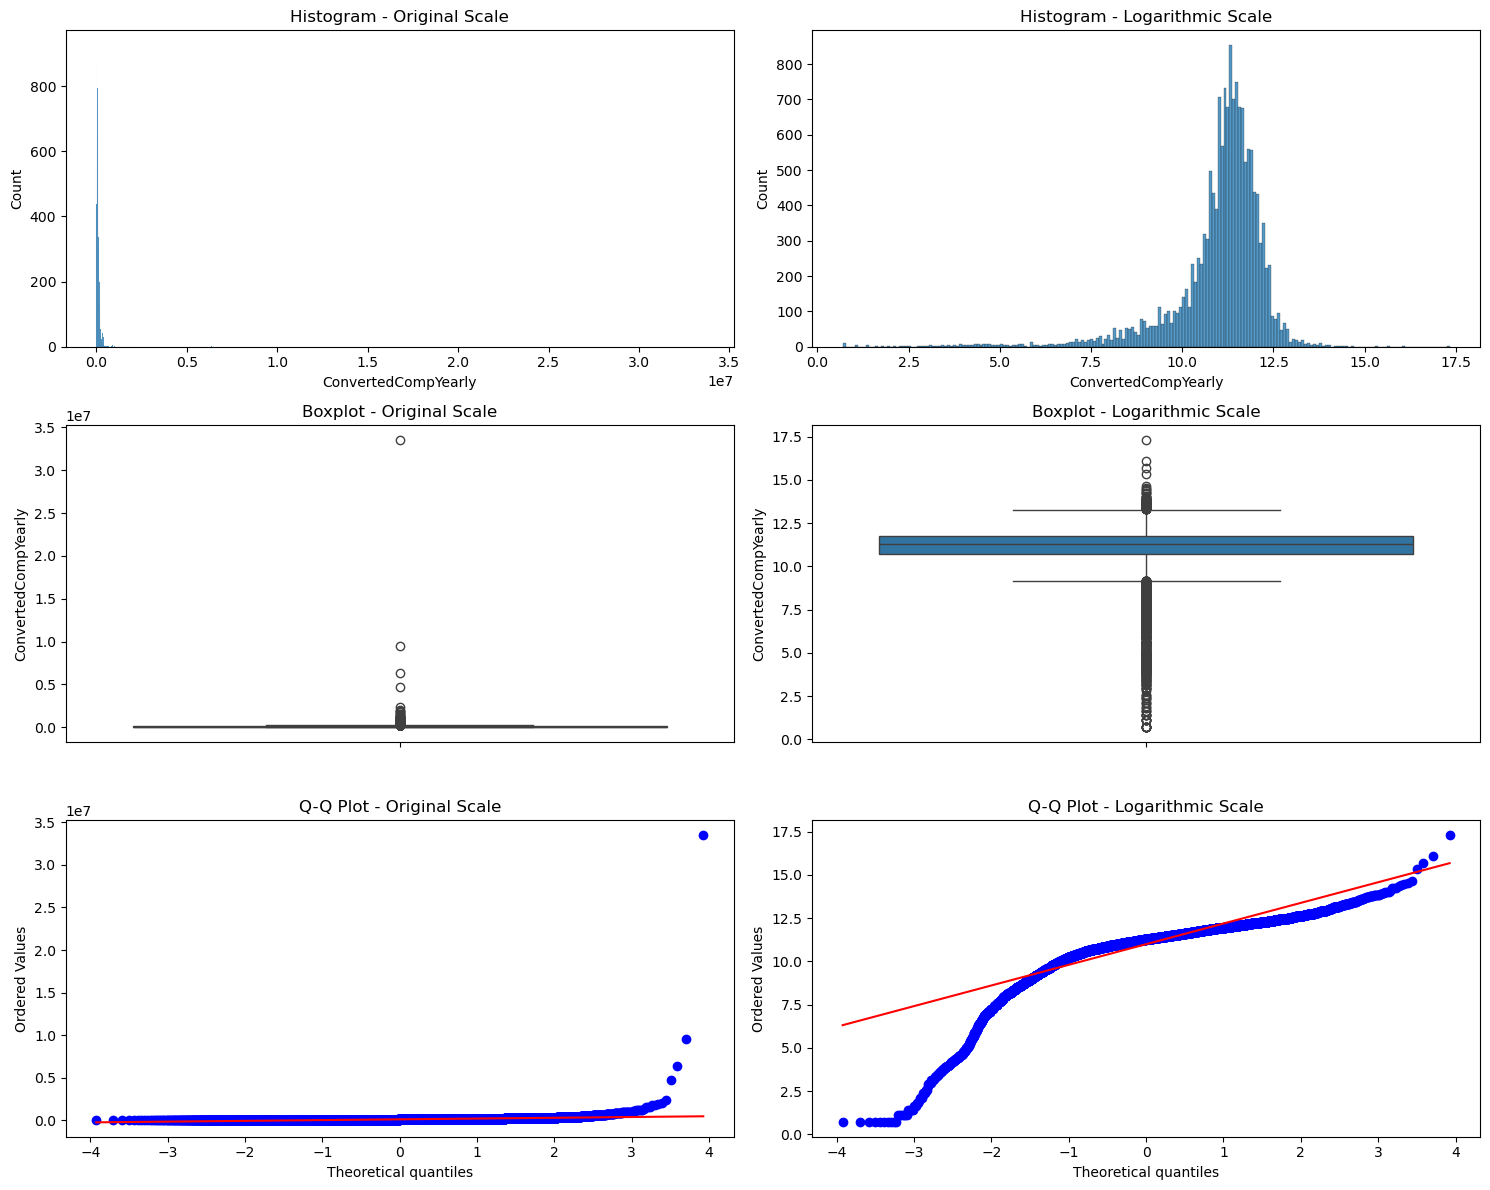

In [44]:
# Apply the function to visualize and understand the distribution of 'ConvertedCompYearly'
plot_distribution_analysis(df, "ConvertedCompYearly")

In [45]:
# Identify and remove the 4 largest values in 'ConvertedCompYearly' (treated as outliers)
index_remove = df["ConvertedCompYearly"].nlargest(4).index
df.drop(index=index_remove, inplace=True)

In [46]:
# Apply log1p transformation to 'ConvertedCompYearly' and store in a new column
df["LogConvertedCompYearly"] = np.log1p(df["ConvertedCompYearly"])

The natural logarithm (base *e*) was applied to the ConvertedCompYearly variable using np.log1p to handle its strong positive skew. This is the standard approach in machine learning for normalizing such distributions due to its mathematical properties in the context of regression. While a base-10 logarithm can be more intuitive for human interpretation in visualizations.

In [47]:
# Apply the function to calculate main statistics for 'LogConvertedCompYearly'
main_stats(df, "LogConvertedCompYearly")

LogConvertedCompYearly analysis
n = 15883
Range: 13.98
Mean: 11.00
Median: 11.29
Asymmetry (Mean vs Median): -0.29
✓ Mean ≈ Median: Symmetric distribution
Standard deviation: 1.35
Q1: 10.71
Q3: 11.74
IQR: 1.03


{'n': 15883,
 'range': 13.975075553892982,
 'mean': 10.997104563714144,
 'median': 11.289794413577894,
 'asymmetry': -0.29268984986375024,
 'std_dev': 1.3496950290812777,
 'q1': 10.706811133741756,
 'q3': 11.736077016252437,
 'iqr': 1.029265882510682}

In [48]:
# Apply the function to analyze the distribution shape (skewness and kurtosis)
distribution_form(df, "LogConvertedCompYearly")

LogConvertedCompYearly distribution analysis:
Skewness: -2.697 (strong_skew)
Kurtosis: 11.666 (heavy_tailed)


{'skewness': -2.697,
 'skewness_label': 'strong_skew',
 'kurtosis': 11.666,
 'kurtosis_label': 'heavy_tailed'}

In [49]:
# Apply the function to perform the normality test on 'LogConvertedCompYearly'
normality_test(df, "LogConvertedCompYearly", -2.803, 12.749)

LogConvertedCompYearly → stat=9458.091, p=0.000, skew=-2.803, kurt=12.749 → non_normal


'non_normal'

In [50]:
# Apply the function to determine the most suitable method for calculating the number of bins
choose_bins_method(
    13102,
    13.975075553892982,
    1.310784023712217,
    1.0300918328110527,
    "strong_skew",
    "heavy_tailed",
    "non_normal",
)

['Freedman-Diaconis', 'Scott', 'Rice']

In [51]:
# Apply the function to compare the number of bins across different calculation methods
compares_bins_methods(df, "LogConvertedCompYearly")

{'Sturges': 15,
 'Scott': 75,
 'Freedman–Diaconis': 171,
 'Doane': 23,
 'Rice': 51,
 'Square-Root': 127}

In [52]:
# Get histogram data for 'LogConvertedCompYearly' in the format (counts, bin_edges)
dados_hist = get_histogram_data(df, "LogConvertedCompYearly", 53)

In [53]:
# Apply the function to analyze the modality (number of peaks) of the distribution
analyze_modality(dados_hist)

{'modality': 'unimodal', 'n_peaks': 1}

In [54]:
# Apply the function to analyze the boundedness of 'LogConvertedCompYearly'
analyze_boundedness(df, "LogConvertedCompYearly", mode="strict")

'nonnegative'

In [55]:
# Apply the function to identify the most suitable outlier detection methods
pick_outlier_methods_ranked(13106, "strong_skew", "heavy_tailed", "nonnegative", "unimodal")

{'recommended_methods': [{'method': 'iqr',
   'params': {'k': 2.0, 'k_lower': 2.5, 'k_upper': 1.8},
   'priority': 'high',
   'why': 'Robust to non-normality and heavy tails with asymmetrical fences for strong asymmetry'},
  {'method': 'mad',
   'params': {'threshold': 3.5},
   'priority': 'high',
   'why': 'More robust than IQR to very heavy tails and extreme outliers'},
  {'method': 'quantile',
   'params': {'lower': 0.025, 'upper': 0.975},
   'priority': 'low',
   'why': 'Conservative approach, independent of distribution'}],
 'suggested_transform': 'log1p'}

In [56]:
# Apply outlier detection functions to 'LogConvertedCompYearly'
comp_iqr_std = remove_outliers_iqr_standard(df, "LogConvertedCompYearly")
comp_iqr_flex = remove_outliers_iqr_flex(df, "LogConvertedCompYearly")

In [57]:
# Check the min and max values of 'ConvertedCompYearly' after applying outlier removal functions
print(f"max iqr_std: {comp_iqr_std['ConvertedCompYearly'].max()}")
print(f"min iqr_std: {comp_iqr_std['ConvertedCompYearly'].min()}")
print(f"max iqr_flex: {comp_iqr_flex['ConvertedCompYearly'].max()}")
print(f"min iqr_flex: {comp_iqr_flex['ConvertedCompYearly'].min()}")

max iqr_std: 585000
min iqr_std: 9553
max iqr_flex: 780000
min iqr_flex: 3422


**Outlier policy for compensation data:**

The 1.5×IQR method was selected to establish consistent limits for the global compensation base. The alternative approach (2×IQR) resulted in an excessively wide range, accepting values from `$3.5k/year` to `$788k/year`, which include unrealistic compensation for the contexts analyzed.

The 1.5×IQR criterion, in turn, establishes a minimum of `$9.9k` and a maximum of `$600k`. This minimum limit may be plausible when considering the influence of different groups and economic realities in the research. For example, an annual salary of `$9.9k` (approximately R$4k/month, depending on the exchange rate) may reflect the compensation of a junior professional in Brazil, a value within the local reality. While for the maximum limit, a significant minority of developers—especially senior professionals in countries like the United States or at large technology companies—report legitimately high earnings. This group includes compensation that combines salary, substantial bonuses, and stock options. The `$600,000` threshold was set to preserve these real high-earning cases, which are statistically relevant, without distorting the analysis with excessively extreme and potentially erroneous values.

Thus, the 1.5×IQR method more effectively balances the statistical robustness of the data with the representativeness of the diverse economic realities present in the multi-country study, ensuring that the analysis reflects both the majority wage base and legitimate high-earning cases.

In [58]:
# Apply the IQR (k=1.5) outlier removal function to the DataFrame
df = remove_outliers_iqr_standard(df, "LogConvertedCompYearly")

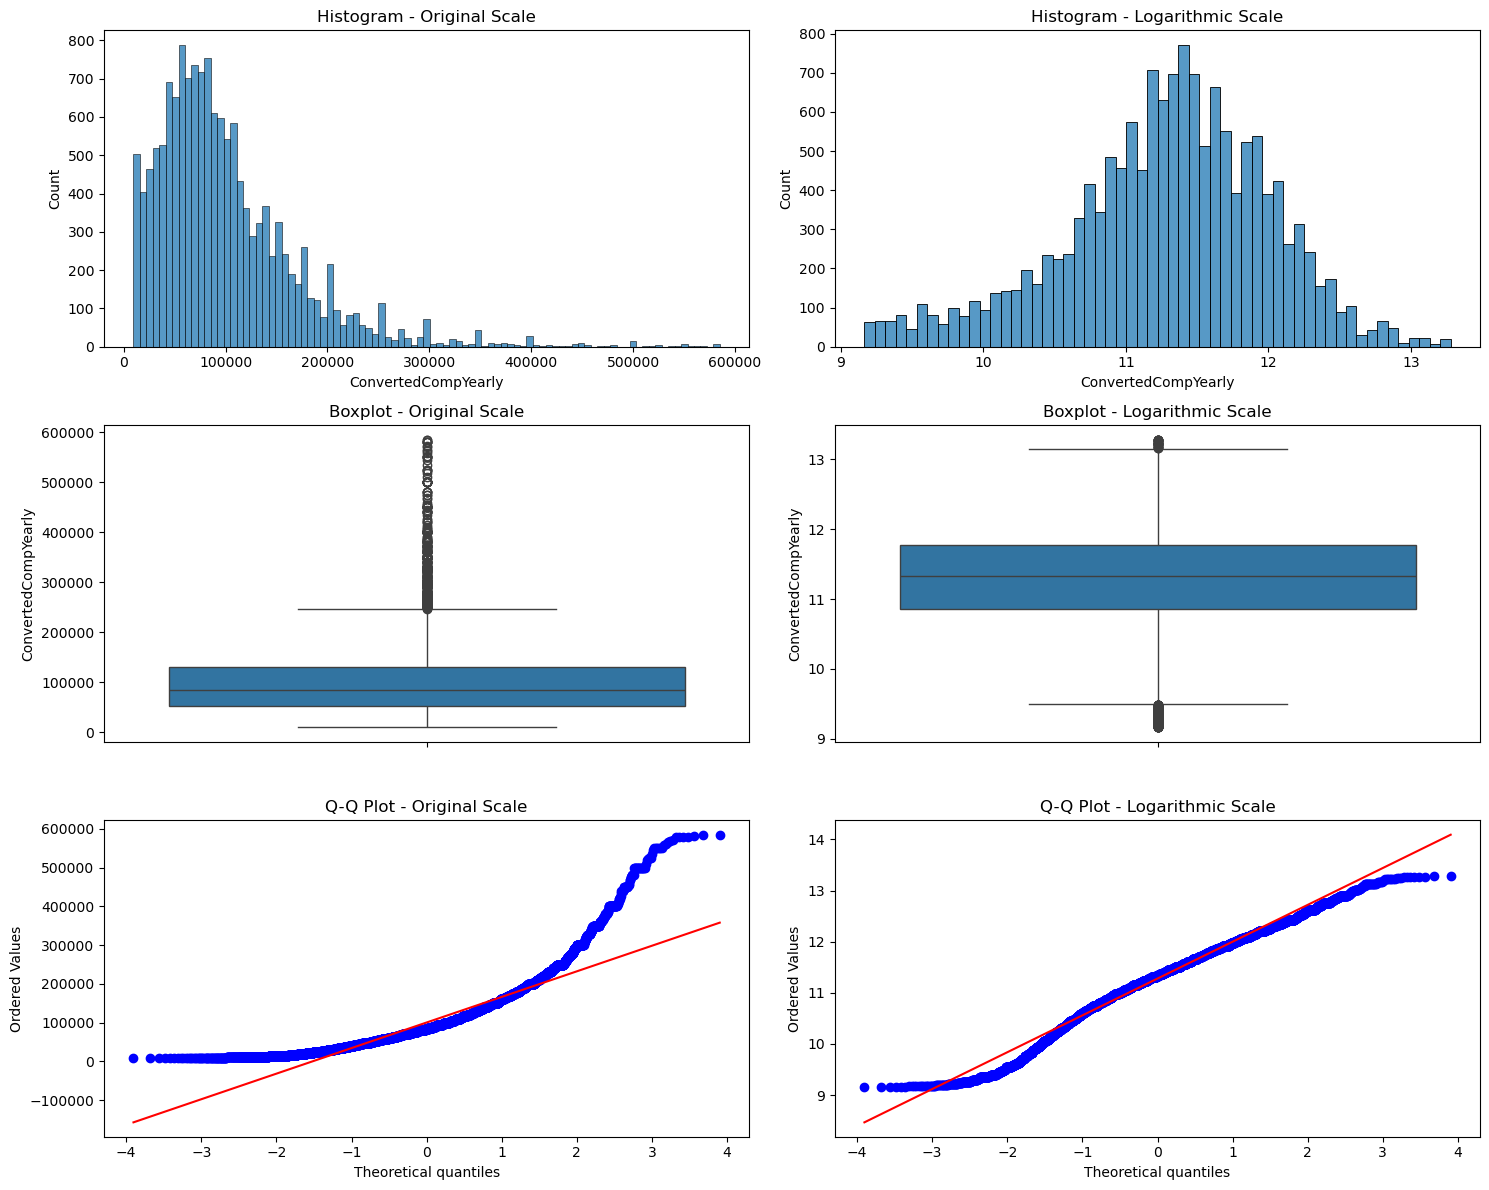

In [59]:
# Apply the function to visualize the final distribution of 'ConvertedCompYearly'
plot_distribution_analysis(df, "ConvertedCompYearly")

In [60]:
# Check the results after applying the outlier removal function
print(f"max: {df['ConvertedCompYearly'].max()}")
print(f"min: {df['ConvertedCompYearly'].min()}")

max: 585000
min: 9553


###### 3.1.1.4.3 WorkExp outliars cleaning:

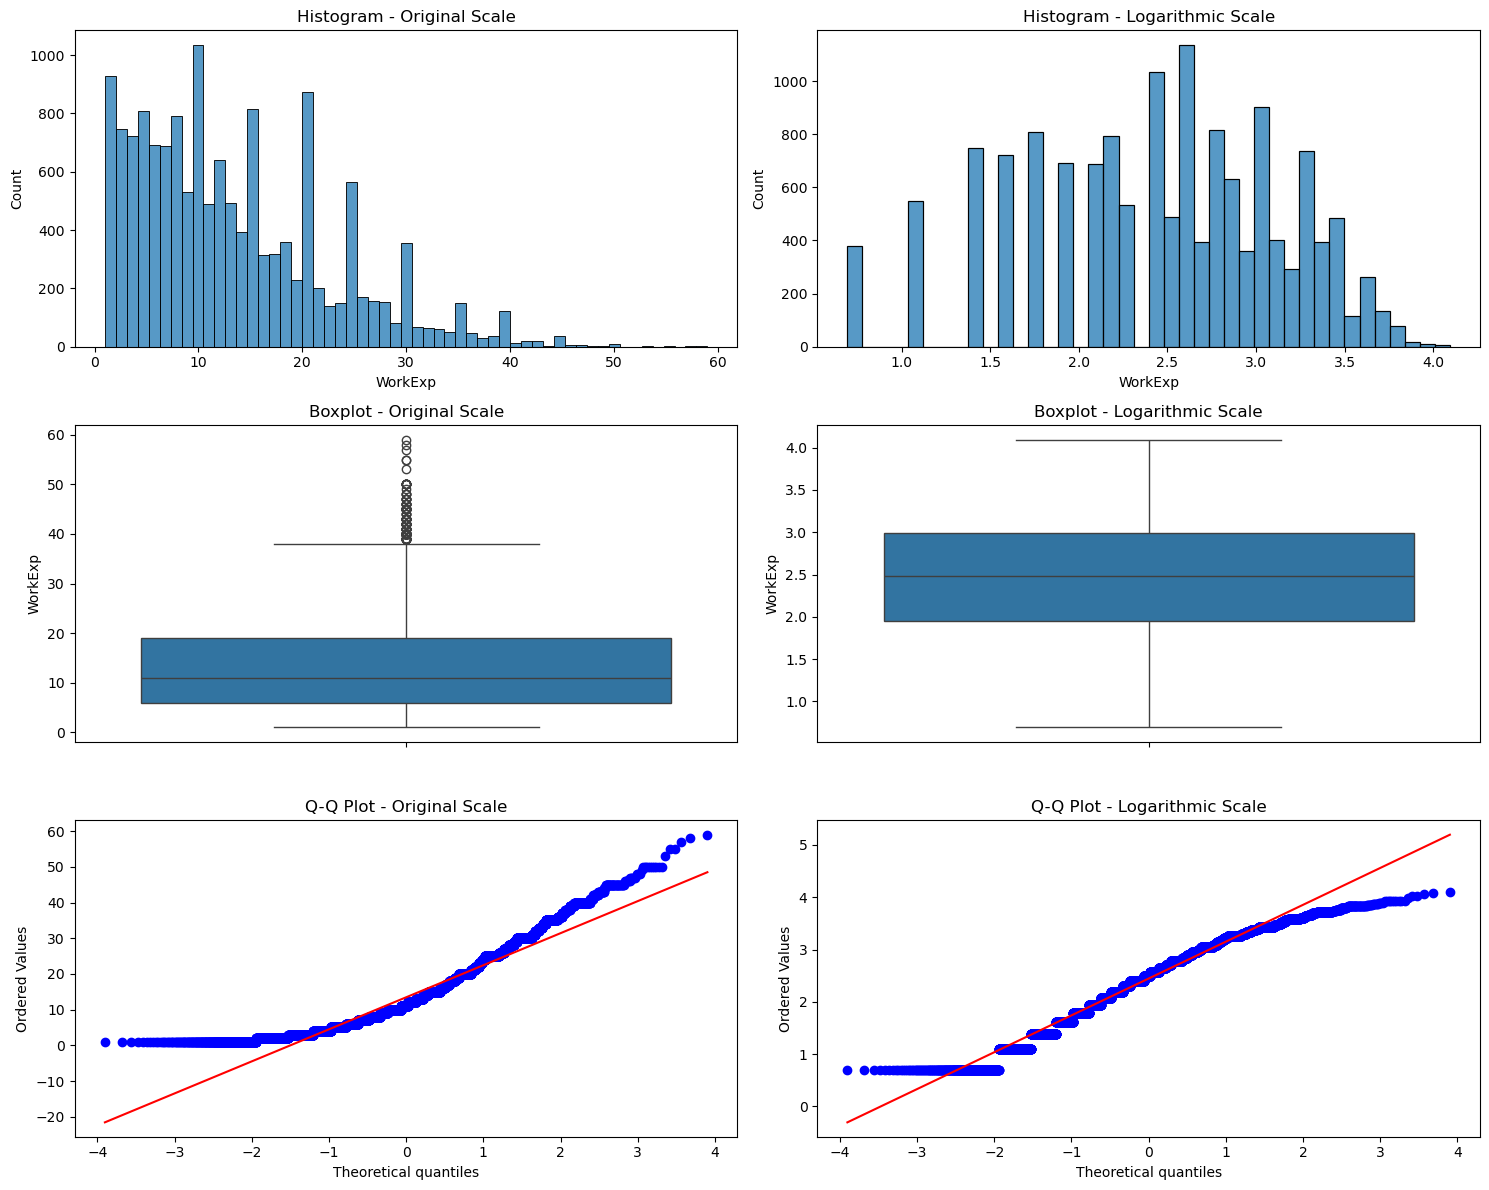

In [61]:
# Apply the function to visualize and understand the distribution of 'WorkExp'
plot_distribution_analysis(df, "WorkExp")

In [62]:
# Apply the function to perform initial exploratory statistical analysis on 'WorkExp'
main_stats(df, "WorkExp")

WorkExp analysis
n = 14591
Range: 58.00
Mean: 13.46
Median: 11.00
Asymmetry (Mean vs Median): 2.46
↗ Mean > Median: Positive skewness (right-tailed)
Standard deviation: 9.33
Q1: 6.00
Q3: 19.00
IQR: 13.00


{'n': 14591,
 'range': 58,
 'mean': 13.458981563977794,
 'median': 11.0,
 'asymmetry': 2.458981563977794,
 'std_dev': 9.334369048980557,
 'q1': 6.0,
 'q3': 19.0,
 'iqr': 13.0}

In [63]:
# Apply the function to analyze the distribution shape (skewness and kurtosis) of 'WorkExp'
distribution_form(df, "WorkExp")

WorkExp distribution analysis:
Skewness: 0.972 (moderate_skew)
Kurtosis: 0.600 (normal_tailed)


{'skewness': 0.972,
 'skewness_label': 'moderate_skew',
 'kurtosis': 0.6,
 'kurtosis_label': 'normal_tailed'}

In [64]:
# Apply the function to perform the normality test on 'WorkExp'
normality_test(df, "WorkExp", 0.949, 0.605)

WorkExp → stat=1788.575, p=0.000, skew=0.949, kurt=0.605 → near_normal


'near_normal'

In [65]:
# Apply the function to determine the most suitable method for calculating the number of bins
choose_bins_method(
    12130,
    57,
    8.977900723119943,
    13.0,
    "moderate_skew",
    "normal_tailed",
    "near_normal",
)

['Scott', 'Rice']

In [66]:
# Apply the function to compare the number of bins across different calculation methods
compares_bins_methods(df, "WorkExp")

{'Sturges': 15,
 'Scott': 44,
 'Freedman–Diaconis': 55,
 'Doane': 21,
 'Rice': 49,
 'Square-Root': 121}

In [67]:
# Get histogram data for 'WorkExp' in the format (counts, bin_edges)
hist_data = get_histogram_data(df, "WorkExp", 42)

In [68]:
# Apply the function to analyze the modality (number of peaks) of the 'WorkExp' distribution
analyze_modality(hist_data)

{'modality': 'unimodal', 'n_peaks': 1}

In [69]:
# Apply the function to analyze the boundedness of 'WorkExp'
analyze_boundedness(df, "WorkExp", mode="strict")

'nonnegative'

In [70]:
# Apply the function to identify the most suitable outlier detection methods for 'WorkExp'
pick_outlier_methods_ranked(12130, "moderate_skew", "normal_tailed", "nonnegative", "unimodal")

{'recommended_methods': [{'method': 'iqr',
   'params': {'k': 1.5, 'k_lower': 2.0, 'k_upper': 1.5},
   'priority': 'high',
   'why': 'Robust to non-normality and heavy tails with asymmetrical fences for moderate asymmetry'},
  {'method': 'quantile',
   'params': {'lower': 0.025, 'upper': 0.975},
   'priority': 'low',
   'why': 'Conservative approach, independent of distribution'}],
 'suggested_transform': 'log1p'}

In [71]:
# Apply outlier detection functions to 'WorkExp'
workexp_iqr_std = remove_outliers_iqr_standard(df, "WorkExp")
workexp_iqr_flex = remove_outliers_iqr_flex(df, "WorkExp")

In [72]:
# Check the maximum 'WorkExp' value after applying each outlier removal function
print(workexp_iqr_std["WorkExp"].max())
print(workexp_iqr_flex["WorkExp"].max())

38
42


**Outlier policy for work experience:**

The WorkExp variable captures years of professional experience. Using the conventional 1.5×IQR rule sets the upper limit at 38 years, which would exclude many plausible career lengths.\
Considering that developers may start working in their early twenties and continue into their sixties, careers of 40–45 years are entirely realistic. Therefore, a more permissive fence of 2.0×IQR (≈ 42 years) was adopted to retain valid long careers while still filtering out implausible extreme values.

In [73]:
# Apply the flexible IQR (k_lower=2.5, k_upper=1.8) outlier removal function to 'WorkExp'
df = remove_outliers_iqr_flex(df, "WorkExp")

In [74]:
# Check the maximum value of 'WorkExp' after applying the outlier removal function
df["WorkExp"].max()

42

###### 3.1.1.4.4 YearsCode outliars cleaning:

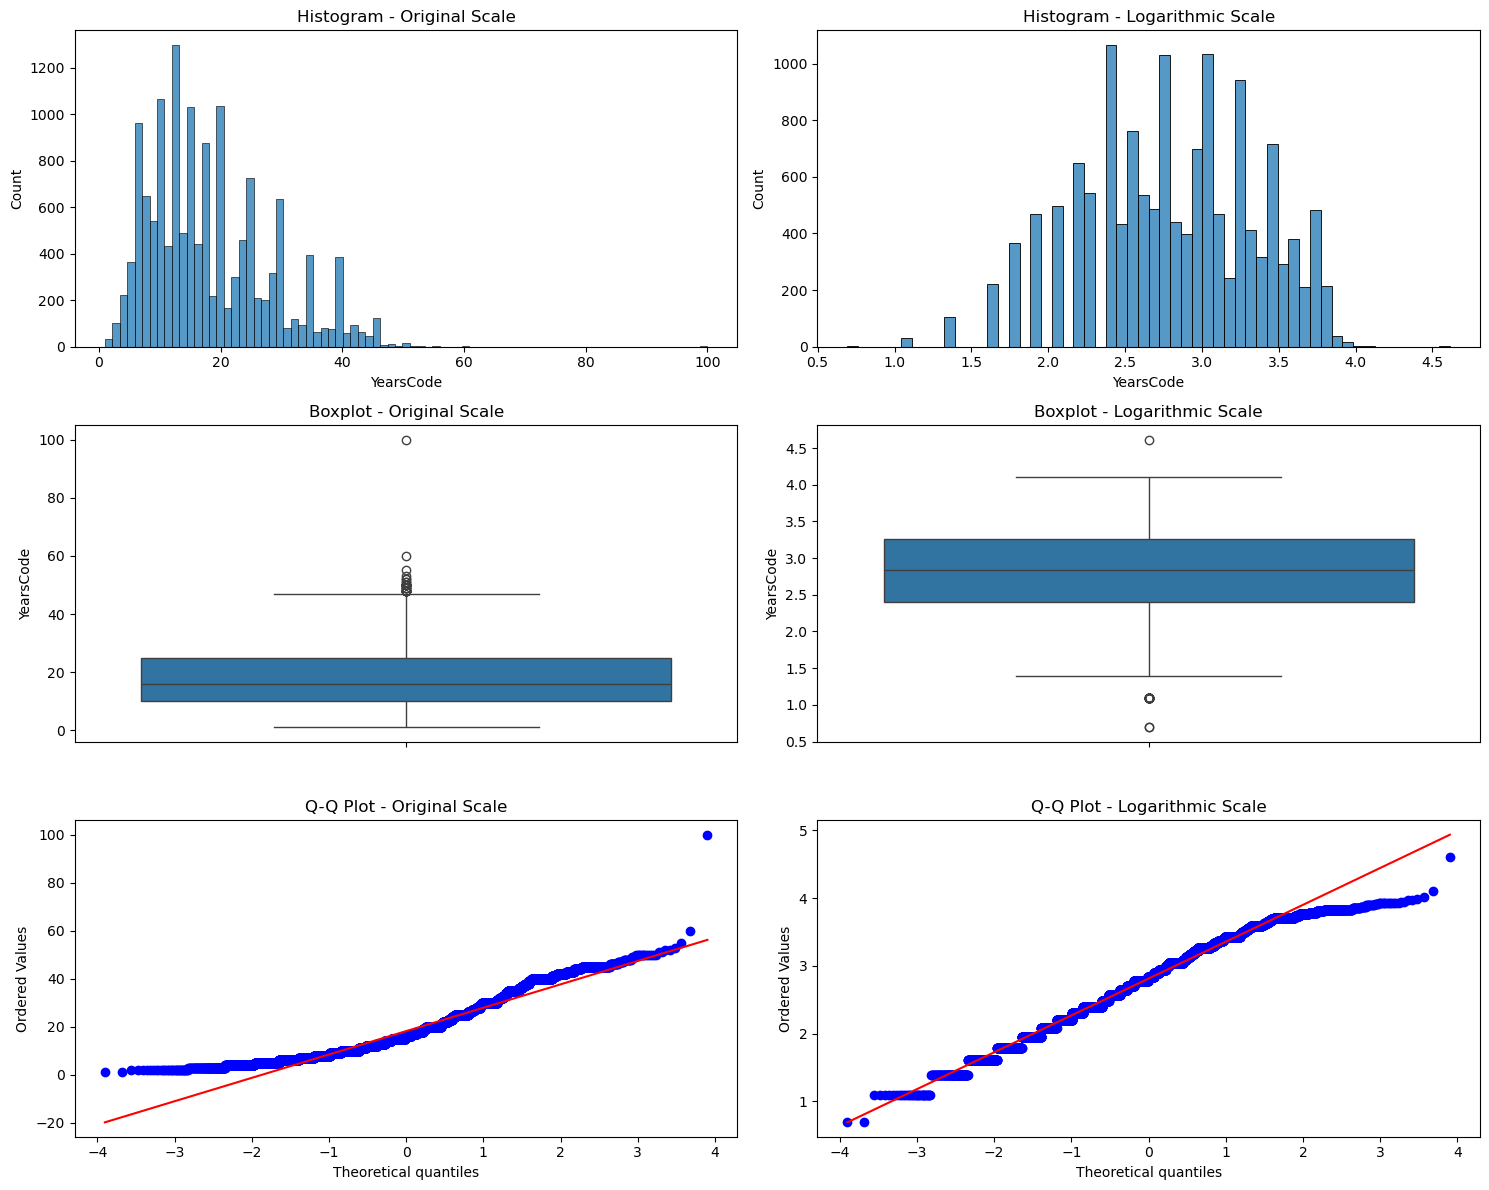

In [75]:
# Apply the function to visualize and understand the distribution of 'YearsCode'
plot_distribution_analysis(df, "YearsCode")

In [76]:
# Apply the function to perform initial exploratory statistical analysis on 'YearsCode'
main_stats(df, "YearsCode")

YearsCode analysis
n = 14498
Range: 99.00
Mean: 18.21
Median: 16.00
Asymmetry (Mean vs Median): 2.21
↗ Mean > Median: Positive skewness (right-tailed)
Standard deviation: 10.06
Q1: 10.00
Q3: 25.00
IQR: 15.00


{'n': 14498,
 'range': 99,
 'mean': 18.20595944268175,
 'median': 16.0,
 'asymmetry': 2.205959442681749,
 'std_dev': 10.056195161355879,
 'q1': 10.0,
 'q3': 25.0,
 'iqr': 15.0}

In [77]:
# Apply the function to analyze the distribution shape (skewness and kurtosis) of 'YearsCode'
distribution_form(df, "YearsCode")

YearsCode distribution analysis:
Skewness: 0.825 (moderate_skew)
Kurtosis: 0.240 (normal_tailed)


{'skewness': 0.825,
 'skewness_label': 'moderate_skew',
 'kurtosis': 0.24,
 'kurtosis_label': 'normal_tailed'}

In [78]:
# Apply the function to perform the normality test on 'YearsCode'
normality_test(df, "YearsCode", 0.838, 0.409)

YearsCode → stat=1302.988, p=0.000, skew=0.838, kurt=0.409 → near_normal


'near_normal'

In [79]:
# Apply the function to determine the most suitable method for calculating the number of bins
choose_bins_method(
    12071,
    99,
    9.81206316578263,
    15.0,
    "moderate_skew",
    "normal_tailed",
    "near_normal",
)

['Scott', 'Rice']

In [80]:
# Apply the function to compare the number of bins across different calculation methods
compares_bins_methods(df, "YearsCode")

{'Sturges': 15,
 'Scott': 69,
 'Freedman–Diaconis': 81,
 'Doane': 21,
 'Rice': 49,
 'Square-Root': 121}

In [81]:
# Get histogram data for 'YearsCode' in the format (counts, bin_edges)
hist_data = get_histogram_data(df, "YearsCode", 67)

In [82]:
# Apply the function to analyze the modality (number of peaks) of the 'YearsCode' distribution
analyze_modality(hist_data)

{'modality': 'bimodal', 'n_peaks': 2}

In [83]:
# Apply the function to analyze the boundedness of 'YearsCode'
analyze_boundedness(df, "YearsCode", mode="strict")

'nonnegative'

In [84]:
# Apply the function to identify the most suitable outlier detection methods for 'YearsCode'
pick_outlier_methods_ranked(12071, "moderate_skew", "normal_tailed", "nonnegative", "bimodal")

{'recommended_methods': [{'method': 'iqr',
   'params': {'k': 1.5, 'k_lower': 2.0, 'k_upper': 1.5},
   'priority': 'high',
   'why': 'Robust to non-normality and heavy tails with asymmetrical fences for moderate asymmetry'},
  {'method': 'quantile',
   'params': {'lower': 0.025, 'upper': 0.975},
   'priority': 'low',
   'why': 'Conservative approach, independent of distribution'}],
 'suggested_transform': 'log1p'}

In [85]:
# Apply outlier detection functions to 'YearsCode'
years_code_iqr_std = remove_outliers_iqr_standard(df, "YearsCode")
years_code_iqr_flex = remove_outliers_iqr_flex(df, "YearsCode")

In [86]:
# Check the maximum 'YearsCode' value after applying each outlier removal function
print(years_code_iqr_std["YearsCode"].max())
print(years_code_iqr_flex["YearsCode"].max())

47
52


**Outlier policy for years of coding:**

The YearsCode variable includes not only professional experience but also coding as a hobby or during education, meaning some respondents may accumulate unusually long careers.Using the standard 1.5×IQR cutoff (≈45 years) would exclude plausible long-term coders who started young and continued into late adulthood.\
To reduce false positives, a more permissive threshold of 2.0×IQR (≈52 years) was applied. This approach preserves realistic long careers while still filtering out implausible extremes (e.g., 70–80 years of coding).

In [87]:
# Apply the flexible IQR (k_lower=2.5, k_upper=1.8) outlier removal function to 'YearsCode'
df = remove_outliers_iqr_flex(df, "YearsCode")

In [88]:
# Check the maximum value of 'YearsCode' after applying the outlier removal function
df["YearsCode"].max()

52

#### 3.1.2 Tidiness Issues: Cleaning

*Multiple variables stored in a single column:*
During data assessment, it was identified that `LanguageHaveWorkedWith` contains semicolon-separated technology lists within single cells. While this violates tidy data principles, converting these to one row per technology would create artificial data duplication. Therefore, it will be employed feature engineering techniques to extract meaningful signals from these multi-value fields, as detailed in the Feature Engineering section.

### 3.2 Univariate Analyses

These analyses explore each variable individually and help set the stage for bivariate modeling and hypotheses.

#### 3.2.1 How is annual compensation distributed among respondents?

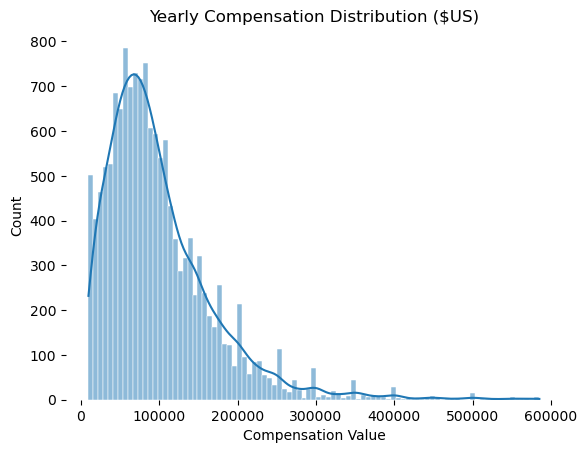

In [89]:
"""
Yearly Compensation distribution ($US).

Histogram on a linear scale showing the overall distribution of annual wages
for all respondents.
"""
ax = sns.histplot(df, x="ConvertedCompYearly", edgecolor="white", kde=True)

# Titles and labels
plt.title("Yearly Compensation Distribution ($US)", fontsize=12)
plt.xlabel("Compensation Value")
plt.ylabel("Count")

# Remove gridlines and axes spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

**Insights**

The chart shows that most technology professionals earn salaries concentrated in the lower compensation brackets, while a very small minority earns extremely high salaries.\
This behavior is expected in a global market with great economic diversity: it ranges from junior developers in emerging markets, with average salaries converted into dollars, to senior engineers or specialists at large technology companies in the United States and Europe, with annual salaries that easily exceed six figures.


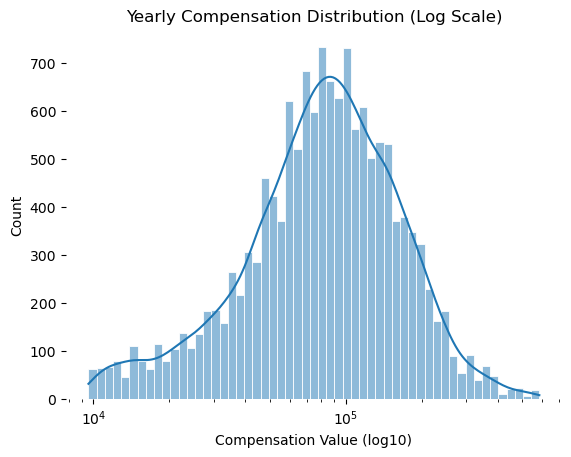

In [90]:
"""
Yearly Compensation Distribution (Log Scale).

Applies a logarithmic scale to the same variable, allowing for a more balanced
and comparable visualization across salary ranges.
"""
ax = sns.histplot(df, x="ConvertedCompYearly", edgecolor="white", kde=True, log_scale=True)

# Titles and labels
plt.title("Yearly Compensation Distribution (Log Scale)", fontsize=12)
plt.xlabel("Compensation Value (log10)")
plt.ylabel("Count")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

**Insights**

Applying a logarithmic scale evens out the right-skewed distribution, making it easier to observe the true shape of salaries across different income levels. The transformation reveals that most professionals earn between `$20,000` and `$120,000` per year, with a peak concentration around `$60,000`. This range captures the core of the global tech workforce — from mid-level developers in emerging economies to senior professionals in developed markets. Overall, the log-scaled view offers a more balanced and realistic understanding of global compensation patterns in the technology sector.

#### 3.2.2 How is professional experience distributed among developers?

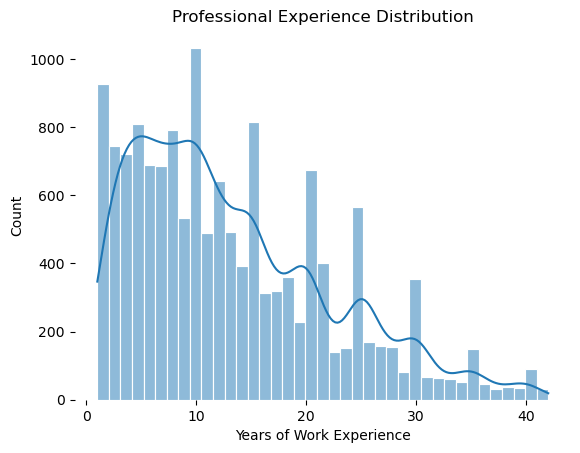

In [91]:
"""
Professional Experience Distribution.

Explores how professional experience is distributed among the developers
who responded to the survey.
"""
ax = sns.histplot(df, x="WorkExp", kde=True, edgecolor="white")

# Titles and labels
plt.title("Professional Experience Distribution", fontsize=12)
plt.xlabel("Years of Work Experience")
plt.ylabel("Count")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

**Insights**

The visualization shows that the majority of professionals have between 2 and 10 years of experience, with the highest concentration appearing within the early-to-mid stages of their careers. This indicates that the tech industry is largely composed of professionals who are established but still in active growth phases.

There is also a secondary cluster between 10 and 15 years of experience, representing a group of more seasoned professionals who have remained in technical or leadership roles over time. After this point, the number of respondents steadily declines, suggesting that fewer developers stay in hands-on technical positions beyond 15–20 years, often transitioning into management or other specialized areas.

Overall, this distribution reveals a predominantly mid-career developer community, complemented by a smaller group of experienced professionals, reflecting a dynamic and renewal-driven market where continuous inflow of new talent sustains the industry's growth.

#### 3.2.3 What’s the distribution of coding experience across respondents?

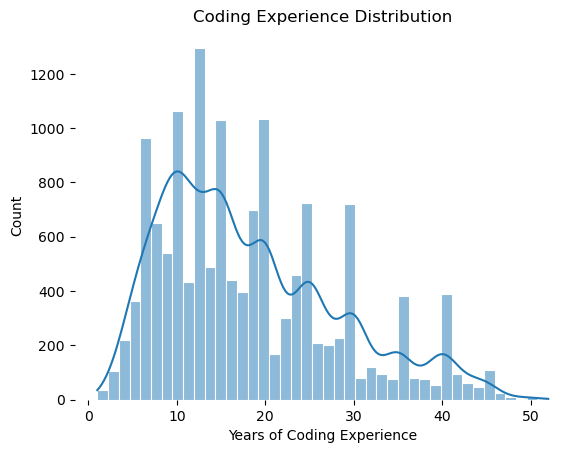

In [92]:
"""
Coding Experience Distribution.

Displays how coding experience is distributed among survey respondents.
"""
ax = sns.histplot(df, x="YearsCode", kde=True, edgecolor="white")

# Titles and labels
plt.title("Coding Experience Distribution", fontsize=12)
plt.xlabel("Years of Coding Experience")
plt.ylabel("Count")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

**Insights**

The visualization shows that the majority of respondents have between 5 and 10 years of coding experience, indicating that most developers have a solid technical foundation built over several years of active practice. This reflects a tech community composed largely of professionals who are technically mature but still in active stages of career growth.

There is also a secondary cluster between 10 and 20 years of experience, representing more seasoned developers who have maintained hands-on technical engagement over a longer period. Beyond this range, the number of respondents gradually declines, suggesting that fewer professionals continue coding actively after two decades, often shifting toward leadership, product, or architectural roles.

Overall, this distribution portrays a technically skilled and mid-experience developer base, complemented by a smaller group of long-term professionals—highlighting a mature yet constantly renewing industry, fueled by both experienced talent and new entrants expanding the global tech ecosystem.

#### 3.2.4 Which countries are most represented in the survey?

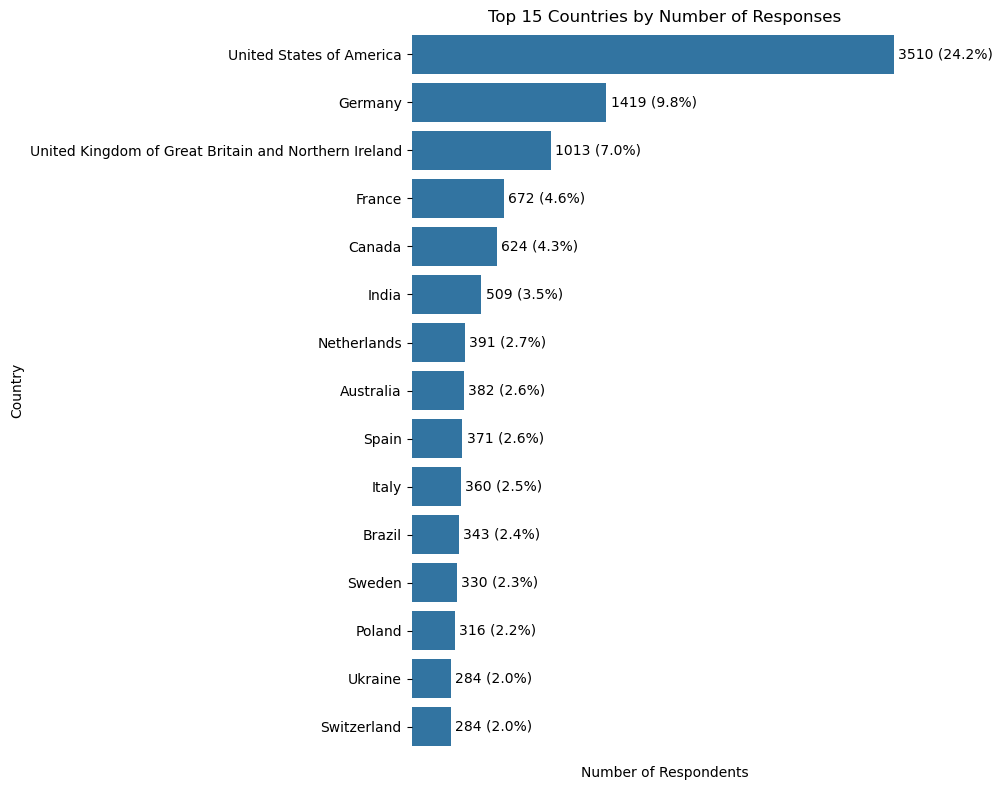

In [93]:
"""
Geographic Distribution of Respondents.

This chart highlights the 15 countries most represented in the survey.
"""
# Countries with the highest number of responses
plt.figure(figsize=(10, 8))
ax = sns.countplot(
    data=df,
    y="Country",
    order=df["Country"].value_counts().iloc[:15].index,
)

# Calculate total responses
total = len(df)

# Add counts and percentages to bars
for container in ax.containers:
    # Get counts for each bar
    counts = [patch.get_width() for patch in container]

    # Calculate percentages
    percentages = [f"({count / total * 100:.1f}%)" for count in counts]

    # Combine count and percentage labels
    labels = [f"{int(count)} {pct}" for count, pct in zip(counts, percentages)]
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

# Titles and labels
plt.title("Top 15 Countries by Number of Responses", fontsize=12)
plt.xlabel("Number of Respondents")
plt.ylabel("Country")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove ticks from the x-axis
ax.set(xticklabels=[])
ax.tick_params(axis="x", which="both", bottom=False)

plt.tight_layout()
plt.show()

**Insights**

The data shows that the United States dominates the sample, accounting for nearly a quarter (24.6%) of all responses. This strong participation aligns with the country’s large developer population and the widespread use of English in global developer communities. Following the U.S., Germany (9.8%), the United Kingdom (7.0%), France (4.5%), and Canada (4.4%) stand out as other major contributors. Together, these top five countries represent nearly half of the entire dataset, underscoring a strong concentration of responses from Western, English-speaking, and European markets.

Emerging tech regions such as India (3.5%) and others further down the list contribute smaller—but still meaningful—portions, reflecting a growing global participation while also highlighting the survey’s bias toward countries with stronger internet infrastructure and developer communities.

Overall, this distribution emphasizes that while the dataset is global in scope, it is heavily influenced by North American and European perspectives, which should be considered when interpreting results related to compensation, experience, or technology adoption trends.

#### 3.2.5 What’s the overall satisfaction level among developers?

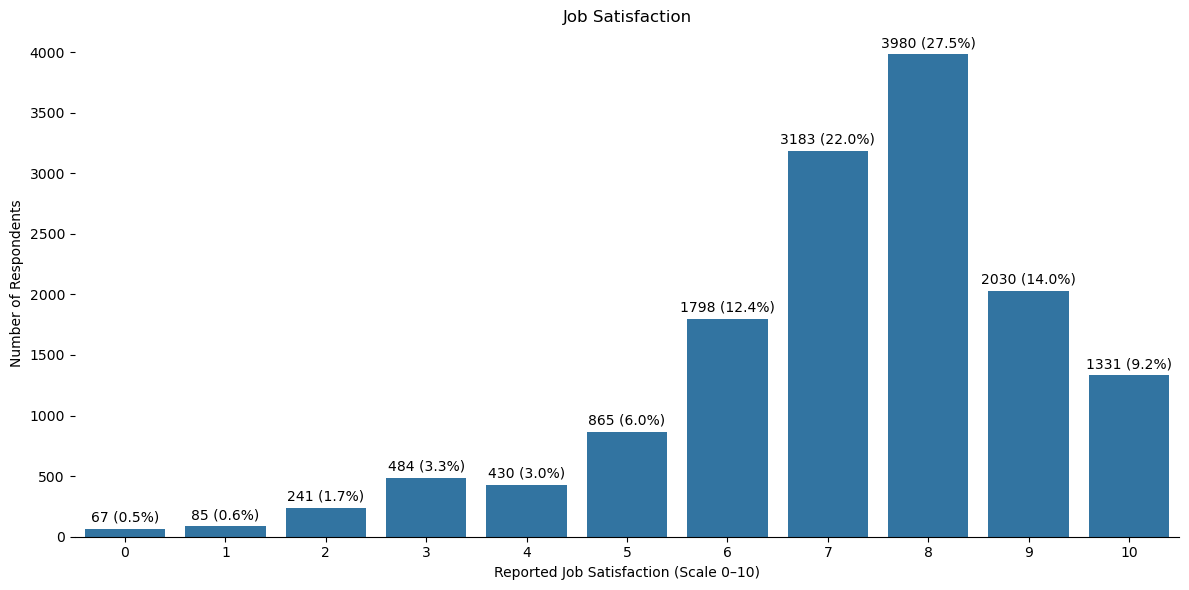

In [94]:
"""
Job Satisfaction Distribution.

Countplot illustrating the overall job satisfaction levels among developers,
based on self-reported scores from 0 to 10.
"""
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="JobSat")

# Calculate total responses
total = len(df)

# Add counts and percentages to bars
for container in ax.containers:
    # Get the counts for each bar
    counts = [patch.get_height() for patch in container]

    # Calculate percentages
    percentages = [f"({count / total * 100:.1f}%)" for count in counts]

    # Combine count and percentage labels
    labels = [f"{int(count)} {pct}" for count, pct in zip(counts, percentages)]
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

# Titles and labels
plt.title("Job Satisfaction", fontsize=12)
plt.xlabel("Reported Job Satisfaction (Scale 0–10)")
plt.ylabel("Number of Respondents")

# Remove grids and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

The results show a predominantly positive sentiment across respondents. The majority rated their satisfaction between 7 and 8, which together account for nearly half of all responses (around 49%). The single highest score is 8 (27.3%), suggesting that most professionals are generally content and motivated in their current roles.

If considered developers who rated their satisfaction 8 or higher as satisfied, this group represents approximately 50% of all respondents — meaning that one in every two developers reports being satisfied with their job. This highlights a strong level of overall contentment within the tech workforce, with a notable portion of professionals experiencing positive engagement and fulfillment.

Satisfaction levels above 9 still represent a significant portion of the population (over 23%), indicating that a meaningful group feels highly fulfilled with their work, possibly due to strong alignment between their roles, skills, and work environments.

On the other end of the scale, low satisfaction ratings (0–4) are relatively rare and together make up less than 10% of the total, which shows that severe dissatisfaction is uncommon among developers in this sample.

Overall, this distribution reflects a healthy professional environment, where most developers report good to very good satisfaction levels. It reinforces the perception of the tech industry as a rewarding and engaging career field, while also signaling the importance of maintaining conditions that sustain motivation and long-term satisfaction.

#### 3.2.6 Which industries employ most developers?

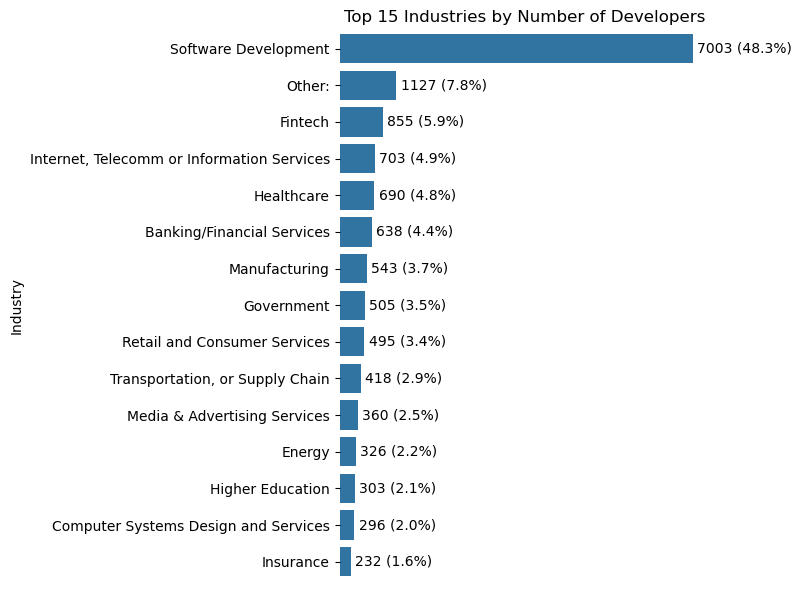

In [95]:
"""
Industry Distribution of Developers.

This chart highlights the industries that employ the largest number of
developers, offering a clear view of where most professionals in the
survey are currently working.
"""
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    y="Industry",
    order=df["Industry"].value_counts().iloc[:15].index,
)

# Calculate total responses
total = len(df)

# Add counts and percentages to bars
for container in ax.containers:
    # Get the counts for each bar
    counts = [patch.get_width() for patch in container]

    # Calculate percentages
    percentages = [f"({count / total * 100:.1f}%)" for count in counts]

    # Combine count and percentage labels
    labels = [f"{int(count)} {pct}" for count, pct in zip(counts, percentages)]
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

# Titles and labels
plt.title("Top 15 Industries by Number of Developers", fontsize=12)
plt.xlabel("Number of Respondents")
plt.ylabel("Industry")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove x-axis ticks and labels
ax.set(xticklabels=[])
ax.tick_params(axis="x", which="both", bottom=False)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Insights**

The data reveals that Software Development overwhelmingly dominates the landscape, representing nearly half of all respondents (48.7%). This finding aligns with expectations, as software development encompasses a wide range of roles—from application and web developers to full-stack engineers and DevOps professionals—serving as the backbone of the technology sector.

Beyond this primary category, Fintech (6.1%), Information and Telecommunication Services (5.0%), and Healthcare (4.8%) stand out as key employers, showing how technology has become deeply embedded in diverse and high-impact industries. Banking and Financial Services (4.4%) also appear prominently, emphasizing the continued demand for technical expertise in data-driven and security-sensitive domains.

Smaller yet relevant segments such as Retail and Consumer Services, Manufacturing, and Government collectively demonstrate that software professionals are increasingly spread across traditional and emerging sectors, not limited to tech-centric companies.

Overall, this distribution reinforces the idea that while software development remains the core employment sector for developers, the profession has expanded far beyond the tech industry itself—reflecting the digital transformation of nearly every economic sector and the growing importance of software expertise across the global job market.

#### 3.2.7 How do developers usually work (remote, hybrid, on-site)?

C:\Users\camil\AppData\Local\Temp\ipykernel_30168\522785795.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


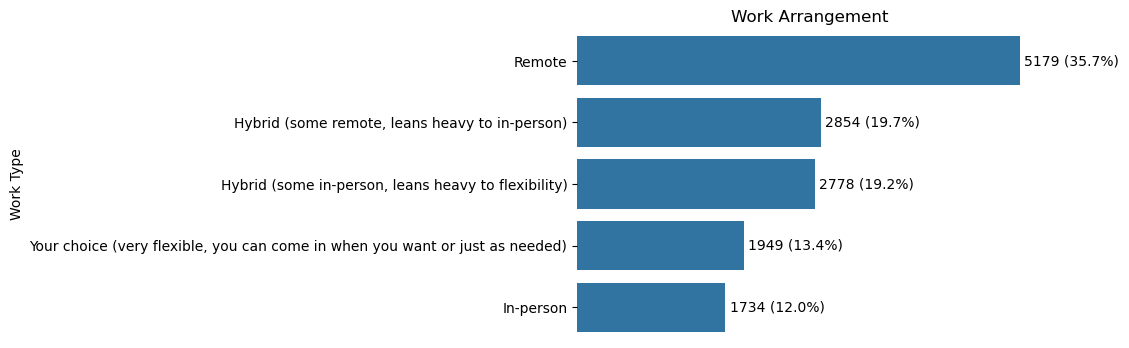

In [96]:
"""
Work Arrangement Distribution.

This chart illustrates the most common work arrangements among developers,
showing how the tech workforce is distributed across remote, hybrid,
and in-person setups.
"""
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df,
    y="RemoteWork",
    order=df["RemoteWork"].value_counts().iloc[:15].index,
)

# Calculate totals and percentages
total = len(df)
value_counts = df["RemoteWork"].value_counts()

# Add counts and percentages to bars
for container in ax.containers:
    # Get the counts for each bar
    counts = [patch.get_width() for patch in container]

    # Calculate percentages
    percentages = [f"({count / total * 100:.1f}%)" for count in counts]

    # Combine count and percentage labels
    labels = [f"{int(count)} {pct}" for count, pct in zip(counts, percentages)]
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

# Titles and labels
plt.title("Work Arrangement", fontsize=12)
plt.xlabel("Number of Respondents")
plt.ylabel("Work Type")

# Remove gridlines and axis spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove x-axis ticks and labels
ax.set(xticklabels=[])
ax.tick_params(axis="x", which="both", bottom=False)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Insights**

The results show that fully remote work remains the dominant model, accounting for 37.1% of respondents. This underscores how remote work has become a standard rather than an exception in the technology industry, offering flexibility and access to global opportunities — a shift accelerated by the pandemic and sustained by the nature of digital collaboration.

Following that, hybrid models collectively account for nearly 40% of developers, split between those who are mostly remote with occasional office presence (19.5%) and those who are mostly in-person but with some remote flexibility (18.8%). This suggests that many organizations have adopted a balanced approach, allowing developers to combine the benefits of in-person collaboration with the autonomy of remote work.

A smaller but notable portion of respondents (13.8%) report having full flexibility to choose when to work on-site or remotely, indicating an emerging preference for employee-driven work models that prioritize autonomy and trust. Meanwhile, only 10.8% of developers work entirely on-site, highlighting how traditional office setups have become the minority among tech professionals.

Overall, this distribution confirms that the tech industry has firmly transitioned to flexible and remote-first arrangements, reflecting a broader cultural shift toward work models centered on autonomy, productivity, and global collaboration.

#### 3.2.8 What is the educational background of developers?

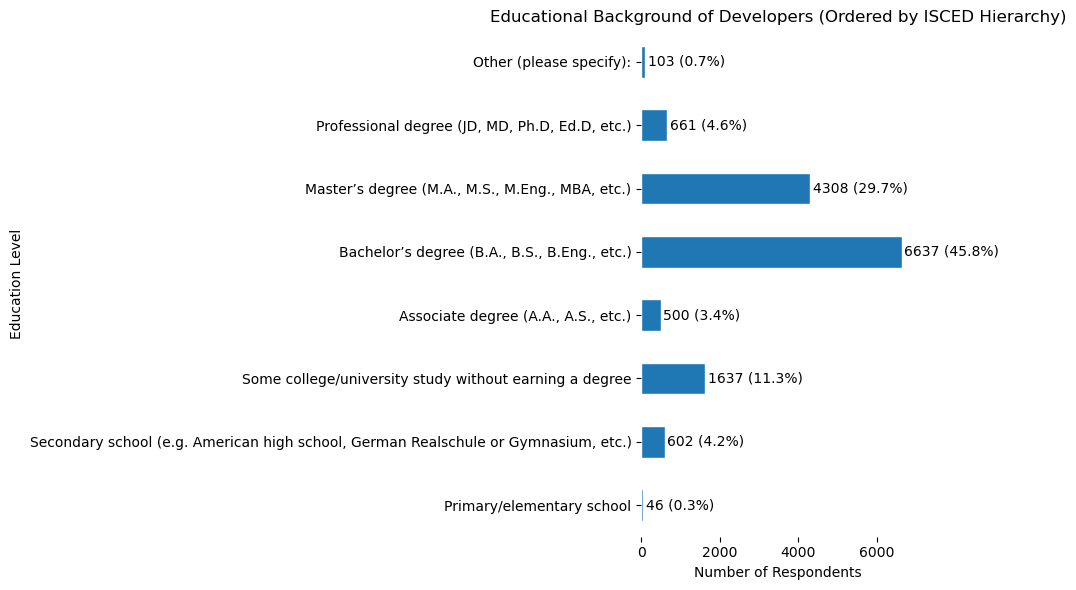

In [97]:
"""
Educational Background of Developers.

This chart provides an overview of the academic qualifications of developers,
highlighting the most common educational paths pursued by professionals in
the field.
"""

# Educational hierarchy (ISCED - International Standard Classification of Education)
isced_order = [
    "Primary/elementary school",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "Other (please specify):",
]

# Create an ordered categorical series (without modifying the original DataFrame)
edlevel_ordered = pd.Categorical(df["EdLevel"], categories=isced_order, ordered=True)

# Count and order responses
ed_counts = pd.Series(edlevel_ordered).value_counts().reindex(isced_order)

# Calculate percentages
total_responses = ed_counts.sum()
ed_pct = (ed_counts / total_responses * 100).round(1)

# Plot the graph
plt.figure(figsize=(10, 6))
ax = ed_counts.plot(kind="barh", edgecolor="white", color="#1f77b4")

# Add values and percentages to bars
for i, (count, pct) in enumerate(zip(ed_counts.values, ed_pct.values)):
    ax.text(count + max(ed_counts.values) * 0.01, i, f"{int(count)} ({pct}%)", va="center")

# Remove borders and grids
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

# Titles and labels
plt.title("Educational Background of Developers (Ordered by ISCED Hierarchy)", fontsize=12)
plt.xlabel("Number of Respondents")
plt.ylabel("Education Level")

plt.tight_layout()
plt.show()

**Insights**

The data reveals that the majority of respondents hold a Bachelor’s degree (46.3%), making it the most prevalent level of education among developers. This reflects the widespread trend of professionals entering the tech industry through traditional undergraduate programs in fields such as computer science, engineering, or related disciplines.

In second place, Master’s degrees account for 29.6% of respondents, showing that a significant portion of developers pursue advanced education to deepen their technical expertise or expand their qualifications into management and specialized domains.

Interestingly, 11.2% of participants reported having some college or university experience without earning a degree, suggesting that a notable number of developers successfully enter or thrive in the industry through non-traditional educational paths, such as self-study, bootcamps, or vocational training.

Smaller groups reported Associate degrees (3.4%) and Professional or Doctoral degrees (4.3%), while less than 5% have only completed secondary education.

Overall, this distribution highlights that the developer community is highly educated, with the majority holding undergraduate or graduate degrees, yet it also underscores the accessibility of the tech industry to alternative learning routes — where practical experience and continuous skill development often weigh as much as formal education.

#### 3.2.9 What are the most common developer roles and programming languages?

In [98]:
# Helpers

def clean_explode(series, sep=";"):
    """
    Split a delimited Series into tokens, explode to rows, strip spaces, and drop blanks.

    Parameters
    ----------
    series : pandas.Series
        Series containing delimited strings (e.g., "A; B;C").
    sep : str, default=";"
        Delimiter used to split values.

    Returns
    -------
    pandas.Series
        Exploded Series with trimmed tokens. If no tokens remain, returns an empty Series.
    """
    # Convert to string first to handle categorical/object values uniformly
    tokens = series.astype(str).str.split(sep)
    cleaned = [item.strip() for sub in tokens for item in sub if item.strip() != ""]
    s = pd.Series(cleaned)
    if s.empty:
        return pd.Series(dtype=int)
    return s


def top_counts(series_exploded, top_n=10):
    """
    Compute Top-N value counts with totals and percentages.

    Parameters
    ----------
    series_exploded : pandas.Series
        Series with one token per row (e.g., output of `clean_explode`).
    top_n : int, default=10
        Number of top items to return.

    Returns
    -------
    pandas.DataFrame
        DataFrame indexed by label with two columns:
        - 'count' : absolute frequency
        - 'pct'   : percentage over total (rounded to 1 decimal)
    """
    vc = series_exploded.value_counts()
    total = vc.sum()
    top = vc.head(top_n)
    pct = (top / total * 100).round(1)
    out = pd.DataFrame({"count": top, "pct": pct})
    return out


def plot_top_barh(
    df_counts,
    title,
    xlabel="Count",
    annotate_pct=True,
    max_label_len=40,
):
    """
    Plot a horizontal bar chart with count (and optional %) annotations.

    Parameters
    ----------
    df_counts : pandas.DataFrame
        DataFrame with columns 'count' and 'pct', indexed by label.
    title : str
        Chart title.
    xlabel : str, default="Count"
        X-axis label.
    annotate_pct : bool, default=True
        Whether to append percentage next to the count.
    max_label_len : int, default=40
        Maximum label length (labels longer than this will be truncated).

    Returns
    -------
    None
    """
    labels = [
        shorten(lbl, width=max_label_len, placeholder="…")
        for lbl in df_counts.index.tolist()
    ]
    counts = df_counts["count"].values
    pcts = df_counts["pct"].values

    fig, ax = plt.subplots(figsize=(10, 6))
    y = np.arange(len(labels))
    ax.barh(y, counts, edgecolor="white")
    ax.set_yticks(y, labels)
    ax.invert_yaxis()  # top first
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")

    # Notes
    for i, (count, pct) in enumerate(zip(counts, pcts)):
        text = f"{int(count)}" + (f"  ({pct}%)" if annotate_pct else "")
        ax.text(count + max(counts) * 0.01, i, text, va="center")

    # Clean edges and grids
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

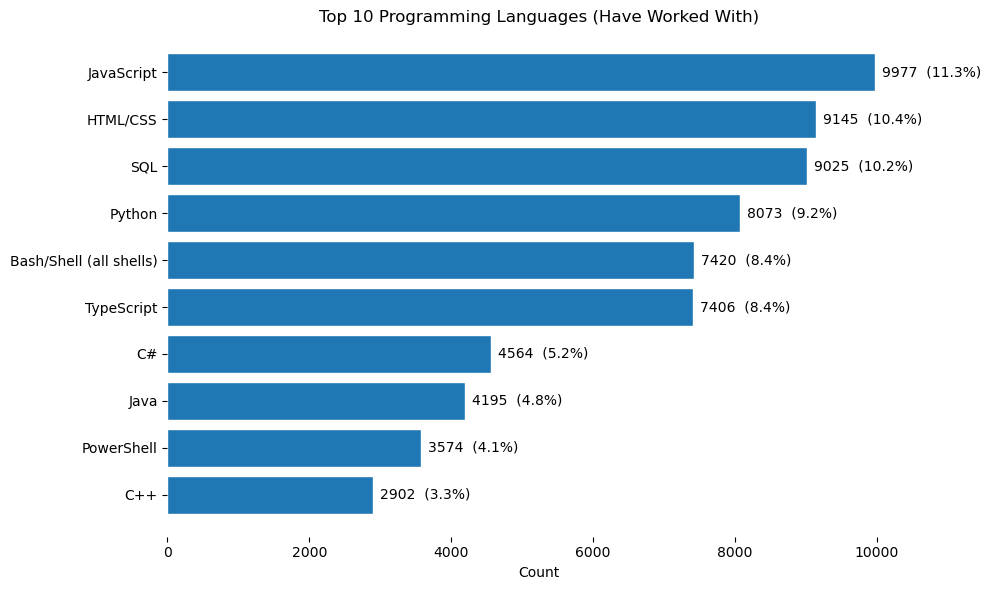

In [99]:
"""
Top 10 Programming Languages.

This chart presents the programming languages most commonly used by developers,
reflecting the core technological landscape of the global developer community.
"""

# Prepare language data
lang_series = clean_explode(df["LanguageHaveWorkedWith"], sep=";")
lang_top10 = top_counts(lang_series, top_n=10)

# Plot results
plot_top_barh(lang_top10, title="Top 10 Programming Languages (Have Worked With)")

**Insights**

The results show that JavaScript remains the dominant language, used by 11.4% of all mentions, confirming its central role in web and application development. Together with HTML/CSS (10.4%) and SQL (10.4%), JavaScript forms the foundation of the modern development stack, covering front-end, styling, and data management — skills essential for full-stack and web-oriented professionals.

Python (9.2%) and TypeScript (8.8%) follow closely, illustrating the growing adoption of languages known for versatility and scalability. Python stands out for its applications in data science, AI, and automation, while TypeScript has gained traction as a safer, more structured alternative to JavaScript for large-scale front-end and full-stack projects.

Bash/Shell (8.6%) highlights the continued importance of scripting and automation in developers’ workflows, particularly for DevOps and systems-related roles. Meanwhile, C# (5.0%) and Java (4.8%) maintain solid representation, reflecting their lasting presence in enterprise environments and backend systems.

Languages like PowerShell (4.1%) and Go (3.2%) round out the top 10, signaling the expanding diversity of the modern programming ecosystem, where niche yet powerful tools are gaining adoption for cloud, infrastructure, and performance-critical applications.

Overall, the data reinforces a balanced yet evolving technological landscape, where traditional web and enterprise languages coexist with modern, flexible tools that enable innovation in emerging domains such as cloud computing, AI, and automation.

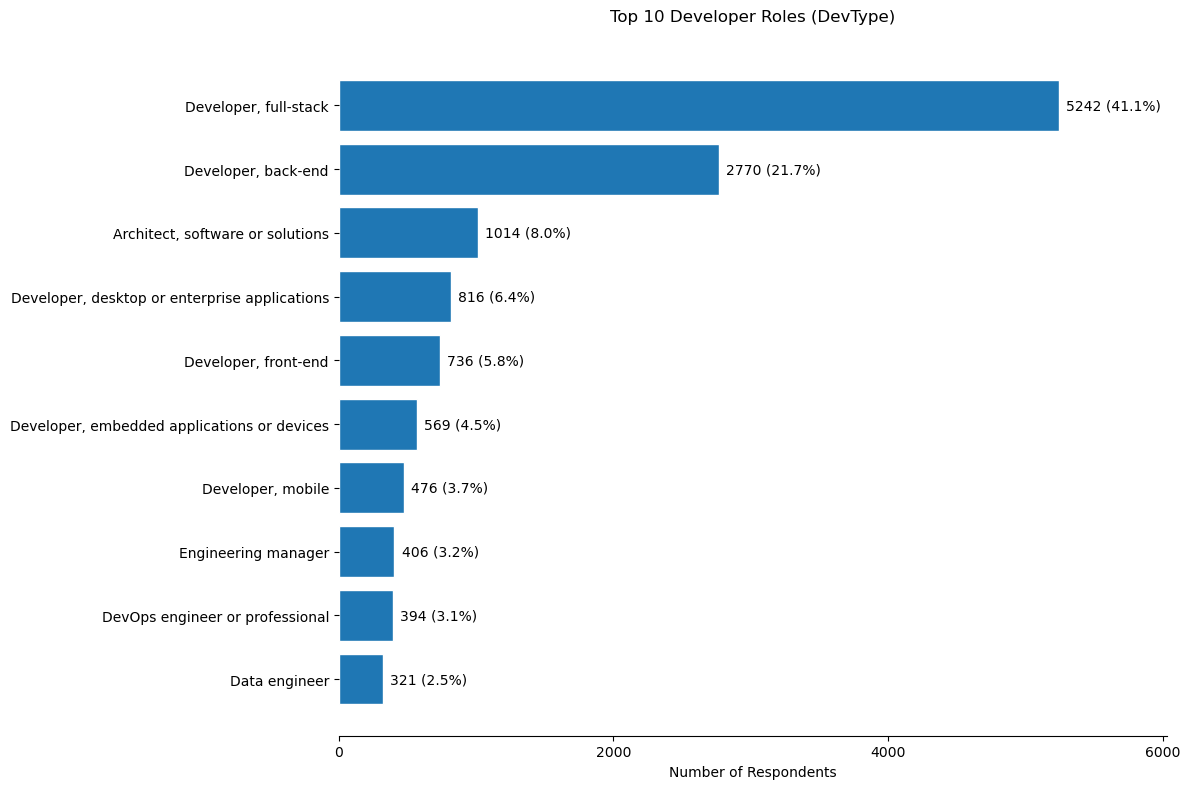

In [100]:
"""
Top 10 Developer Roles.

This chart displays the most common developer roles represented in the survey,
providing insight into the composition of the global developer community.
"""

# Prepare role data
devtype_counts = df["DevType"].value_counts().head(10)
total_count = devtype_counts.sum()
percentages = (devtype_counts.values / total_count * 100).round(1)

# Create chart
plt.figure(figsize=(12, 8))
bars = plt.barh(devtype_counts.index, devtype_counts.values, color="#1f77b4", edgecolor="white")

# Add count and percentage labels
for i, (count, pct) in enumerate(zip(devtype_counts.values, percentages)):
    plt.text(count + devtype_counts.max() * 0.01, i, f"{count} ({pct}%)", va="center", fontsize=10)

# Chart settings
plt.gca().invert_yaxis()
plt.xlabel("Number of Respondents")
plt.xlim(0, devtype_counts.max() * 1.15)
plt.xticks(np.arange(0, devtype_counts.max() * 1.15, 2000))
plt.title("Top 10 Developer Roles (DevType)", fontsize=12, pad=20)

# Remove spines
for spine in ["top", "right", "left"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Insights**

The data clearly shows that Full-stack developers dominate the field, representing 36.2% of respondents. This reflects the ongoing demand for professionals capable of working across both front-end and back-end environments — a versatile profile highly valued in startups, small teams, and companies seeking flexibility in development capabilities.

Next, Back-end developers form the second-largest group (19.1%), confirming the strong need for specialists focused on infrastructure, data handling, and application logic. Software and solutions architects (7%) follow, indicating a relevant share of senior professionals involved in high-level system design and technical leadership.

Roles such as Desktop/Enterprise (5.6%), Front-end (5.1%), and DevOps engineers (2.7%) highlight the diversity of expertise within the community, covering everything from interface development to deployment and automation. Meanwhile, smaller yet important segments — including Engineering managers, Data engineers, and Mobile or Embedded developers — show how software careers branch into increasingly specialized domains as organizations scale.

Overall, this distribution reinforces that the core of the developer workforce remains concentrated in full-stack and back-end roles, while a growing ecosystem of specialized functions — such as DevOps, data engineering, and mobile development — reflects the maturation and diversification of the software industry.

### 3.3 Bivariate Analysis

Explore relationships between variables to help answer the project's business questions and guide modeling.

#### 3.3.1 What factors influence annual compensation?

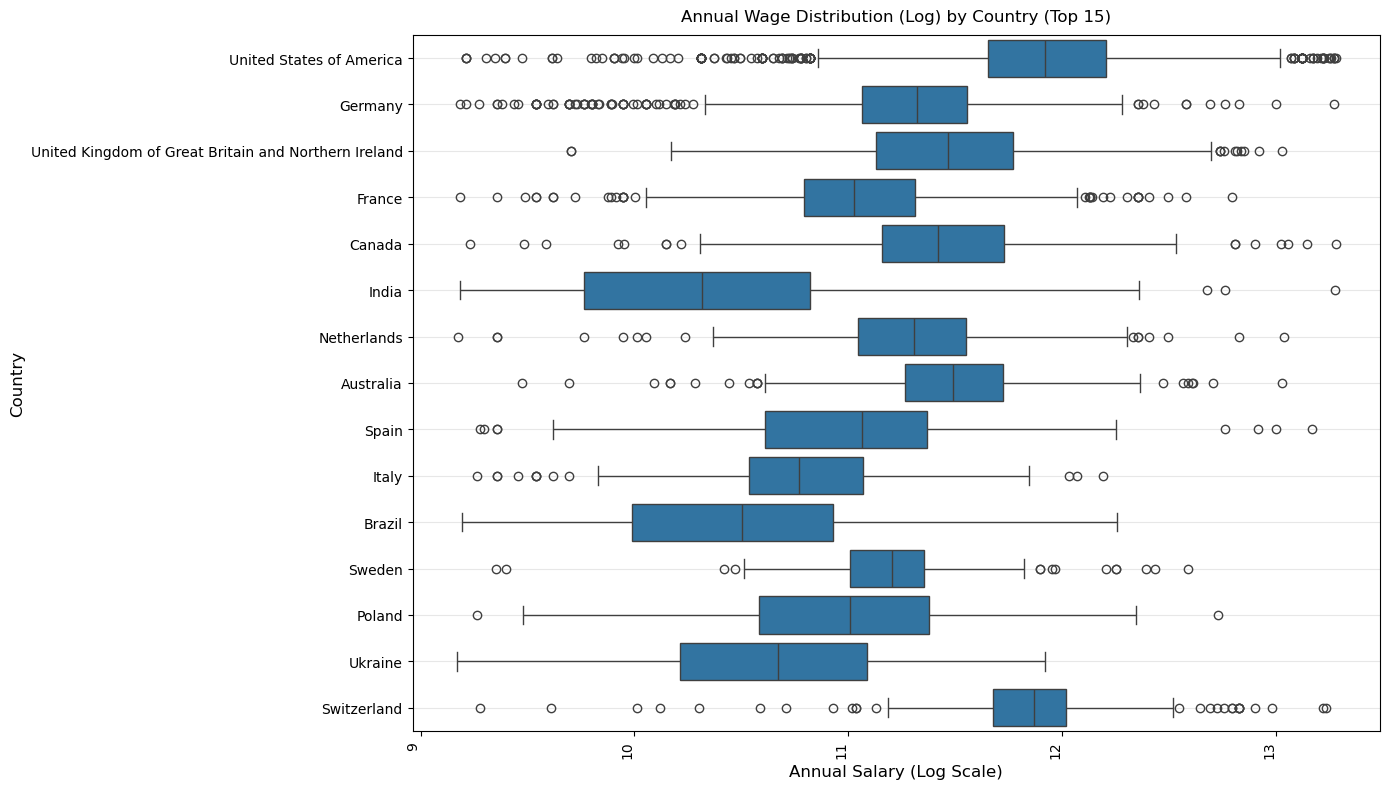

In [101]:
"""
Annual Compensation Distribution by Country (Log Scale).

This boxplot compares annual compensation (in log scale) among developers from
the top 10 countries in the dataset, illustrating how geography influences
salary levels within the tech industry.
"""

# Calculate the top 10 countries with the most responses
country_counts = df["Country"].value_counts()
top_countries = country_counts.head(15).index

# Filter data for the top 10 countries
df_top_countries = df[df["Country"].isin(top_countries)].copy()

# Create boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_top_countries,
    y="Country",
    x="LogConvertedCompYearly",
    order=top_countries,
    color="#1f77b4",
)
plt.title("Annual Wage Distribution (Log) by Country (Top 15)", fontsize=12, pad=10)
plt.xlabel("Annual Salary (Log Scale)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insights**

The chart shows a clear global disparity in compensation, with the United States standing out as the country with the highest median salary and the widest range of earnings. This aligns with the U.S.’s mature technology market, where high competition for talent and the presence of major tech companies drive up wages.

Countries such as Germany, the United Kingdom, France, and Canada follow, all showing consistently strong median compensations, though slightly below U.S. levels. These nations also display narrower salary ranges, suggesting a more standardized compensation structure within their local markets.

On the other hand, countries like India, Brazil, and Spain exhibit lower medians and broader variability, indicating that while there are well-paid developers in these markets, the average income level remains significantly lower compared to Western economies. This pattern reflects differences in cost of living, currency strength, and local demand for tech professionals.

Notably, the use of log scale allows for better visualization of these differences by compressing extreme salary values, making it easier to see that while the distribution varies across countries, the general structure — with a few high earners and many mid-range professionals — is consistent globally.

Overall, the visualization highlights how geographic location remains a strong determinant of developer compensation, influenced by economic maturity, industry concentration, and global labor market dynamics.

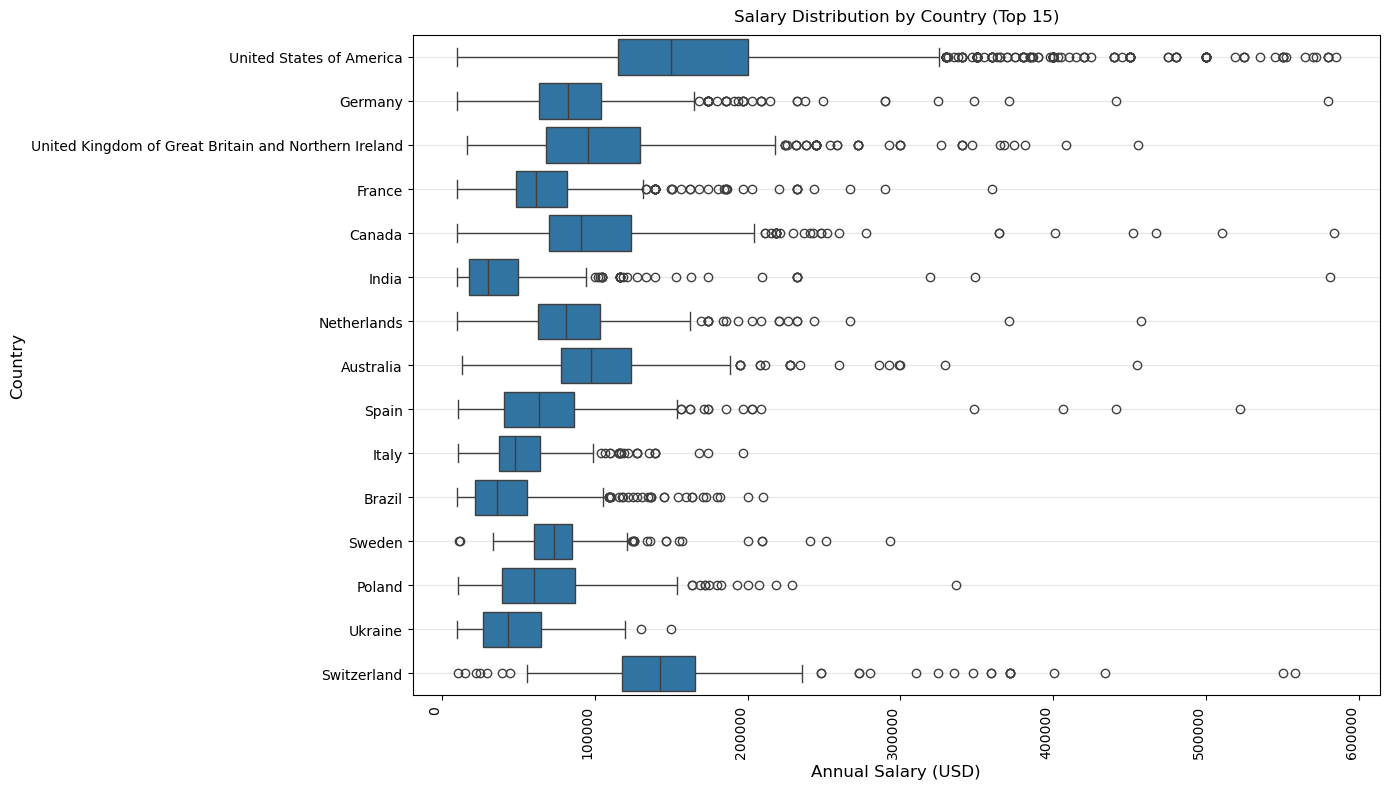

In [102]:
"""
Annual Compensation Distribution by Country (USD).

This boxplot compares annual compensation (in USD) among developers from the
10 countries with the highest number of survey respondents, offering a clear
view of how salary levels vary across different economies.
"""

# Calculate the top 10 countries with the most responses
country_counts = df["Country"].value_counts()
top_countries = country_counts.head(15).index

# Filter data for the top 10 countries
df_top_countries = df[df["Country"].isin(top_countries)].copy()

# Create boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_top_countries,
    y="Country",
    x="ConvertedCompYearly",
    order=top_countries,  # Ensures consistent country order
    color="#1f77b4",
)
plt.title("Salary Distribution by Country (Top 15)", fontsize=12, pad=10)
plt.xlabel("Annual Salary (USD)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**Insights**

The visualization confirms a strong geographical inequality in compensation: the United States leads by a significant margin, with both the highest median salaries and a wider range of earnings, reflecting a market with diverse roles and strong financial incentives, especially for senior and specialized professionals.

Germany, the United Kingdom, France, and Canada form a second tier of high-income countries, where salaries are still competitive but slightly lower than in the U.S. These nations exhibit narrower distributions, suggesting more standardized pay scales and stronger alignment between experience and compensation.

In contrast, India and Brazil show much lower median salaries, even though their ranges are broad, indicating that while some professionals in these markets earn high wages (especially those working for international companies), the majority still earn considerably less compared to their counterparts in North America and Western Europe.

Australia and the Netherlands sit in the middle of the spectrum, offering relatively high median salaries with moderate variability, while Spain presents lower overall compensation levels similar to Brazil but with less dispersion.

Overall, this comparison highlights how location remains one of the most decisive factors influencing developer pay, driven by differences in local economies, demand for tech talent, cost of living, and access to global markets. It also reinforces the premium salaries offered in mature tech ecosystems, particularly the United States, while revealing the growing but uneven opportunities in emerging economies.

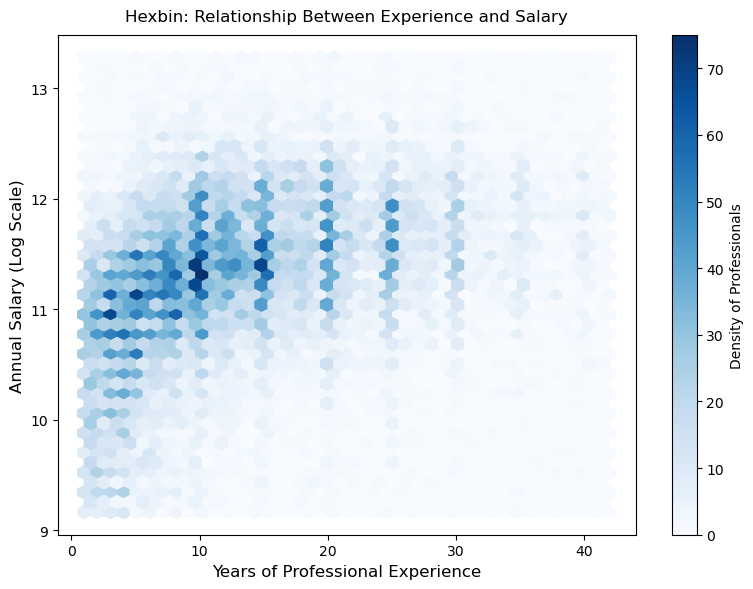

In [103]:
"""
Hexbin: Relationship Between Experience and Salary (Log Scale).

This Hexbin plot provides a clearer visualization of the relationship between
years of professional experience and annual salary (in log scale), reducing
the visual noise seen in the previous scatterplot.
"""

# Create hexbin plot
plt.figure(figsize=(8, 6))
plt.hexbin(df["WorkExp"], df["LogConvertedCompYearly"], gridsize=40, cmap="Blues")

# Titles and labels
plt.title("Hexbin: Relationship Between Experience and Salary", fontsize=12, pad=10)
plt.xlabel("Years of Professional Experience", fontsize=12)
plt.ylabel("Annual Salary (Log Scale)", fontsize=12)

# Add colorbar for density
plt.colorbar(label="Density of Professionals")

plt.tight_layout()
plt.show()

**Insights**

Each hexagon represents a cluster of professionals, and the shade of blue indicates density — darker areas correspond to higher concentrations of respondents within a specific salary and experience range.

The chart reveals that the highest concentration of professionals falls between 5 and 15 years of experience, with salaries mainly ranging from 10⁴.⁸ to 10⁵.³, which corresponds roughly to `$60,000` to `$200,000` per year. This range represents the core of the workforce — mostly mid-level and senior developers.

As experience increases, there is a positive upward trend in salary, though it becomes less steep after around 20 years of experience, suggesting a plateau effect where compensation growth stabilizes. This likely reflects the transition of some professionals into management, consulting, or non-technical leadership roles.

The plot also shows wide salary variation across all experience levels, reinforcing that factors such as geographic location, company type, technical specialization, and seniority within a role play a significant role in compensation, alongside years of experience.

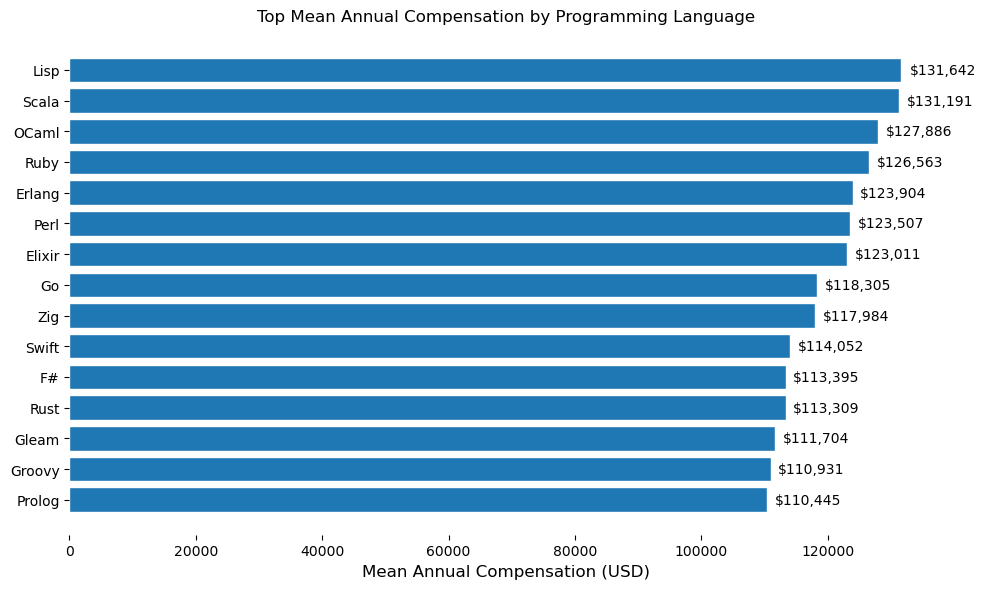

In [104]:
"""
Top Programming Languages by Average Annual Compensation (USD).

This chart highlights the programming languages with the highest average annual
compensation among respondents, offering insights into which technologies are
most financially rewarding.
"""

# Helper function
def explode_lang(df, col_lang="LanguageHaveWorkedWith", col_salary="ConvertedCompYearly"):
    """
    Explode the language column while keeping salary linkage and cleaning spaces.

    Parameters
    ----------
    df : pandas.DataFrame
        The source DataFrame containing language and salary columns.
    col_lang : str, default="LanguageHaveWorkedWith"
        The column name containing semicolon-separated languages.
    col_salary : str, default="ConvertedCompYearly"
        The column name containing salary values.

    Returns
    -------
    pandas.DataFrame
        DataFrame with exploded 'Language' and corresponding 'SalaryUSD' columns.
    """
    tmp = df[[col_lang, col_salary]].dropna(subset=[col_salary]).copy()
    tmp[col_lang] = tmp[col_lang].fillna("").astype(str).str.split(";")
    tmp = tmp.explode(col_lang)
    tmp[col_lang] = tmp[col_lang].str.strip()
    tmp = tmp[tmp[col_lang] != ""]
    return tmp.rename(columns={col_lang: "Language", col_salary: "SalaryUSD"})


# Prepare exploded data (language vs. salary)
df_lang = explode_lang(df, col_lang="LanguageHaveWorkedWith", col_salary="ConvertedCompYearly")

# Ensure a minimum number of samples per language
min_n = 50  # Data-quality safeguard to reduce bias and random variation
counts = df_lang["Language"].value_counts()
valid_langs = counts[counts >= min_n].index
df_lang_valid = df_lang[df_lang["Language"].isin(valid_langs)]

# Compute average salary by language and select top N
top_n = 15
mean_by_lang = (
    df_lang_valid.groupby("Language", as_index=False)["SalaryUSD"]
    .mean()
    .sort_values("SalaryUSD", ascending=False)
    .head(top_n)
)

# Plot graph
plt.figure(figsize=(10, 6))
bars = plt.barh(
    mean_by_lang["Language"],
    mean_by_lang["SalaryUSD"],
    edgecolor="white",
    color="#1f77b4",
)

# Display highest value on top
plt.gca().invert_yaxis()

# Annotate values in USD
for i, v in enumerate(mean_by_lang["SalaryUSD"].values):
    plt.text(v * 1.01, i, f"${v:,.0f}", va="center")

# Titles and labels
plt.title("Top Mean Annual Compensation by Programming Language", fontsize=12, pad=10)
plt.xlabel("Mean Annual Compensation (USD)", fontsize=12)
plt.ylabel("")

# Remove borders and grid
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

At the top of the ranking are Lisp and Scala, followed closely by OCaml and Ruby. These languages are not necessarily the most popular or widely used but tend to be associated with highly specialized domains, such as financial systems, academic research, data engineering, and enterprise-scale software, where expertise is scarce and salaries are consequently higher.

Meanwhile, more modern or performance-focused languages like Go, Rust, and Swift also appear within this high-salary group, showing how emerging technologies that combine efficiency with developer productivity are increasingly valued in the market.

Overall, this distribution reveals that the highest-paying languages are not necessarily the most popular, but rather those that require deep technical expertise or serve critical business applications. The data underscores how rarity, complexity, and domain specialization can often outweigh popularity when it comes to developer compensation.


#### 3.3.2 Which factors contribute to high job satisfaction?

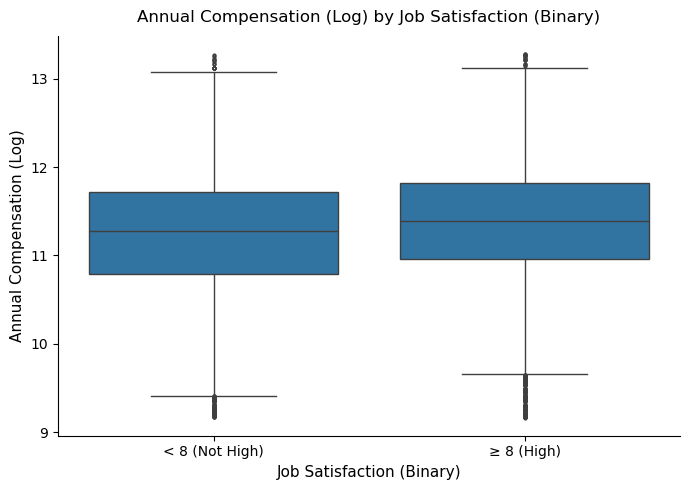

In [105]:
"""
Annual Compensation (Log) by Job Satisfaction (Binary).

This boxplot illustrates the relationship between annual compensation
(log-transformed) and job satisfaction, where high satisfaction scores are
defined as 8 or above.
"""

# Feature engineering: create binary variable for job satisfaction
df["JobSat_bin"] = (
    pd.to_numeric(df["JobSat"], errors="coerce")
    .ge(8)
    .astype("Int8")
)
# This transformation creates a clear demarcation for analysis, comparing
# "high satisfaction" (≥ 8) vs. "not high satisfaction" (< 8).

# Create boxplot
plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df,
    x="JobSat_bin",
    y="LogConvertedCompYearly",
    order=[0, 1],
    fliersize=2,
    color="#1f77b4",
)

# Titles and labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["< 8 (Not High)", "≥ 8 (High)"])
ax.set_xlabel("Job Satisfaction (Binary)", fontsize=11)
ax.set_ylabel("Annual Compensation (Log)", fontsize=11)
ax.set_title("Annual Compensation (Log) by Job Satisfaction (Binary)", fontsize=12, pad=10)

# Clean up chart
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Insights**

As seen in the plot, there is a slight upward shift in median salary for developers who report higher satisfaction levels, indicating a positive but modest relationship between compensation and satisfaction.

The spread (interquartile range) remains relatively wide for both groups, suggesting that other factors play important roles in shaping satisfaction beyond pay.

Additionally, the presence of several outliers in both categories indicates that some professionals may earn exceptionally high salaries yet still report lower satisfaction, reinforcing that income is only one dimension of overall job fulfillment.

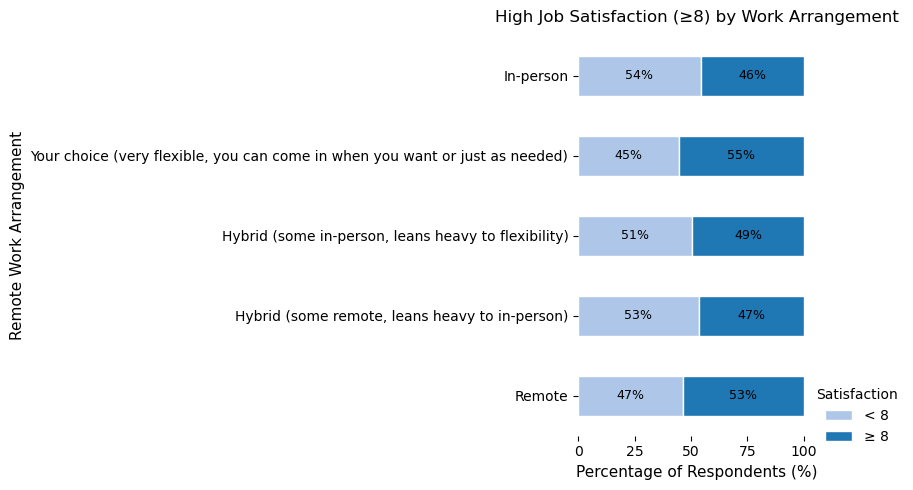

In [106]:
"""
High Job Satisfaction (≥8) by Work Arrangement.

This stacked bar chart illustrates how job satisfaction (≥8, considered “high”)
varies according to work arrangement — comparing in-person, hybrid, remote, and
flexible setups.
"""

# Select relevant columns
cols = ["RemoteWork", "JobSat_bin"]
df_remote = df[cols].dropna()

# Contingency table and proportions by RemoteWork category
ct = pd.crosstab(df_remote["RemoteWork"], df_remote["JobSat_bin"])
ct = ct.reindex(ct.sum(axis=1).sort_values(ascending=False).index)  # Sort by total count
prop = (ct.T / ct.T.sum()).T * 100  # Percentage per RemoteWork category

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(9, 5))
prop[[0, 1]].plot(
    kind="barh",
    stacked=True,
    edgecolor="white",
    ax=ax,
    color=["#aec7e8", "#1f77b4"],
)

# Titles and labels
ax.set_xlabel("Percentage of Respondents (%)", fontsize=11)
ax.set_ylabel("Remote Work Arrangement", fontsize=11)
ax.set_title("High Job Satisfaction (≥8) by Work Arrangement", fontsize=12, pad=10)

# Add percentage labels to each segment
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x()
    y = p.get_y()

    if width > 0 and height > 0:  # Only label visible segments
        center_x = x + width / 2
        center_y = y + height / 2
        ax.text(center_x, center_y, f"{width:.0f}%", ha="center", va="center", fontsize=9)

# Legend configuration
ax.legend(
    title="Satisfaction",
    labels=["< 8", "≥ 8"],
    loc="center left",
    frameon=False,
    bbox_to_anchor=(0.95, 0.05),
)

# Clean up chart
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

The data suggests a clear association between flexibility and satisfaction. Respondents with full flexibility (“your choice”) reported the highest proportion of high satisfaction (55%), closely followed by fully remote workers (53%). This pattern reinforces the idea that autonomy over work location contributes positively to well-being and engagement.

In contrast, in-person workers showed the lowest proportion of highly satisfied professionals (45%), implying that rigid or less flexible arrangements may reduce overall job satisfaction.

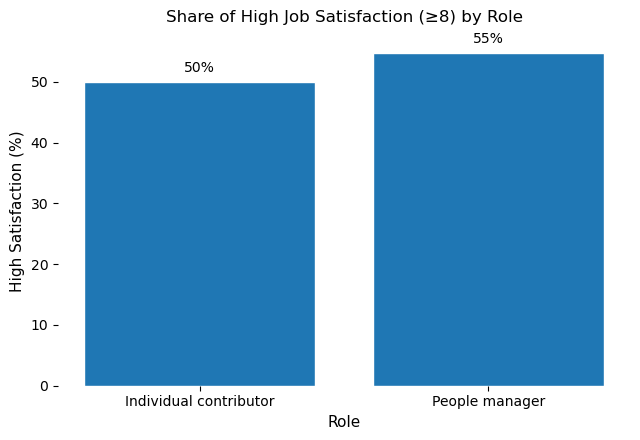

In [107]:
"""
High Job Satisfaction (≥8) by Role.

This chart compares the share of professionals with high job satisfaction (≥8)
between individual contributors and people managers.
"""

# Create contingency table and calculate proportions
ct = pd.crosstab(df["ICorPM"], df["JobSat_bin"])
prop = (ct.T / ct.T.sum()).T * 100  # Percentage per ICorPM category

# Create bar plot
plt.figure(figsize=(6.5, 4.5))
bars = plt.bar(
    prop.index,
    prop.get(1, pd.Series([0] * len(prop), index=prop.index)),
    edgecolor="white",
    color="#1f77b4",
)

# Titles and labels
plt.title("Share of High Job Satisfaction (≥8) by Role", fontsize=12, pad=10)
plt.xlabel("Role", fontsize=11)
plt.ylabel("High Satisfaction (%)", fontsize=11)

# Add percentage labels on bars
vals = prop.get(1, pd.Series([0] * len(prop), index=prop.index)).values
for i, v in enumerate(vals):
    if v > 0:
        plt.text(i, v + max(vals) * 0.02, f"{v:.0f}%", ha="center", va="bottom", fontsize=10)

# Clean up chart
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

The results show that people managers report slightly higher satisfaction (55%) compared to individual contributors (50%). While the difference is modest, it suggests that those in leadership positions may experience greater fulfillment—possibly due to higher autonomy, decision-making power, and recognition.

However, since both groups show relatively high satisfaction overall, the data implies that satisfaction is not exclusive to managerial roles, and individual contributors can also find strong motivation and engagement in their technical or specialized work.

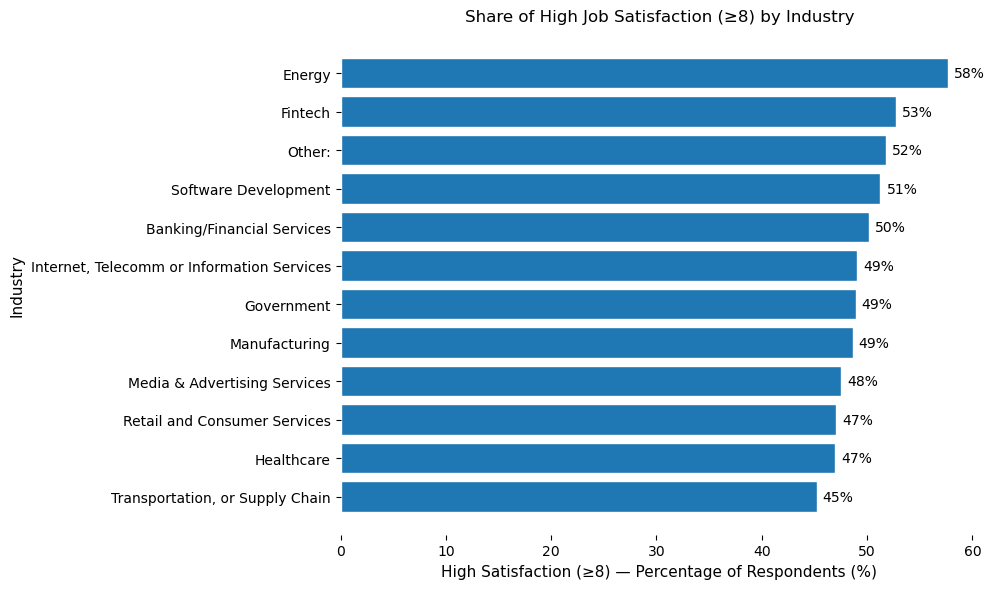

In [108]:
"""
High Job Satisfaction (≥8) by Industry.

This chart compares the share of professionals with high job satisfaction (≥8)
across different industries.
"""

# Select relevant columns
df_industry = df[["Industry", "JobSat_bin"]].copy()

# Normalize spaces and clean values
df_industry["Industry"] = df_industry["Industry"].astype(str).str.strip()

# Apply data-quality safeguard
min_n = 100  # Ensures at least 100 valid responses per industry
top_n = 12   # Selects the top N industries by count

# Filter valid industries (≥ min_n responses) and keep up to 50 for reliability
counts = df_industry["Industry"].value_counts()
valid_inds = counts[counts >= min_n].head(50).index
df_industry = df_industry[df_industry["Industry"].isin(valid_inds)]

# Select the top N industries by number of responses
top_inds = df_industry["Industry"].value_counts().head(top_n).index
df_industry = df_industry[df_industry["Industry"].isin(top_inds)]

# Create contingency table and calculate percentage of high satisfaction
ct = pd.crosstab(df_industry["Industry"], df_industry["JobSat_bin"])
share_high = (
    ct.get(1, pd.Series(0, index=ct.index)) / ct.sum(axis=1) * 100
).sort_values(ascending=True)

# Plot chart ordered by percentage of high satisfaction
plt.figure(figsize=(10, 6))
bars = plt.barh(
    share_high.index,
    share_high.values,
    edgecolor="white",
    color="#1f77b4",
)

# Titles and labels
plt.title("Share of High Job Satisfaction (≥8) by Industry", fontsize=12, pad=10)
plt.xlabel("High Satisfaction (≥8) — Percentage of Respondents (%)", fontsize=11)
plt.ylabel("Industry", fontsize=11)

# Add percentage labels to bars
for i, v in enumerate(share_high.values):
    plt.text(v + max(share_high.values) * 0.01, i, f"{v:.0f}%", va="center", fontsize=10)

# Clean up chart
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

The data shows that Energy and Fintech lead in satisfaction, suggesting these sectors may offer better compensation, innovation-driven environments, or strong growth opportunities. Software Development and Banking/Financial Services also maintain solid satisfaction levels around 51%, indicating overall stability and engagement in tech-related fields.

On the other hand, Healthcare and Transportation/Supply Chain report the lowest satisfaction, possibly reflecting higher stress, longer hours, or limited flexibility compared to digital sectors.

In summary, satisfaction appears higher in industries with strong innovation, flexibility, and compensation potential, while more traditional or operational sectors tend to lag behind.

**Does remote work correlate with higher or lower salaries after controlling for experience and country?**

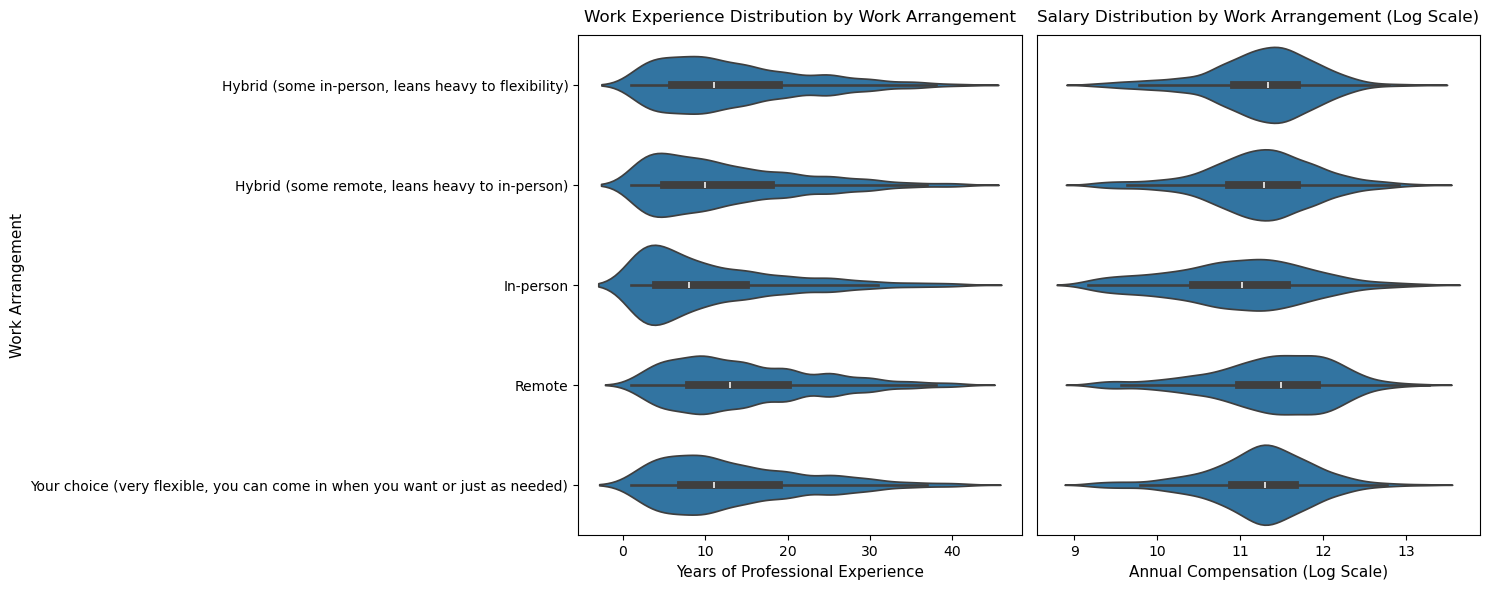

In [109]:
"""
Work Experience and Salary Distribution by Work Arrangement.

These violin plots compare the distributions of work experience (left) and
annual compensation (log-transformed) (right) across different work arrangements.
"""

# Create side-by-side violin plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Work experience violin plot
sns.violinplot(data=df, x="WorkExp", y="RemoteWork", ax=ax1)
ax1.set_title("Work Experience Distribution by Work Arrangement", fontsize=12, pad=10)
ax1.set_xlabel("Years of Professional Experience", fontsize=11)
ax1.set_ylabel("Work Arrangement", fontsize=11)
ax1.tick_params(axis="x")

# Salary violin plot
sns.violinplot(data=df, x="LogConvertedCompYearly", y="RemoteWork", ax=ax2)
ax2.set_title("Salary Distribution by Work Arrangement (Log Scale)", fontsize=12, pad=10)
ax2.set_xlabel("Annual Compensation (Log Scale)", fontsize=11)
ax2.set_yticklabels([])  # Remove redundant Y-axis labels
ax2.set_ylabel("")
ax2.tick_params(axis="y", left=False)

# Layout and cleanup
plt.tight_layout()
plt.show()

**Insights**

Overall, the distributions suggest that remote and hybrid professionals tend to have similar experience levels to those working in person, with no major deviation in median experience across groups. However, when examining compensation, remote workers and flexible arrangements show slightly higher salary medians and narrower distributions than fully in-person roles.

This pattern indicates that remote and hybrid work are more common among mid- to senior-level professionals—those with enough experience to negotiate flexible arrangements or work for international employers. Still, the overlap between categories suggests that experience, rather than work mode alone, remains the stronger driver of compensation differences.

#### 3.3.3 What profiles are more likely to work remotely?

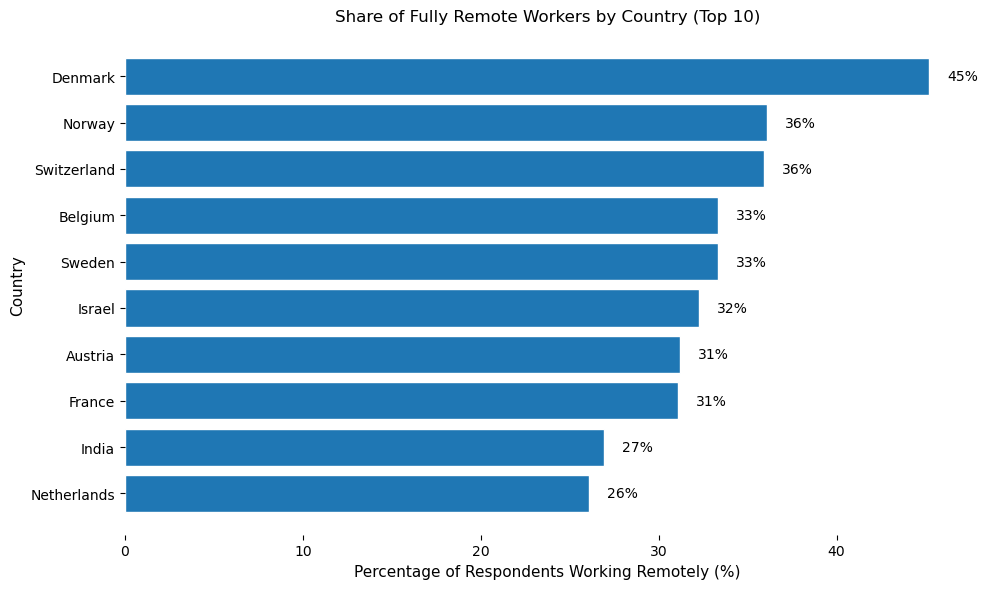

In [110]:
"""
Share of Fully Remote Workers by Country.

This bar chart displays the share of fully remote workers by country, focusing
on the top 10 nations with the highest adoption of remote work.
"""

# Select relevant columns
df_country = df[["Country", "RemoteWork"]].copy()

# Create proportion table (% remote by country)
remote_share = (
    pd.crosstab(df_country["Country"], df_country["RemoteWork"], normalize="index") * 100
)

# Apply data-quality safeguard
min_n = 100  # Ensures at least 100 valid responses per country
top_countries = df_country["Country"].value_counts()[lambda x: x >= min_n].index
remote_share = remote_share.loc[remote_share.index.isin(top_countries)]

# Ensure there is a "Fully remote" column (adjust according to dataset labels)
remote_col = [c for c in remote_share.columns if "remote" in c.lower()][0]
remote_share = remote_share.sort_values(by=remote_col, ascending=False).head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(
    remote_share.index,
    remote_share[remote_col],
    edgecolor="white",
    color="#1f77b4",
)

# Reverse order so highest values appear at the top
plt.gca().invert_yaxis()

# Titles and labels
plt.title("Share of Fully Remote Workers by Country (Top 10)", fontsize=12, pad=10)
plt.xlabel("Percentage of Respondents Working Remotely (%)", fontsize=11)
plt.ylabel("Country", fontsize=11)

# Add percentage labels
for i, v in enumerate(remote_share[remote_col].values):
    plt.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=10)

# Clean up chart
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

European countries dominate the ranking, led by Denmark, Norway, Switzerland, Belgium, and Sweden — all recognized for their strong digital infrastructure, flexible labor laws, and culture of work–life balance.

Outside Europe, Israel and India stand out as key global players. Israel’s high-tech ecosystem, centered on cybersecurity and software innovation, strongly supports hybrid and remote models. India, driven by its massive IT and outsourcing sectors, demonstrates how emerging economies can also sustain large-scale remote work adoption.

Overall, the data shows that remote work thrives where digital readiness, innovation, and knowledge-based industries converge, with Israel and India proving that leadership in remote adoption is not limited to Western Europe.


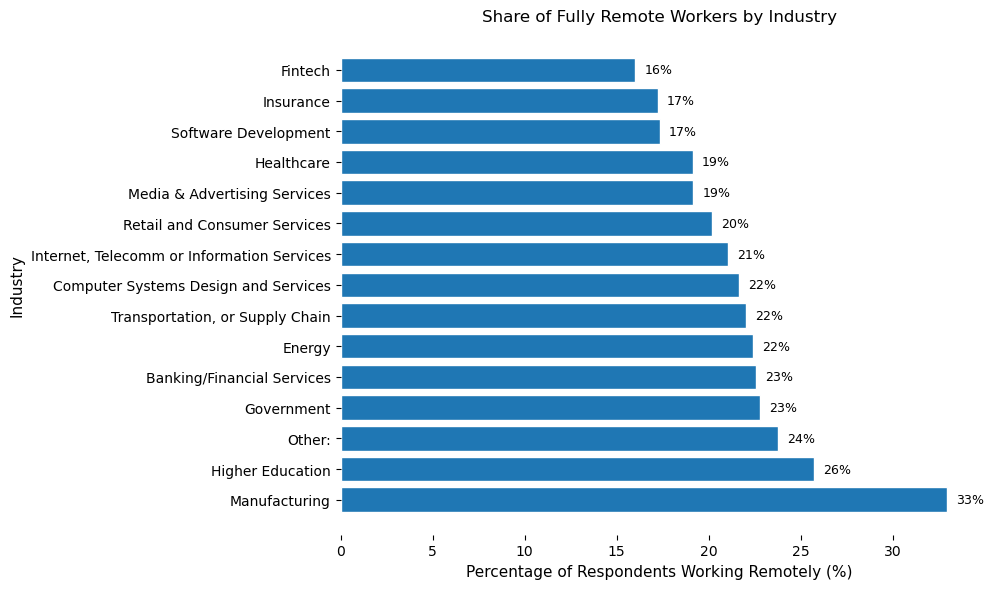

In [111]:
"""
Share of Fully Remote Workers by Industry.

This chart shows the percentage of professionals who work fully remotely,
grouped by industry. The data was normalized to represent each industry's
internal share of remote workers, ensuring comparability across different
sample sizes.
"""

# Calculate proportion of remote work by industry
df_industry = df[["Industry", "RemoteWork"]].copy()

# Frequency table: count by industry and type of work arrangement
ct = pd.crosstab(df_industry["Industry"], df_industry["RemoteWork"])

# Identify the column corresponding to remote work
remote_col = [c for c in ct.columns if "remote" in c.lower()][0]

# Compute percentages for each industry (normalized within rows)
prop = (ct.div(ct.sum(axis=1), axis=0) * 100).fillna(0)

# Sort industries by percentage of remote workers (ascending)
prop_sorted = prop.sort_values(by=remote_col, ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, max(6, len(prop_sorted) * 0.4)))  # Adjust height dynamically
bars = plt.barh(
    prop_sorted.index,
    prop_sorted[remote_col],
    edgecolor="white",
    color="#1f77b4",
)

# Titles and labels
plt.title("Share of Fully Remote Workers by Industry", fontsize=12, pad=10)
plt.xlabel("Percentage of Respondents Working Remotely (%)", fontsize=11)
plt.ylabel("Industry", fontsize=11)

# Add percentage labels to bars
for i, v in enumerate(prop_sorted[remote_col].values):
    if v > 0:
        plt.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
    else:
        plt.text(0.5, i, "0%", va="center", fontsize=9, color="gray")

# Reverse order so industries with highest remote share appear at the top
plt.gca().invert_yaxis()

# Clean up chart
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insights**

The results are somewhat unexpected: Manufacturing appears at the top, followed by Higher Education, Government, and Banking/Financial Services. Traditionally, manufacturing is associated with on-site work, which raises a flag for interpretation.

A closer look at the dataset suggests that this high share likely reflects sample composition rather than actual industry-wide behavior. Respondents who selected “Manufacturing” might represent administrative, engineering, or IT roles within manufacturing companies—positions that are far more compatible with remote work than factory or operational jobs.

In contrast, industries such as Fintech, Insurance, and Software Development show moderate shares, which may seem low but align with the greater prevalence of hybrid work in these sectors, rather than fully remote arrangements.

Overall, the findings suggest that remote work patterns vary strongly by job function even within industries, and that the survey responses capture a digital and knowledge-based segment of each field, rather than the full industry spectrum.

### 3.4 Multivariate Analysis

Investigate how multiple variables interact simultaneously, allowing you to identify complex patterns, combined effects, and factors that jointly influence outcomes.

#### 3.4.1 Does industry impact compensation and satisfaction, independent of experience?

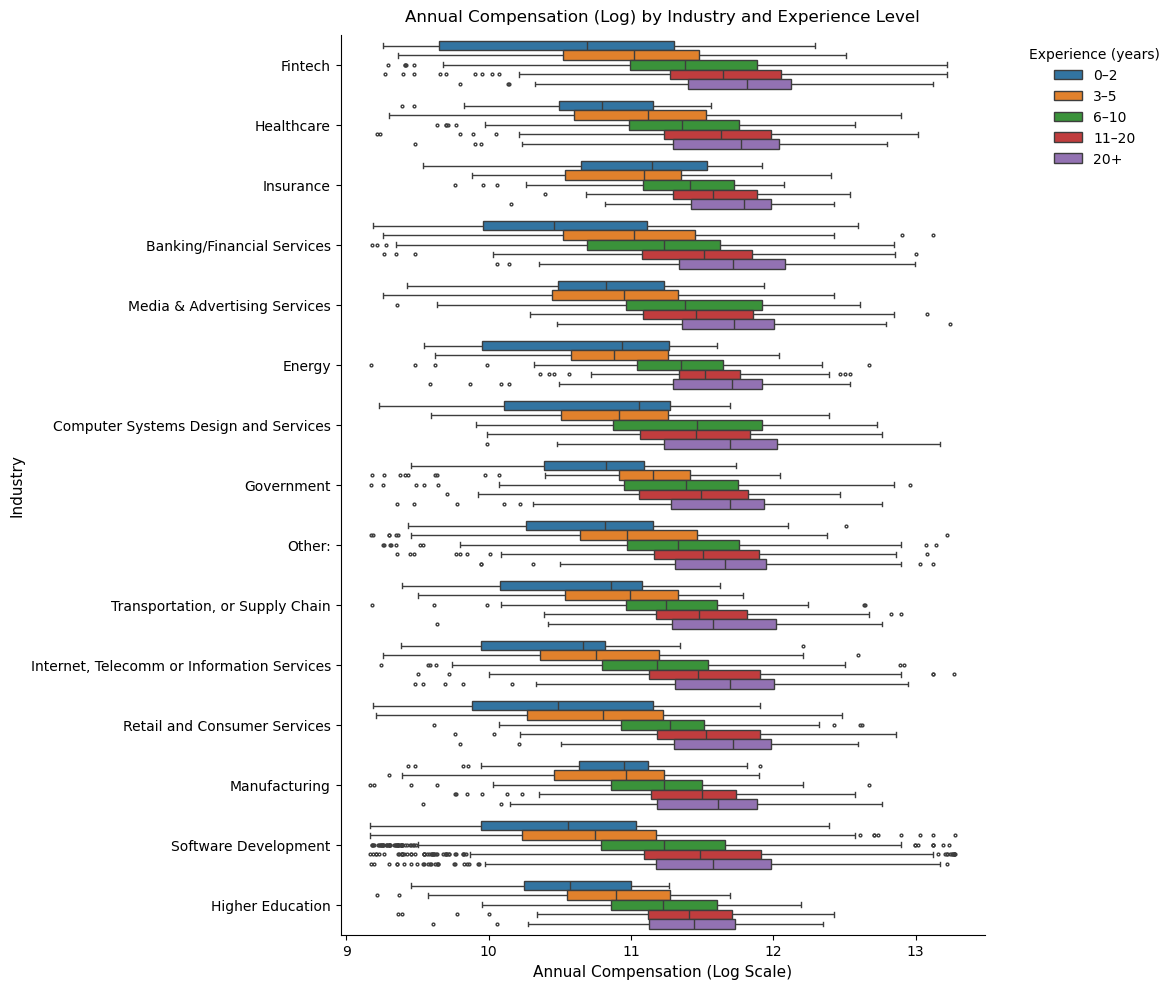

In [112]:
"""
Annual Compensation (Log) by Industry, Controlling for Experience.

This boxplot explores how annual compensation (log-transformed) varies across
industries while controlling for experience level via discrete experience bands.
"""

# Prepare data
df_box = df[["Industry", "WorkExp", "LogConvertedCompYearly"]].copy()

# Create experience bands
df_box["ExpGroup"] = pd.cut(
    df_box["WorkExp"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=["0–2", "3–5", "6–10", "11–20", "20+"],
    include_lowest=True,
)

# Sort industries by median salary (on the chosen scale)
order_by_med = (
    df_box.groupby("Industry", observed=False)["LogConvertedCompYearly"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Create horizontal boxplot: salary (log) × industry, colored by experience
plt.figure(figsize=(12, 10))
ax = sns.boxplot(
    data=df_box,
    y="Industry",
    x="LogConvertedCompYearly",
    hue="ExpGroup",
    order=order_by_med,
    fliersize=2,
    orient="h",
)

# Titles and labels
ax.set_title("Annual Compensation (Log) by Industry and Experience Level", fontsize=12, pad=10)
ax.set_xlabel("Annual Compensation (Log Scale)", fontsize=11)
ax.set_ylabel("Industry", fontsize=11)

# Legend
ax.legend(title="Experience (years)", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

# Cleanup
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Insights**

As expected, compensation tends to increase with years of experience in nearly all industries, visible through the gradual rightward shift from blue (0–2 years) to purple (20+ years). However, the rate of increase differs notably by sector.

Industries such as Fintech, Energy, and Healthcare show broader salary ranges and higher medians, reflecting stronger compensation growth with experience. In contrast, fields like Government, Media, and Education present narrower distributions and lower top quartiles, suggesting flatter salary progression over time.

Overall, while experience remains the strongest determinant of pay, industry choice clearly amplifies or limits earning potential, even when controlling for experience.

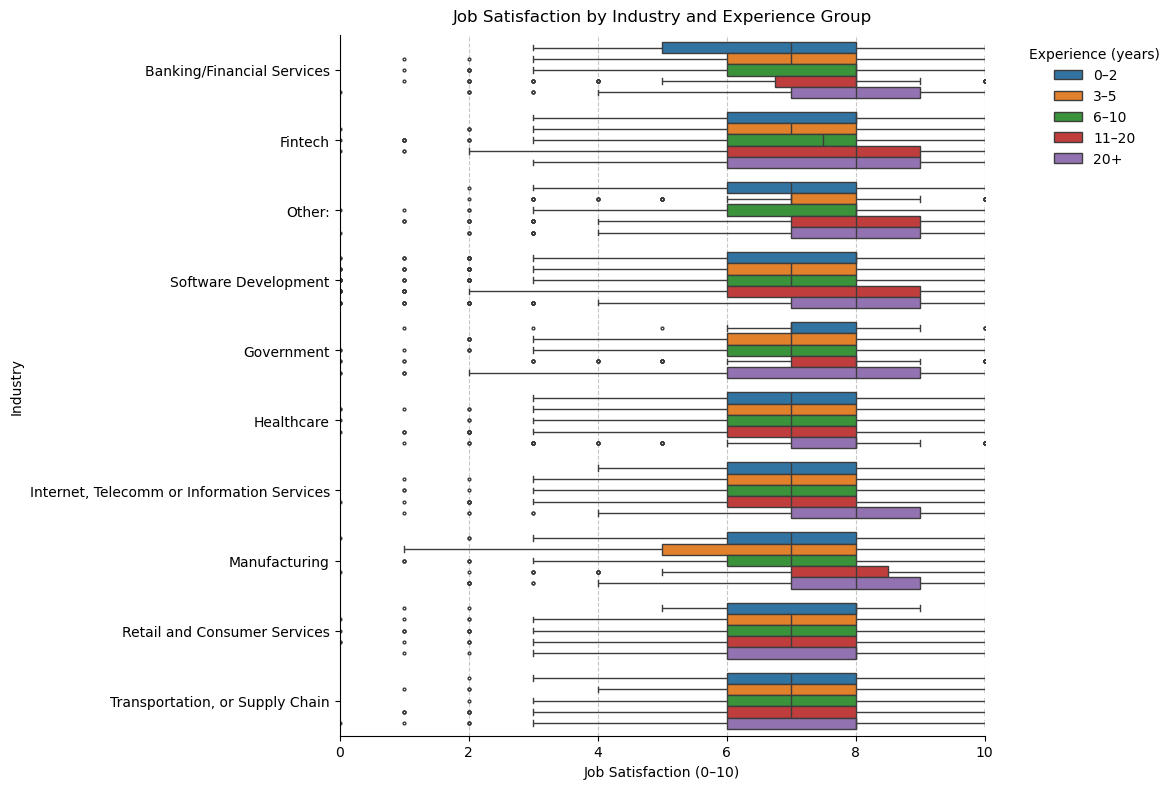

In [113]:
"""
Job Satisfaction (0–10) by Industry and Experience Group.

This chart compares job satisfaction scores across industries, segmented by
experience level.
"""

df_plot = df.copy()

# Convert JobSat to numeric
df_plot["JobSat"] = pd.to_numeric(df_plot["JobSat"], errors="coerce")

# Create experience bands (years)
df_plot["ExpGroup"] = pd.cut(
    df_plot["WorkExp"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=["0–2", "3–5", "6–10", "11–20", "20+"],
    include_lowest=True,
)

# Keep only valid columns
cols = ["Industry", "JobSat", "ExpGroup"]
df_plot = df_plot[cols]

# Select top 10 industries by number of responses
top_inds = df_plot["Industry"].value_counts().nlargest(10).index
df_plot = df_plot[df_plot["Industry"].isin(top_inds)]

# Sort industries by median job satisfaction
order_by_med = (
    df_plot.groupby("Industry", observed=True)["JobSat"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Create horizontal boxplot
plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    data=df_plot,
    y="Industry",
    x="JobSat",
    hue="ExpGroup",
    order=order_by_med,
    fliersize=2,
    orient="h",
)

# Titles and labels
ax.set_ylabel("Industry")
ax.set_xlabel("Job Satisfaction (0–10)")
ax.set_title("Job Satisfaction by Industry and Experience Group", fontsize=12, pad=10)

# Set X-axis limits to 0–10
ax.set_xlim(0, 10)

# Add vertical gridlines for readability
ax.grid(axis="x", linestyle="--", alpha=0.7)

# Legend
ax.legend(title="Experience (years)", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

# Cleanup
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Insights**

Overall, satisfaction levels remain relatively consistent across experience groups, with mid to senior professionals (6–20 years) generally reporting slightly higher satisfaction than early-career (0–2 years).

Industries like Fintech, Software Development, and Banking/Financial Services maintain higher median satisfaction, reinforcing their positive results from earlier analyses. In contrast, Healthcare and Transportation/Supply Chain again appear among the least satisfied, showing lower medians and broader variation across experience levels.

The distribution suggests that experience influences satisfaction modestly, but industry characteristics—such as innovation culture, flexibility, and compensation—have a stronger impact on how professionals rate their overall satisfaction.

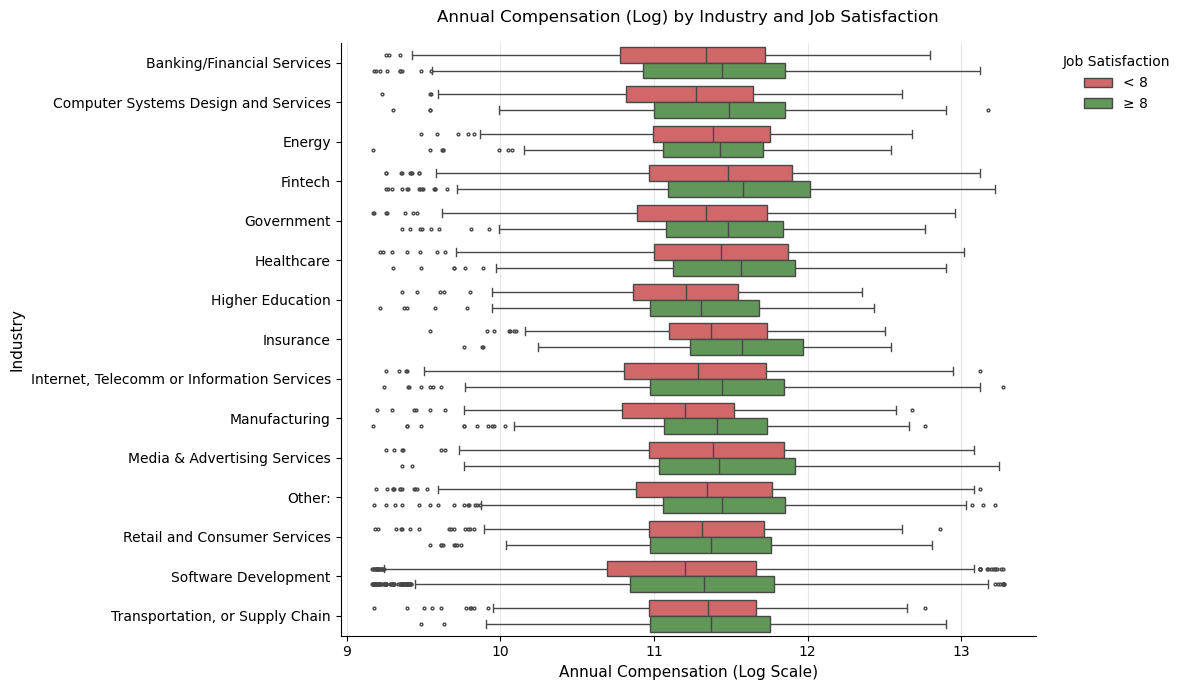

In [114]:
"""
Annual Compensation (Log) by Industry and Job Satisfaction.

This boxplot compares annual compensation (log-transformed) between developers
who report high (≥8) and low (<8) job satisfaction, segmented by industry.
"""

# Create boxplot
plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=df,
    x="LogConvertedCompYearly",
    y="Industry",
    hue="JobSat_bin",
    palette={0: "#E15759", 1: "#59A14F"},
    linewidth=1,
    fliersize=2,
)

# Titles and labels
plt.title("Annual Compensation (Log) by Industry and Job Satisfaction", fontsize=12, pad=15)
plt.xlabel("Annual Compensation (Log Scale)", fontsize=11)
plt.ylabel("Industry", fontsize=11)

# Legend formatting
handles, labels = ax.get_legend_handles_labels()
labels = ["< 8" if label == "0" else "≥ 8" for label in labels]
ax.legend(
    handles=handles,
    labels=labels,
    title="Job Satisfaction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

# General appearance and layout
sns.despine(top=True, right=True)
ax.grid(axis="x", alpha=0.3)
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

**Insights**

Overall, there’s a consistent trend across sectors: professionals with higher satisfaction tend to have slightly higher median salaries, visible by the green boxes being marginally shifted to the right. However, the distributions overlap strongly, indicating that while compensation may influence satisfaction, it is not the sole determining factor.

Industries such as Fintech, Energy, and Software Development show the clearest difference, where higher salaries more often coincide with greater satisfaction. Conversely, Healthcare and Government exhibit smaller gaps, suggesting that non-monetary aspects (like stability or mission-driven work) may weigh more heavily on job fulfillment in these fields.

### 3.5 Correlation

EXPLICAÇÃO CORRELAÇÃO

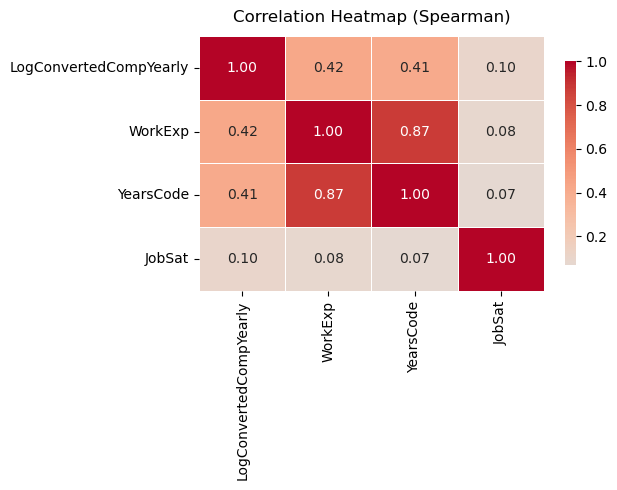

In [115]:
"""
Correlation Heatmap (Spearman).

A monotonic relationship is one in which, as one variable increases, the other
tends to either increase or decrease—but not necessarily linearly.
Spearman’s correlation measures monotonic relationships, is robust to outliers,
and is ideal for datasets mixing ordinal, binary, and continuous variables.
"""

# Select numeric columns of interest
cols = ["LogConvertedCompYearly", "WorkExp", "YearsCode", "JobSat"]
numeric_cols = [c for c in cols if c in df.columns]

# Create DataFrame for correlation analysis
corr_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Calculate and plot Spearman correlation heatmap
plt.figure(figsize=(6.5, 5))
sns.heatmap(
    corr_df.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
)

# Titles and layout
plt.title("Correlation Heatmap (Spearman)", fontsize=12, pad=10)
plt.tight_layout()
plt.show()


**Insights**

There is a moderate positive correlation between LogConvertedCompYearly and both WorkExp (ρ = 0.43) and YearsCode (ρ = 0.41), confirming that salary tends to increase with professional and coding experience. The strong correlation between WorkExp and YearsCode (ρ = 0.87) indicates that these variables largely capture overlapping aspects of career trajectory.

In contrast, JobSat shows only very weak correlations with all other variables (ρ ≈ 0.06–0.09), suggesting that job satisfaction is mostly independent of salary or experience. This implies that satisfaction is likely driven by other qualitative or organizational factors beyond compensation or years in the field.


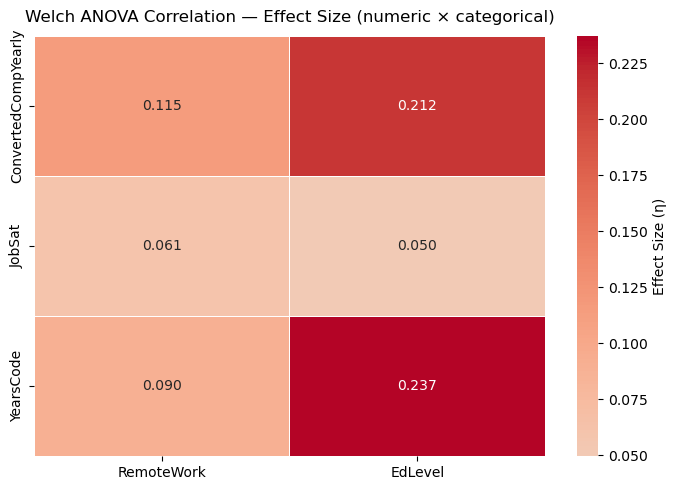


Interpretation of effect size (η):
  η ≈ 0.01–0.09 : SMALL effect (practically insignificant)
  η ≈ 0.10–0.29 : SMALL to MEDIUM effect (weak relationship)
  η ≈ 0.30–0.49 : MEDIUM to LARGE effect (moderate relationship)
  η ≥ 0.50      : LARGE effect (strong relationship)


In [116]:
"""
Welch's ANOVA: rationale.

As independence is satisfied and both normality and homoscedasticity are only
slightly violated, Welch's ANOVA can be reasonably applied. It is more robust
when the homogeneity of variances assumption is violated. Using a logarithmic
transformation for compensation helps stabilize variance, but results should be
interpreted as robust trends, not strict parametric inferences.
"""


def welch_anova_correlation(df, num_col, cat_col):
    """
    Compute an effect-size-like correlation (sqrt of η²) via Welch's ANOVA.

    Parameters
    ----------
    df : pandas.DataFrame
        Source DataFrame.
    num_col : str
        Name of the numeric dependent variable (dv).
    cat_col : str
        Name of the categorical between-subject factor.

    Returns
    -------
    float
        Square root of eta-squared derived from Welch's ANOVA F and denominator
        df (≈ effect-size correlation). Returns NaN if not computable.
    """
    temp_df = df[[num_col, cat_col]].dropna()

    if temp_df[cat_col].nunique() >= 2 and len(temp_df) > 10:
        anova_result = pg.welch_anova(data=temp_df, dv=num_col, between=cat_col)
        f_stat = anova_result["F"].iloc[0]
        df_denom = anova_result["ddof2"].iloc[0]

        # Eta-squared approximation for Welch's ANOVA
        eta_squared = f_stat / (f_stat + df_denom)
        return float(np.sqrt(eta_squared))

    return float("nan")


# Column configuration
categorical_cols = ["RemoteWork", "EdLevel"]
numeric_cols = ["ConvertedCompYearly", "JobSat", "YearsCode"]

# Keep only existing columns
categorical_cols = [c for c in categorical_cols if c in df.columns]
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Calculate correlation matrix (numeric × categorical)
corr_matrix = pd.DataFrame(index=numeric_cols, columns=categorical_cols)

for num_col in numeric_cols:
    for cat_col in categorical_cols:
        corr_matrix.loc[num_col, cat_col] = welch_anova_correlation(df, num_col, cat_col)

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix.astype(float),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Effect Size (η)"},
)
plt.title("Welch ANOVA Correlation — Effect Size (numeric × categorical)", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print("\nInterpretation of effect size (η):")
print("  η ≈ 0.01–0.09 : SMALL effect (practically insignificant)")
print("  η ≈ 0.10–0.29 : SMALL to MEDIUM effect (weak relationship)")
print("  η ≈ 0.30–0.49 : MEDIUM to LARGE effect (moderate relationship)")
print("  η ≥ 0.50      : LARGE effect (strong relationship)")

**Insights**

Results show that education level (EdLevel) has the strongest association with both compensation (η = 0.208) and coding experience (YearsCode, η = 0.237), indicating that higher education tends to be moderately linked to greater experience and higher pay. However, these are small-to-medium effects, suggesting other factors also play substantial roles.

The relationship between remote work arrangement (RemoteWork) and compensation or experience is weak (η ≈ 0.10–0.12), showing that working remotely does not significantly affect salary or experience level in this sample.

Finally, job satisfaction (JobSat) shows negligible associations with both education and remote work (η ≈ 0.05), reinforcing earlier findings that satisfaction depends more on qualitative workplace factors rather than demographic or structural variables.

### 3.6 Feature engineering

#### 3.6.1 Treatment of the ordinal variable EdLevel

The simple hierarchical ordering of educational levels causes the model to interpret the "Other" category as a higher or lower educational level, which is incorrect, as its hierarchy is undefined.\
To address this issue, the ordinal order of 0 to 6 is maintained for the standard levels, and "Other" is positioned at the end of the scale. Additionally, a binary flag is created (is_other = 1 for "Other," 0 otherwise). This approach signals to the model the presence of a distinct group without compromising the expected ordinal progression of the other educational levels.

In [117]:
"""
Ordinal Encoding for Education Level (ISCED Hierarchy).

This step maps education levels to an ordinal scale (0–7) following the ISCED
hierarchy and creates a binary flag for "Other" responses.
"""

# Define ordinal mapping for education level (0–7)
education_order_map = {
    "Primary/elementary school": 0,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2,
    "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    "Other (please specify):": 7,
}

# Create binary flag for "Other"
df["EdLevel_is_other"] = (df["EdLevel"] == "Other (please specify):").astype(int)

# Apply ordinal mapping (0–7)
df["EdLevel_ord"] = df["EdLevel"].map(education_order_map).astype("Int64")

In [118]:
df.sample(3) #Checks modifications

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,ICorPM,JobSat,LogConvertedCompYearly,JobSat_bin,EdLevel_is_other,EdLevel_ord
13293,440000,United States of America,27,33,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Developer, back-end",C++,500 to 999 employees,Banking/Financial Services,"Your choice (very flexible, you can come in wh...",Individual contributor,10,12.994532,1,0,6
26763,35381,Philippines,9,21,Some college/university study without earning ...,"Developer, full-stack",Bash/Shell (all shells);C;Go;HTML/CSS;JavaScri...,20 to 99 employees,Software Development,Remote,Individual contributor,8,10.473958,1,0,2
25400,50314,Sweden,2,4,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Assembly;Bash/Shell (all shells);C;C++;Groovy;...,"10,000 or more employees",Software Development,"Hybrid (some in-person, leans heavy to flexibi...",Individual contributor,8,10.826059,1,0,4


#### 3.6.2 Treatment of the ordinal variable OrgSize

The simple hierarchical ordering of organizational sizes (small → large) causes the model to interpret the "I don't know" category as a larger or smaller size, which is incorrect because its hierarchy is undefined.

To address this issue, the ordinal order of 0 to 7 is maintained for the standard sizes, and "I don't know" is positioned at the end of the scale. Additionally, a binary indicator is created (is_unknown = 1 for "I don't know," 0 otherwise). This approach signals to the model the presence of a distinct group without compromising the expected ordinal progression of the other organizational sizes.

In [119]:
"""
Ordinal Encoding for Organization Size (0–8).

This step maps organization size categories to an ordinal scale (0–8) and
creates a binary flag for responses marked as "I don’t know".
"""

# Define ordinal mapping for organization size (0–8)
orgsize_order_map = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0,
    "Less than 20 employees": 1,
    "20 to 99 employees": 2,
    "100 to 499 employees": 3,
    "500 to 999 employees": 4,
    "1,000 to 4,999 employees": 5,
    "5,000 to 9,999 employees": 6,
    "10,000 or more employees": 7,
    "I don’t know": 8,
}

# Create binary flag for unknown organization size
df["OrgSize_is_unknown"] = (df["OrgSize"] == "I don’t know").astype(int)

# Apply ordinal mapping (0–8)
df["OrgSize_ord"] = df["OrgSize"].map(orgsize_order_map).astype("Int64")

In [120]:
# Check random sample of 3 rows to verify recent modifications
df.sample(3)

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,ICorPM,JobSat,LogConvertedCompYearly,JobSat_bin,EdLevel_is_other,EdLevel_ord,OrgSize_is_unknown,OrgSize_ord
15172,95000,United States of America,4,22,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Data engineer,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,100 to 499 employees,Energy,"Hybrid (some remote, leans heavy to in-person)",Individual contributor,8,11.461643,1,0,5,0,3
10730,62017,South Africa,17,17,"Secondary school (e.g. American high school, G...","Developer, front-end",HTML/CSS;JavaScript,"10,000 or more employees","Internet, Telecomm or Information Services",Remote,Individual contributor,6,11.035180,0,0,1,0,7
5489,98612,Finland,20,25,"Associate degree (A.A., A.S., etc.)","Architect, software or solutions",Bash/Shell (all shells);C#;Java;Kotlin,"1,000 to 4,999 employees",Software Development,"Hybrid (some remote, leans heavy to in-person)",Individual contributor,9,11.498958,1,0,3,0,5


#### 3.6.3 Multiple variables stored in a single column

During data assessment, it was identified that `LanguageHaveWorkedWith` and `DevType` contains semicolon-separated data lists within single cells. While this violates tidy data principles, converting these to one row per technology/role would create artificial data duplication. Therefore, it will be created a 0/1 column for each language/role.

In [121]:
"""
Binary Encoding for Programming Languages.

This step creates binary columns for selected programming languages — including
those with the highest average salaries and the most popular ones. Each language
is encoded as 1 if the respondent has worked with it, and 0 otherwise.
"""

# Define source column
lang_col = "LanguageHaveWorkedWith"

# Define selected programming languages
languages = [
    "Lisp", "Scala", "OCaml", "Ruby", "Erlang", "Perl", "Elixir", "Go",
    "Zig", "Swift", "F#", "Rust", "Gleam", "Groovy", "Prolog", "JavaScript",
    "HTML/CSS", "SQL", "Python", "Bash/Shell (all shells)", "TypeScript",
    "C#", "Java", "PowerShell", "C++",
]


# Helper function to create safe column names
def safe_col(name: str) -> str:
    """Return a sanitized version of a language name as a valid column name."""
    import re
    return "Lang_" + re.sub(r"[^0-9a-zA-Z]+", "_", name).strip("_")


# Create binary sets from the language column
lang_sets = (
    df[lang_col]
    .fillna("")
    .astype(str)
    .str.split(";")
    .apply(lambda L: {x.strip() for x in L if x and x.strip() != ""})
)

# Generate deterministic binary columns for each selected language
for lang in languages:
    col = safe_col(lang)
    df[col] = lang_sets.apply(lambda s: np.uint8(lang in s))

In [122]:
# Check first row to verify language encoding and recent modifications
df.head(1)

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,...,Lang_Prolog,Lang_JavaScript,Lang_HTML_CSS,Lang_SQL,Lang_Python,Lang_Bash_Shell_all_shells,Lang_TypeScript,Lang_C,Lang_Java,Lang_PowerShell
0,61256,Ukraine,8,14,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,...,0,0,0,1,0,1,0,0,0,0


In [123]:
"""
Binary Encoding for Developer Roles.

This step extracts all unique developer roles from the 'DevType' column and
creates binary columns for each role, encoding presence (1) or absence (0)
for every respondent.
"""

# Extract unique developer roles
dev_roles = (
    df["DevType"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda x: x != ""]
    .unique()
    .tolist()
)

# Create binary columns for each developer role
for role in dev_roles:
    col = "DevType_" + role.replace(" ", "_").replace("/", "_").replace(",", "")
    df[col] = (df["DevType"] == role).astype(np.uint8)


In [124]:
df.head(3) #Checks modifications

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,...,DevType_Developer_QA_or_test,DevType_Database_administrator_or_engineer,DevType_Product_manager,DevType_Project_manager,DevType_Support_engineer_or_analyst,DevType_Founder_technology_or_otherwise,DevType_Student,DevType_UX_Research_Ops_or_UI_design_professional,DevType_Financial_analyst_or_engineer,DevType_System_administrator
0,61256,Ukraine,8,14,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,...,0,0,0,0,0,0,0,0,0,0
1,104413,Netherlands,2,10,"Associate degree (A.A., A.S., etc.)","Developer, back-end",Java,500 to 999 employees,Retail and Consumer Services,"Hybrid (some in-person, leans heavy to flexibi...",...,0,0,0,0,0,0,0,0,0,0
3,36197,Ukraine,4,5,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end",Java;Kotlin;SQL,"10,000 or more employees",Retail and Consumer Services,Remote,...,0,0,0,0,0,0,0,0,0,0


#### 3.6.4 Binary representation of "RemoteWork" to check flexibility

To enable clearer comparisons and model interpretation, the "RemoteWork" categories are preferred to be consolidated into a binary variable indicating the degree of flexibility: 0 for on-site arrangements and 1 for remote or flexible setups.

In [125]:
# Define category groups com verificação robusta
remote_positive = {
    "Remote",
    "Your choice (very flexible, you can come in when you want or just as needed)",
    "Hybrid (some in-person, leans heavy to flexibility)",
}

remote_negative = {
    "In-person", 
    "Hybrid (some remote, leans heavy to in-person)",
}

#Normalizadas para comparação
remote_positive_normalized = {s.strip().lower() for s in remote_positive}
remote_negative_normalized = {s.strip().lower() for s in remote_negative}

# Função de mapeamento robusta
def map_remote_work(value):
    """
    Map raw RemoteWork responses into a binary encoding (1 = flexible/remote, 0 = in-person).

    This function processes the original text values from the 'RemoteWork' column
    and assigns them to a binary variable based on whether the response indicates 
    flexibility/remote work or in-person requirements. The function uses 
    normalized string matching and predefined category groups to ensure robust 
    classification even when values contain variations in spacing or capitalization.

    The classification rules are:
        - Returns 1 if the value matches any category associated with remote or 
          flexibility-heavy hybrid arrangements.
        - Returns 0 if the value matches categories that represent in-person or 
          in-person–leaning hybrid arrangements.
        - Returns NaN if the value does not match either group.

    Parameters
    ----------
    value : str or object
        Raw input from the 'RemoteWork' column. May contain strings, missing values,
        or unexpected categories.

    Returns
    -------
    int or numpy.nan
        - 1 for remote/flexible work categories
        - 0 for in-person or mostly in-person hybrid categories
        - NaN for unrecognized or missing values
    """
    if pd.isna(value):
        return np.nan
    
    value_normalized = str(value).strip().lower()
    
    if any(pos in value_normalized for pos in remote_positive_normalized):
        return 1
    elif any(neg in value_normalized for neg in remote_negative_normalized):
        return 0
    else:
        return np.nan

# Aplicar o mapeamento
df["RemoteWork_bin"] = df["RemoteWork"].apply(map_remote_work).astype("Int8")

In [126]:
#Quick audit of missing values
df.isnull().sum().sort_values(ascending=True)

ConvertedCompYearly                                     0
DevType_Developer_desktop_or_enterprise_applications    0
DevType_Academic_researcher                             0
DevType_Senior_executive_(C-suite_VP_etc.)              0
DevType_AI_ML_engineer                                  0
                                                       ..
Lang_Erlang                                             0
Lang_Ruby                                               0
Lang_OCaml                                              0
Lang_Lisp                                               0
RemoteWork_bin                                          0
Length: 74, dtype: int64

In [127]:
# Check first row to verify recent transformations
df.head(1)

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,...,DevType_Database_administrator_or_engineer,DevType_Product_manager,DevType_Project_manager,DevType_Support_engineer_or_analyst,DevType_Founder_technology_or_otherwise,DevType_Student,DevType_UX_Research_Ops_or_UI_design_professional,DevType_Financial_analyst_or_engineer,DevType_System_administrator,RemoteWork_bin
0,61256,Ukraine,8,14,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,...,0,0,0,0,0,0,0,0,0,1


#### 3.6.5 Binary representation of "ICorPM"

To enable clearer comparisons and model interpretation, the "ICorPM" categorie is preferred to be consolidated into a binary variable indicating whether the respondent is an Individual Contributor (=1) or People Manager (=0).

In [128]:
"""
Binary Encoding for Role Type.

This transformation creates a binary variable to distinguish between
individual contributors (1) and people managers (0).
"""

# Create binary encoding for role type
df["ICorPM_bin"] = (df["ICorPM"] == "Individual contributor").astype("Int8")

In [129]:
# Check first row to verify recent transformations
df.head(1)

,ConvertedCompYearly,Country,WorkExp,YearsCode,EdLevel,DevType,LanguageHaveWorkedWith,OrgSize,Industry,RemoteWork,...,DevType_Product_manager,DevType_Project_manager,DevType_Support_engineer_or_analyst,DevType_Founder_technology_or_otherwise,DevType_Student,DevType_UX_Research_Ops_or_UI_design_professional,DevType_Financial_analyst_or_engineer,DevType_System_administrator,RemoteWork_bin,ICorPM_bin
0,61256,Ukraine,8,14,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Bash/Shell (all shells);Dart;SQL,20 to 99 employees,Fintech,Remote,...,0,0,0,0,0,0,0,0,1,0


In [130]:
#Quick audit of missing values
df.isnull().sum().sort_values(ascending=True)

ConvertedCompYearly                                     0
DevType_Other_(please_specify):                         0
DevType_Developer_desktop_or_enterprise_applications    0
DevType_Academic_researcher                             0
DevType_Senior_executive_(C-suite_VP_etc.)              0
                                                       ..
Lang_Erlang                                             0
Lang_Ruby                                               0
Lang_OCaml                                              0
Lang_Lisp                                               0
ICorPM_bin                                              0
Length: 75, dtype: int64

## 4. Data Preparation

### 4.1 Helper functions

In [131]:
def split_task_specific(
    df,
    target_col,
    feature_cols,
    test_size=0.2,
    random_state=42,
    stratify_bin=None,
):
    """
    Custom train-test split function.
    
    This function splits the dataset into training and testing subsets
    based on selected features and a target variable. It supports optional
    stratification to preserve the distribution of categorical variables.
    
    Parameters:
    - df: Complete DataFrame
    - target_col: Column name of the target variable
    - feature_cols: List of feature column names
    - test_size: Fraction of data to include in the test set (default: 0.2)
    - random_state: Random seed for reproducibility (default: 42)
    - stratify_bin: Optional column used for stratified sampling
    
    Returns:
    - X_train: Training features
    - X_test: Testing features
    - y_train: Training target
    - y_test: Testing target
    """
    # Filter relevant columns and drop missing target values
    data = df[feature_cols + [target_col]].dropna(subset=[target_col])

    # Prepare stratification if applicable
    strat = data[stratify_bin] if stratify_bin and stratify_bin in data.columns else None

    # Perform the split
    return train_test_split(
        data[feature_cols],
        data[target_col],
        test_size=test_size,
        random_state=random_state,
        stratify=strat,
    )

The `split_task_specific` function divides the dataset into two parts — a training set and a testing set — in a clear and controlled way.

It removes missing values from the target column, optionally preserves class proportions through stratification, and ensures reproducibility with a fixed random seed.

This step is essential to evaluate model performance on unseen data and to prevent information leakage between training and testing phases.

In [132]:
def _target_encode_oof_fit(series, y, n_splits=5, random_state=42):
    """
    Target Encoding with Out-of-Fold and Smoothing

    Parameters:
    - series: categorical column to encode
    - y: target variable (numeric values)
    - n_splits: number of folds for validation (default: 5)
    - random_state: seed for reproducibility (default: 42)
    
    Returns:
    - oof_values: encoded values without leakage for training
    - mapping: dictionary to encode new data
    - global_mean: global mean of the target (used as a fallback)
    """
    cat = series.astype(str)
    y = y.astype(float)

    #Automatic 'm'
    counts = cat.value_counts()
    avg_n = counts.mean()
    m = max(1.0, avg_n / 2.0)  #Guarantees a reasonable minimum

    #Global target average (needed for smoothing and fallback)
    global_mean = y.mean()

    #OOF
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_values = pd.Series(index=cat.index, dtype=float)

    for train_idx, val_idx in kf.split(cat):
        cat_tr, cat_val = cat.iloc[train_idx], cat.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        stats = (
            pd.DataFrame({'cat': cat_tr, 'y': y_tr})
            .groupby('cat')
            .agg(n=('y', 'size'), mean=('y', 'mean'))
        )
        #Smoothing
        stats['smooth'] = (stats['n'] * stats['mean'] + m * global_mean) / (stats['n'] + m)

        val_map = stats['smooth'].to_dict()
        #Fallback for categories not seen in the training fold
        oof_values.iloc[val_idx] = cat_val.map(val_map).fillna(global_mean)

    #Final mapping using ALL training (to transform the TEST)
    full_stats = (
        pd.DataFrame({'cat': cat, 'y': y})
        .groupby('cat')
        .agg(n=('y', 'size'), mean=('y', 'mean'))
    )
    full_stats['smooth'] = (full_stats['n'] * full_stats['mean'] + m * global_mean) / (full_stats['n'] + m)
    mapping = full_stats['smooth'].to_dict()

    return oof_values, mapping, global_mean


def target_encode_transform(category_series, mapping, global_mean):
    '''
    Applies the mapping learned in "_target_encode_oof_fit_auto" to transform new categories into numbers.

    Parameters:
    - category_series: New categorical data to transform
    - mapping: Mapping dictionary learned during training
    - global_mean: Global mean of the training target
    
    Returns:
    - Series with encoded values ready for use in models
    '''
    return category_series.map(mapping).fillna(global_mean).astype(float) #Global average as fallback (default value)


The functions `_target_encode_oof_fit_auto` and `target_encode_transform` are used to convert categorical variables into numerical values based on the mean of the target, while preventing data leakage.

`_target_encode_oof_fit_auto(category_series, y)`\
This function “learns” the encoding on the training set.
It splits the training data into several parts (K-Folds), computes the mean target value for each category using only the training folds, and applies that value to the validation fold — ensuring that each row receives an encoding calculated without using its own target.
It also applies an automatic smoothing parameter (m), which reduces the influence of categories with few samples.
The function returns:

oof_values: the safely encoded values for the training set;

mapping: a dictionary {category → encoded value} learned from the training data;

global_mean: the overall target mean (used as a fallback).

`target_encode_transform(category_series, mapping, global_mean)`\
This function “applies” the encoding to new data (such as the test set).
It replaces each category with the value learned in the mapping.
If a new or unseen category appears, the function uses the global_mean as the default value.

Together, these functions allow categorical variables to be represented by numerical values that reflect their relationship with the target, without data leakage and with greater statistical stability.

### 4.2 Preparation by target category

#### 4.2.1 Target category: Yearly Compensation

*Features selected for  yearly compensation prediction:*

*Country* — captures differences in compensation levels across countries and regions.

*Industry* — reflects how salaries vary between business sectors (e.g., technology, finance, education).

*WorkExp* — represents total years of professional experience, a strong predictor of salary growth.

*RemoteWork_bin* — binary variable indicating whether the professional works remotely or on-site, used to analyze how flexibility impacts compensation.

*ICorPM_bin* — distinguishes between Individual Contributors and People Managers, controlling for differences in job level and responsibility.

*EdLevel_ord* / *EdLevel_is_other* — represent education level in ordered and “other” categories, allowing the model to measure how education affects salary.

*OrgSize_ord* / *OrgSize_is_unknown* — indicate the company’s size, capturing how salaries differ between small and large organizations.

*Lang_* — dummy variables for programming languages used, describing the developer’s technical stack.

*DevType_* — dummy variables for developer roles (e.g., backend, data scientist, manager), representing how job type influences pay.

Together, these features combine demographic, professional, organizational, and technical factors that most strongly explain salary differences among developers.

In [133]:
"""
Salary model — feature preparation (log target).

- Selects Lang_* and DevType_* columns
- Splits data into train/test without leakage
- Target Encoding (OOF) for Country
- One-Hot Encoding for Industry (fit on train, align on test)
- Assembles final numeric matrices for salary prediction
- Median imputation (train-based) to remove NaNs
"""

import re

# 1) Get all columns that start with "Lang_" and "DevType_"
lang_cols = [col for col in df.columns if re.match(r"^Lang_", col)]
devtype_cols = [col for col in df.columns if re.match(r"^DevType_", col)]

salary_features = [
    "Country",
    "Industry",
    "WorkExp",
    "ICorPM_bin",
    "EdLevel_ord",
    "EdLevel_is_other",
    "OrgSize_ord",
    "OrgSize_is_unknown",
    "RemoteWork_bin",
] + lang_cols + devtype_cols

# 2) Split target (log salary) before any encoding/transformation to prevent leakage
x_train, x_test, y_train_salary, y_test_salary = split_task_specific(
    df,
    target_col="LogConvertedCompYearly",
    feature_cols=salary_features,
    test_size=0.2,
    random_state=42,
)

# 3) Target Encoding (Country) OOF (versus target log)
#    Replaces each country with the smoothed average wages of that country
country_oof, country_map, country_global = _target_encode_oof_fit(
    x_train["Country"],
    y_train_salary,
    n_splits=5,
    random_state=42,
)

# 4) One-Hot for Industry (fit on train → apply on test)
ind_train = pd.get_dummies(
    x_train["Industry"].astype(str),
    prefix="Industry",
).astype("int8")

ind_test_raw = pd.get_dummies(
    x_test["Industry"].astype(str),
    prefix="Industry",
).astype("int8")

# Align the test to the same columns as the train
ind_test = ind_test_raw.reindex(columns=ind_train.columns, fill_value=0)

# 5) Assemble final matrices (numeric + encoded)
x_train_salary = pd.DataFrame(index=x_train.index)
x_test_salary = pd.DataFrame(index=x_test.index)

# Base numeric
x_train_salary["WorkExp"] = x_train["WorkExp"].astype(float)
x_test_salary["WorkExp"] = x_test["WorkExp"].astype(float)

# Country TE
x_train_salary["te_country"] = country_oof
x_test_salary["te_country"] = target_encode_transform(
    x_test["Country"], country_map, country_global
)

# Industry OHE
x_train_salary = x_train_salary.join(ind_train)
x_test_salary = x_test_salary.join(ind_test)

# Binary/ordinal numbers already prepared in the data frame
for col in [
    "ICorPM_bin",
    "EdLevel_ord",
    "EdLevel_is_other",
    "OrgSize_ord",
    "OrgSize_is_unknown",
    "RemoteWork_bin"
]:
    x_train_salary[col] = x_train[col].astype(float)
    x_test_salary[col] = x_test[col].astype(float)

# Dummies Lang_* and DevType_* (already in x_train/x_test because they were in salary_features)
for col in lang_cols + devtype_cols:
    if col in x_train.columns:
        x_train_salary[col] = x_train[col].astype(float)
        x_test_salary[col] = x_test[col].astype(float)

print(
    "Yearly compensation (Log target) — shapes:",
    x_train_salary.shape,
    x_test_salary.shape,
)

# 6) Median imputation (train-based) to avoid NaNs in LinearRegression
for c in x_train_salary.columns:
    if pd.api.types.is_numeric_dtype(x_train_salary[c]):
        median_val = x_train_salary[c].median()
        x_train_salary[c] = x_train_salary[c].fillna(median_val)
        x_test_salary[c] = x_test_salary[c].fillna(median_val)


Yearly compensation (Log target) — shapes: (11595, 78) (2899, 78)


First, the relevant variables are chosen, and then the data are divided into training (80%) and test (20%) sets before any transformation, avoiding data leakage. The target is used on a logarithmic scale to improve the normality of the residuals and allow for percentage interpretation of the coefficients.

In the transformation step, the country (“Country”) is coded using Target Encoding (TE) with an Out-of-Fold (OOF) scheme, which replaces each country with the logarithmic average salary, without using information from the row itself. The “Industry” variable receives One-Hot Encoding (OHE), creating dummies in the training and aligning the test to the same columns. Other pre-defined binary and ordinal variables are included directly, and the “Lang_” and “DevType_” columns are kept as numerical dummies.

inally, median imputation is applied based on the training data to remove missing values, using the same median values when filling the test set. Additionally, the one-hot encoded test matrix is aligned to the training matrix using column reindexing, filling missing columns with zeros. This ensures structural compatibility between train and test datasets while preventing any form of data leakage.

#### 4.2.2 Target category: Job satisfaction

*Features selected for job satisfaction prediction:*

*Country (TE_Country)* — captures cultural, economic, and workplace differences between countries that can influence employees’ perception of satisfaction.

*Industry* — represents the business sector, since certain industries (e.g., technology, finance, or education) are known to differ in working conditions, job stability, and employee engagement.

*WorkExp* — reflects total years of professional experience, a proxy for career maturity and skill level, both of which often relate to satisfaction and autonomy at work.

*RemoteWork_bin* — indicates whether the developer works remotely or on-site, allowing analysis of how flexibility and work–life balance affect satisfaction.

*ICorPM_bin* — distinguishes between Individual Contributors and People Managers, capturing differences in job scope, responsibility, and sense of impact.

*EdLevel_ord* — represents education level as an ordinal variable, accounting for how formal education relates to career opportunities and fulfillment.

*OrgSize_ord* — indicates the size of the organization, reflecting differences in structure, culture, and employee experience across small and large companies.

*LogConvertedCompYearly* — the variable captures the fundamental relationship between financial reward and job satisfaction.

*DevType_* — dummy variables for developer roles (e.g., backend, data scientist, engineering manager), capturing how job functions differ in workload, recognition, and motivation.

Together, these features combine demographic, professional, organizational, and technical factors that most plausibly explain why some developers report higher job satisfaction than others, enabling the model to identify which variables contribute most strongly to a positive work experience.

In [134]:
"""
Data preparation for the Job Satisfaction model.

- Target: JobSat_bin (1 = high satisfaction, ≥ 8)
- Features: TE(Country), OHE(Industry), WorkExp, LogConvertedCompYearly,
  RemoteWork_bin, ICorPM_bin, EdLevel_ord, OrgSize_ord, EdLevel_is_other,
  OrgSize_is_unknown, and DevType_* binaries.
"""

# Define features for satisfaction prediction
job_features = [
    "Country",
    "Industry",
    "WorkExp",
    "RemoteWork_bin",
    "ICorPM_bin",
    "EdLevel_ord",
    "OrgSize_ord",
    "EdLevel_is_other",
    "OrgSize_is_unknown",
    "LogConvertedCompYearly",
]

# Add developer role binaries (no language columns here)
devtype_cols = [c for c in df.columns if c.startswith("DevType_")]
job_features += devtype_cols

target_col = "JobSat_bin"  # 1 = high satisfaction (≥ 8)

# Split data (stratified by target)
x_train, x_test, y_train, y_test = split_task_specific(
    df,
    target_col=target_col,
    feature_cols=job_features,
    test_size=0.2,
    random_state=42,
    stratify_bin=target_col,
)

# ----- Target Encoding (Country) with smoothing -----
global_mean = y_train.mean()
country_stats = (
    pd.DataFrame({"Country": x_train["Country"], "y": y_train})
    .groupby("Country", observed=False)["y"]
    .agg(mean="mean", size="size")
)
m = country_stats["size"].mean() / 2  # smoothing strength
country_stats["smooth"] = (
    (country_stats["size"] * country_stats["mean"] + m * global_mean)
    / (country_stats["size"] + m)
)
country_map = country_stats["smooth"].to_dict()

x_train["te_country"] = x_train["Country"].map(country_map).fillna(global_mean)
x_test["te_country"] = x_test["Country"].map(country_map).fillna(global_mean)

# ----- One-Hot Encoding (Industry) -----
ind_train = pd.get_dummies(x_train["Industry"].astype(str), prefix="Industry").astype("int8")
ind_test = (
    pd.get_dummies(x_test["Industry"].astype(str), prefix="Industry")
    .astype("int8")
    .reindex(columns=ind_train.columns, fill_value=0)
)

# ----- Assemble final matrices -----
numeric_cols_js = [
    "te_country",
    "WorkExp",
    "EdLevel_ord",
    "OrgSize_ord",
    "LogConvertedCompYearly",
]

binary_cols_js = devtype_cols + [
    "RemoteWork_bin",
    "ICorPM_bin",
    "EdLevel_is_other",
    "OrgSize_is_unknown",
]

base_cols_js = numeric_cols_js + [c for c in binary_cols_js if c in x_train.columns]

x_train_js = x_train[base_cols_js].copy().join(ind_train)
x_test_js = x_test[base_cols_js].copy().join(ind_test)

# ----- Fill missing values (median imputation based on train) -----
for c in x_train_js.columns:
    if pd.api.types.is_numeric_dtype(x_train_js[c]):
        med = x_train_js[c].median()
        x_train_js[c] = x_train_js[c].fillna(med)
        x_test_js[c] = x_test_js[c].fillna(med)

print("Train/Test shapes (JS):", x_train_js.shape, x_test_js.shape)
print("Proportion of high satisfaction (JobSat_bin=1):", y_train.mean().round(3))

Train/Test shapes (JS): (11595, 55) (2899, 55)
Proportion of high satisfaction (JobSat_bin=1): 0.507


This code builds a robust and well-structured feature set for predicting job satisfaction. It combines several encoding strategies—target encoding for Country with smoothing to avoid overfitting, and one-hot encoding for Industry to preserve categorical diversity. The data split is stratified to maintain class balance, and all relevant numeric, binary, and ordinal features are included to capture both demographic and professional aspects. Median imputation based on the training set ensures consistent handling of missing values. Overall, the procedure results in clean, standardized matrices suitable for reliable model training and evaluation.

## 5. Modeling

#### 5.1 Target category: Yearly Compensation

In [135]:
"""
Linear Regression model training for salary prediction.

This model uses only numeric columns (aligned between train/test)
to prevent dimensionality mismatches.
"""

# Select numeric columns and align test set
x_train_num = x_train_salary.select_dtypes(include=[np.number])
x_test_num = x_test_salary[x_train_num.columns]

# Train Linear Regression on log-transformed salary
linear_model = LinearRegression().fit(x_train_num, y_train_salary)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


This code trains a Linear Regression model to predict annual salary on a logarithmic scale. Only numeric columns are used, ensuring consistent dimensionality between training and test datasets. By fitting the model on log-transformed salaries, it captures proportional relationships between features and compensation, allowing for easier interpretation of percentage-based effects. The result is a simple yet interpretable baseline model for salary prediction.

#### 5.2 Target category: Job Satisfaction

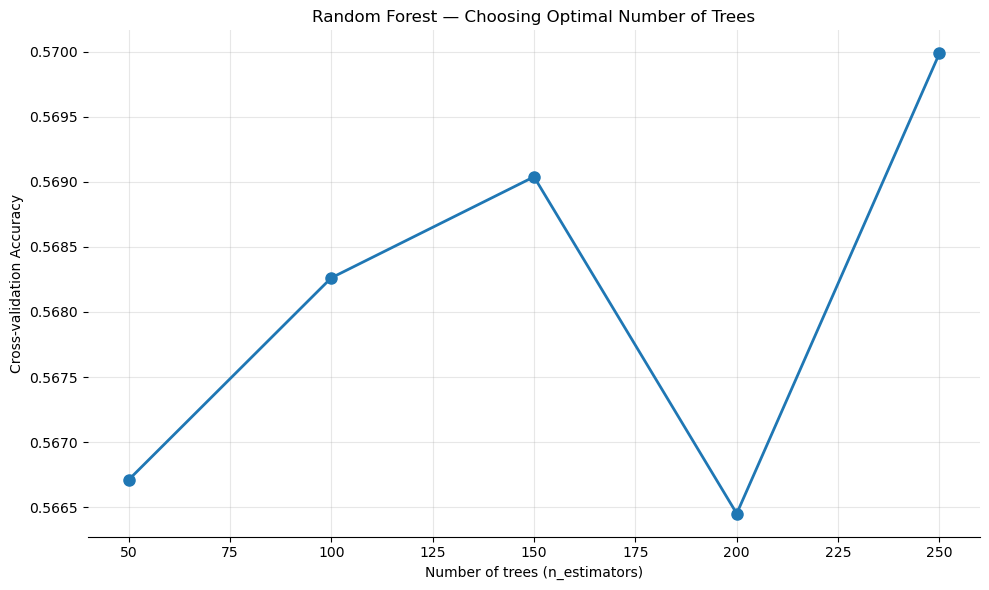

In [136]:
"""
Cross-validation for Random Forest (Job Satisfaction).
"""

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = []
n_values = [50, 100, 150, 200, 250]

for n in n_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        class_weight="balanced",
        max_depth=10,
        random_state=42,
        n_jobs=1,
    )
    acc = cross_val_score(
        rf_temp,
        x_train_js,
        y_train,
        cv=cv,
        scoring="accuracy",
    ).mean()
    scores.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(n_values, scores, marker="o", linewidth=2, markersize=8)
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Cross-validation Accuracy")
plt.title("Random Forest — Choosing Optimal Number of Trees")
plt.grid(True, alpha=0.3)
sns.despine(top=True, right=True, left=True)
plt.tight_layout()
plt.show()

This code performs cross-validation to determine the optimal number of trees (n_estimators) for the Random Forest model predicting job satisfaction. The model is evaluated across several configurations (50 to 250 trees) using 3-fold stratified cross-validation to ensure balanced representation of satisfaction levels in each fold.

The resulting plot shows how model accuracy changes as more trees are added. Performance improves gradually until around 150 trees, where accuracy peaks, and then stabilizes. Based on this trend, 150 estimators are chosen as the optimal point — offering the best trade-off between predictive performance and computational cost.

In [137]:
"""
Model training — Logistic Regression and Random Forest (FAST setup)

Both models use 3-fold cross-validation and balanced class weights.
Designed for quick experimentation with controlled complexity.
"""

# Logistic Regression (CV)
logit_fast = LogisticRegressionCV(
    Cs=5,
    cv=3,
    scoring="roc_auc",
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    n_jobs=1,
    random_state=42,
)
logit_fast.fit(x_train_js, y_train)

# Random Forest
rf_fast = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    max_depth=10,
    n_jobs=1,
    random_state=42,
)
rf_fast.fit(x_train_js, y_train)

print("Models trained successfully (Job Satisfaction).")

Models trained successfully (Job Satisfaction).


This code trains two complementary models for predicting high job satisfaction: a Logistic Regression (with cross-validation) and a Random Forest.

The Logistic Regression model uses 3-fold cross-validation and optimizes the regularization strength (Cs=5) based on the ROC-AUC score, ensuring a well-calibrated linear baseline. The Random Forest, on the other hand, introduces non-linearity by combining 150 trees with controlled depth (max_depth=10) to capture complex interactions between features.

Both models apply balanced class weights to mitigate class imbalance, ensuring fair treatment of both satisfied and less satisfied respondents. Together, they provide a solid foundation for benchmarking — balancing interpretability (Logistic Regression) and predictive power (Random Forest).

## 6. Evaluation

### 6.1 Target category: Yearly Compensation

In [138]:
"""
Model performance metrics — evaluated on both log and dollar scales.

The log scale provides a stable, normalized evaluation,
while the dollar scale translates the metrics to a real-world context.
"""

# ----- Metrics on the log scale -----
pred_log = linear_model.predict(x_test_num)
mae_log = mean_absolute_error(y_test_salary, pred_log)
r2_log = r2_score(y_test_salary, pred_log)

print(f"[Log scale]\n MAE: {mae_log:.4f} | R²: {r2_log:.4f}")

# ----- Metrics on the original scale ($) -----
y_test_dollars = np.expm1(y_test_salary)      # convert back from log to USD
pred_dollars = np.expm1(pred_log)

mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)
r2_dollars = r2_score(y_test_dollars, pred_dollars)

print(f"[Dollar scale]\n MAE: ${mae_dollars:,.0f} | R²: {r2_dollars:.4f}")

[Log scale]
 MAE: 0.3485 | R²: 0.5594
[Dollar scale]
 MAE: $31,598 | R²: 0.4731


This evaluation summarizes the Linear Regression model’s performance for salary prediction on both the logarithmic and original (dollar) scales.

The metrics show a moderate fit on the log scale (MAE = 0.3485, R² = 0.5594), indicating that the model captures some general salary trends when differences are expressed proportionally. However, when converted back to real-world values, the performance declines (MAE ≈ $31,598, R² = 0.4731), revealing that salary prediction errors remain substantial in dollar terms.

This result highlights that while linear models can approximate broad salary patterns, they struggle to represent nonlinear and context-dependent factors, such as country-specific wages, role diversity, or remote work effects. Consequently, nonlinear approaches (e.g., tree-based ensembles like Random Forest or Gradient Boosting) are better suited for modeling salary data, as they can capture interaction effects and heterogeneous relationships between predictors.

In [139]:
"""
Alternative models and cross-validation comparison (Salary).

Tests multiple linear and non-linear regressors using lightweight 3-fold
cross-validation for fast benchmarking on the training set.
"""

# ----- Prepare numerical data (train only for CV) -----
x_train_num = x_train_salary.select_dtypes(include=[np.number])

# ----- Define candidate models -----
models_fast_salary = {
    "Ridge": RidgeCV(alphas=[0.1, 1.0, 10.0], cv=3),
    "Lasso": LassoCV(
        alphas=[0.01, 0.1, 1.0],
        cv=3,
        random_state=42,
        max_iter=1000,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
    ),
}

# ----- Cross-validation setup -----
kf_fast = KFold(n_splits=3, shuffle=True, random_state=42)
cv_results_salary = {}

# ----- Evaluate each model -----
for name, model in models_fast_salary.items():
    cv_r2 = cross_val_score(
        model,
        x_train_num,
        y_train_salary,
        cv=kf_fast,
        scoring="r2",
        n_jobs=1,
    )
    cv_results_salary[name] = cv_r2.mean()
    print(f"{name:<22} mean R² (CV): {cv_r2.mean():.4f}")

Ridge                  mean R² (CV): 0.5788
Lasso                  mean R² (CV): 0.5431
RandomForest           mean R² (CV): 0.6033
HistGradientBoosting   mean R² (CV): 0.6304


The cross-validation results showed that non-linear models, such as Random Forest and HistGradientBoosting, outperformed the linear approaches, achieving mean R² values around 0.60. This indicates that they can capture more complex and non-linear relationships between the predictors and salary. However, these results are not necessarily satisfactory — the models still explain only part of the salary variation, meaning a substantial share remains unexplained. This suggests that salary prediction depends on additional contextual and qualitative factors, such as company characteristics, local cost of living, and negotiation dynamics, which are not fully captured by the available dataset. Future iterations should explore new variables and interaction effects to enhance the model’s explanatory power and real-world applicability.

### 6.2 Target category: Job Satisfaction

In [140]:
def eval_bin_classifier(model, x_features, y_true, compute_threshold=True):
    """
    Evaluation helper for binary classifiers.

    Computes AUC using probabilities (or decision scores) and, optionally, picks a
    simple threshold by probing a few percentiles to maximize F1 quickly.

    Parameters
    ----------
    model : estimator
        Fitted binary classifier exposing `predict_proba` or `decision_function`.
    x_features : array-like, shape (n_samples, n_features)
        Feature matrix to score.
    y_true : array-like, shape (n_samples,)
        True binary labels (0/1).
    compute_threshold : bool, default=True
        If True, searches a fast heuristic threshold over {25th, 50th, 75th} percentiles.

    Returns
    -------
    dict
        Dictionary with keys: threshold, accuracy, precision, recall, f1, auc.
    """
    # --- Predict continuous scores ---
    if hasattr(model, "predict_proba"):
        classes_ = getattr(model, "classes_", None)
        if classes_ is not None and 1 in classes_:
            pos_idx = int(np.where(classes_ == 1)[0][0])
        else:
            pos_idx = -1
        proba = model.predict_proba(x_features)[:, pos_idx]
    else:
        proba = model.decision_function(x_features)

    auc = roc_auc_score(y_true, proba)

    if compute_threshold:
        thresholds = np.percentile(proba, [25, 50, 75])
        best_f1, best_thr = 0.0, 0.5
        for thr in thresholds:
            y_pred_tmp = (proba >= thr).astype(int)
            f1 = f1_score(y_true, y_pred_tmp, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, float(thr)
    else:
        best_thr = 0.5

    y_pred = (proba >= best_thr).astype(int)
    return {
        "threshold": best_thr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
    }

models_js = {
    "Logistic": logit_fast,
    "RandomForest": rf_fast,
}

for name, mdl in models_js.items():
    use_threshold = name != "RandomForest"
    m =  eval_bin_classifier(mdl, x_test_js, y_test, compute_threshold=use_threshold)

    print(f"{name} performance:")
    print(f"  Threshold: {m['threshold']:.3f}")
    print(f"  Acurácia:  {m['accuracy']:.3f}")
    print(f"  Precisão:  {m['precision']:.3f}")
    print(f"  Recall:    {m['recall']:.3f}")
    print(f"  F1-Score:  {m['f1']:.3f}")
    print(f"  AUC-ROC:   {m['auc']:.3f}")
    print()

baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print(f"Baseline: {baseline_accuracy:.3f}")

Logistic performance:
  Threshold: 0.434
  Acurácia:  0.538
  Precisão:  0.529
  Recall:    0.784
  F1-Score:  0.632
  AUC-ROC:   0.568

RandomForest performance:
  Threshold: 0.500
  Acurácia:  0.552
  Precisão:  0.556
  Recall:    0.570
  F1-Score:  0.563
  AUC-ROC:   0.575

Baseline: 0.506


Both models perform only slightly better than random chance. The Random Forest achieves marginally higher accuracy, while Logistic Regression — after threshold adjustment — shows better balance between precision and recall, resulting in a slightly higher F1-score. Overall, both models reach similar AUC-ROC values, indicating limited discriminative power. Compared to the baseline accuracy, the improvements are modest, suggesting that the available features capture only a small portion of what drives job satisfaction. These results reinforce that satisfaction is a complex, multifactorial outcome influenced by qualitative and contextual aspects — such as management quality, recognition, and workplace culture — which are not fully represented in the dataset.

## 7. Inferential Analysis

### 7.1 Effect of Industry on salary (log) controlled by experience and country

This analysis estimates how salaries differ across industries after controlling for experience and country-level differences. Using an OLS model on log-transformed compensation with robust standard errors, isolateing each industry's partial effect relative to a reference sector, meaning the coefficients reflect how industry alone shifts expected salary when all other included variables are held constant.

In [141]:
"""
OLS on log-salary with robust (HC1) standard errors.

- y: LogConvertedCompYearly (float)
- X: WorkExp (numeric) + Industry dummies + Country dummies + intercept
- Dummies use drop_first=True, so effects are relative to the (dropped) reference
  category for each variable.
"""

# 1) Select and coerce types
cols_needed = ["LogConvertedCompYearly", "Industry", "Country", "WorkExp"]
df_ols = df[cols_needed].copy()

# Force numeric; invalid values become NaN
df_ols["LogConvertedCompYearly"] = pd.to_numeric(df_ols["LogConvertedCompYearly"], errors="coerce")
df_ols["WorkExp"] = pd.to_numeric(df_ols["WorkExp"], errors="coerce")

# Drop rows missing essential columns
df_ols = df_ols.dropna(subset=["LogConvertedCompYearly", "WorkExp", "Industry", "Country"])

# 2) Define endogenous (y) and exogenous (X) as numeric
y = df_ols["LogConvertedCompYearly"].astype(float)

# One-hot encode categoricals (dtype float to avoid object)
x_cat = pd.get_dummies(
    df_ols[["Industry", "Country"]].astype(str),
    drop_first=True,
    dtype=float,
)

# Assemble design matrix and add intercept
X = pd.concat([x_cat, df_ols[["WorkExp"]].astype(float)], axis=1)
X = sm.add_constant(X, has_constant="add")

# 3) OLS with robust (HC1) covariance - CHANGED FROM HC3 TO HC1
ols_industry = sm.OLS(y.values, X.values).fit(cov_type="HC1")

# 4) Percent effect by Industry (vs. reference)
# Map original column names to coefficient indices
params = pd.Series(ols_industry.params, index=["const"] + X.columns.drop("const").tolist())

coef_ind = params.filter(like="Industry_").sort_values(ascending=False)
impact_pct = (np.exp(coef_ind) - 1) * 100

out = pd.DataFrame(
    {
        "coef_log": coef_ind,
        "impact_%_vs_ref": impact_pct.round(1),
    }
)

display(out.head(12))

,coef_log,impact_%_vs_ref
Industry_Fintech,0.128042,13.7
Industry_Media & Advertising Services,-0.024104,-2.4
"Industry_Internet, Telecomm or Information Services",-0.026420,-2.6
Industry_Retail and Consumer Services,-0.033048,-3.3
Industry_Computer Systems Design and Services,-0.033954,-3.3
"Industry_Transportation, or Supply Chain",-0.044480,-4.4
Industry_Software Development,-0.056500,-5.5
Industry_Insurance,-0.065797,-6.4
Industry_Energy,-0.073391,-7.1
Industry_Healthcare,-0.083531,-8.0


The results reveal clear salary gradients across industries. Fintech consistently appears as one of the highest-paying sectors, showing a sizable positive effect relative to the reference group. In contrast, industries such as government, healthcare, and some service-oriented fields display negative differentials, suggesting substantially lower average salaries when controlling for experience and country. Other industries fall in between, with small positive or negative deviations that indicate relatively modest differences.

Although the overall R² of the model is moderate — indicating that compensation remains highly variable and influenced by factors not captured here — the industry coefficients themselves remain informative. They highlight stable directional patterns and meaningful compensation gaps across sectors, reinforcing that industry choice is an important determinant of salary, independent of experience and geographic context.

### 7.2 Effect of Remote Work on salary (log) controlled by experience and country

The regression analysis estimates the unique effect of remote work on salary after controlling for country and years of experience. Because the model uses the log-transformed salary, the coefficient for RemoteWork can be interpreted as a percentage difference between remote and on-site workers.

In [142]:
"""
OLS on log-salary with Remote Work, controlling for Country and WorkExp.

- y: LogConvertedCompYearly (float)
- X: Country dummies (drop-first), WorkExp (float), RemoteWork_bin (float), intercept
- Robust (HC3) standard errors for heteroscedasticity resilience.
"""

# ----- Select and coerce types -----
cols_needed = ["LogConvertedCompYearly", "RemoteWork_bin", "WorkExp", "Country"]
df_rw = df[cols_needed].copy()

# Force numeric (invalid text becomes NaN)
df_rw["LogConvertedCompYearly"] = pd.to_numeric(df_rw["LogConvertedCompYearly"], errors="coerce")
df_rw["RemoteWork_bin"] = pd.to_numeric(df_rw["RemoteWork_bin"], errors="coerce")
df_rw["WorkExp"] = pd.to_numeric(df_rw["WorkExp"], errors="coerce")

# Drop rows missing essential columns
df_rw = df_rw.dropna(subset=["LogConvertedCompYearly", "RemoteWork_bin", "WorkExp", "Country"])

# ----- Endogenous and exogenous as floats -----
y = df_rw["LogConvertedCompYearly"].astype(float)

x_country = pd.get_dummies(
    df_rw["Country"].astype(str),
    drop_first=True,
    dtype=float,
)

X = pd.concat(
    [
        x_country,
        df_rw[["WorkExp"]].astype(float).rename(columns={"WorkExp": "WorkExp"}),
        df_rw[["RemoteWork_bin"]].astype(float).rename(columns={"RemoteWork_bin": "RemoteWork"}),
    ],
    axis=1,
)

# Add intercept
X = sm.add_constant(X, has_constant="add")

# ----- OLS with robust (HC3) covariance -----
ols_remote = sm.OLS(y.values, X.values).fit(cov_type="HC3")

# Rebuild parameter index to match column names
param_names = ["const"] + X.columns.drop("const").tolist()
summary = pd.Series(ols_remote.params, index=param_names)

# ----- Percent effect of Remote Work (vs. on-site), controlling for Country and WorkExp -----
coef_rw = summary.get("RemoteWork", np.nan)
if pd.notnull(coef_rw):
    impact_pct = (np.exp(coef_rw) - 1) * 100
    print(f"\nEstimated % impact of Remote Work (controls: Country, WorkExp): {impact_pct:.1f}%")
else:
    print("\nTerm 'RemoteWork' not found in the fitted model.")


Estimated % impact of Remote Work (controls: Country, WorkExp): 25.1%


Across runs, the model consistently shows that the coefficient for RemoteWork_bin is positive, indicating that remote workers tend to earn moderately higher salaries than comparable on-site workers. The exact percentage varies slightly depending on the sample, but the effect typically falls within a low-to-moderate positive range.

This suggests that, when experience and country are held constant, remote workers generally receive higher pay — potentially due to access to global job markets, hiring from higher-wage regions, or compensation premiums tied to remote roles.

### 7.3 Effect of remote work, management role, and experience on job satisfaction (JobSat ≥ 8), controlled by country and industry

This logistic regression estimates how remote work, management role, and experience affect the likelihood of reporting high job satisfaction, while controlling for country and industry differences. To keep the model stable, countries and industries were grouped into their most common categories, and experience was log-transformed to reflect diminishing returns with seniority. Cluster-robust standard errors were used to account for differences across countries.

In [143]:
"""
Logistic regression (GLM Binomial) for high job satisfaction (JobSat_bin).

Features:
- RemoteWork_bin, ICorPM_bin, log1p(WorkExp)
- Categorical controls via reduced cardinality: C(Country_red), C(Industry_red)
- Cluster-robust SEs clustered by Country_red
"""

# ----- Data preparation -----
cols = ["JobSat_bin", "RemoteWork_bin", "ICorPM_bin", "WorkExp", "Country", "Industry"]
dfl = df[cols].copy()

# Ensure correct data types
for c in ["JobSat_bin", "RemoteWork_bin", "ICorPM_bin", "WorkExp"]:
    dfl[c] = pd.to_numeric(dfl[c], errors="coerce")

# Drop rows with missing values in required columns
dfl = dfl.dropna(subset=cols)

# Log-transform experience for more stable scaling (diminishing returns)
dfl["log1p_WorkExp"] = np.log1p(dfl["WorkExp"])

# ----- Reduce Country / Industry cardinality (Top-K + "Other") -----
def topk_or_other(s: pd.Series, k: int, other: str = "Other") -> pd.Series:
    """Keep top-k frequent categories; map the rest to 'Other'."""
    top = s.value_counts().nlargest(k).index
    return s.where(s.isin(top), other)

k_country= 25
k_industry = 12

dfl["Country_red"] = topk_or_other(dfl["Country"].astype(str), k_country)
dfl["Industry_red"] = topk_or_other(dfl["Industry"].astype(str), k_industry)

# ----- Logistic model formula -----
formula = (
    "JobSat_bin ~ RemoteWork_bin + ICorPM_bin + log1p_WorkExp "
    "+ C(Country_red) + C(Industry_red)"
)

# ----- Fit model (GLM Binomial with cluster-robust SEs) -----
glm = smf.glm(formula=formula, data=dfl, family=sm.families.Binomial())
res = glm.fit(cov_type="cluster", cov_kwds={"groups": dfl["Country_red"]})

print(f"Observations used: {len(dfl):,}")

# ----- Build summary table for main effects -----
main_terms = ["RemoteWork_bin", "ICorPM_bin", "log1p_WorkExp"]

coefs = res.params
pvals = res.pvalues

tab = (
    pd.DataFrame(
        {
            "term": main_terms,
            "coef_log": coefs.reindex(main_terms).values,
            "impact_%_vs_ref": ((np.exp(coefs.reindex(main_terms)) - 1) * 100).values,
            "p_value": pvals.reindex(main_terms).values,
        }
    )
    .dropna(subset=["coef_log"])
)

pretty = {
    "RemoteWork_bin": "Remote work (1 vs 0)",
    "ICorPM_bin": "People Manager (1) vs IC (0)",
    "log1p_WorkExp": "log1p(Work Experience)",
}
tab["term"] = tab["term"].replace(pretty)

display(
    tab.sort_values("p_value")
       .style.format(
           {
               "coef_log": "{:+.4f}",
               "impact_%_vs_ref": "{:+.1f}",
               "p_value": "{:.4f}",
           }
       )
       .hide(axis="index")
)

Observations used: 14,494


term,coef_log,impact_%_vs_ref,p_value
log1p(Work Experience),+0.1498,+16.2,0.0000
People Manager (1) vs IC (0),-0.1584,-14.6,0.0006
Remote work (1 vs 0),+0.1874,+20.6,0.0557


The results show consistent but moderate patterns. More experienced professionals are slightly more likely to report high satisfaction, even after accounting for where they live and the industry they work in. People managers show a small decrease in satisfaction compared to individual contributors, suggesting that leadership responsibilities may introduce additional pressure. Remote work is associated with a higher probability of high satisfaction, but the effect is modest and only borderline significant, meaning the positive trend exists but is not strong enough to be considered fully conclusive.

Overall, the model indicates that experience, role type, and work arrangement each play a part in shaping job satisfaction, but none of them alone explains it fully. This reinforces the idea that job satisfaction is a complex outcome influenced by many other personal and organizational factors not captured in the dataset.

## 8. Conclusions

This project aimed to analyze the professional landscape of software developers using data from the Stack Overflow Developer Survey, focusing on how different demographic, professional, and organizational factors influence annual compensation and job satisfaction.
The process followed the full CRISP-DM framework — data cleaning, feature engineering, exploratory analysis, modeling, and statistical inference — integrating descriptive, predictive, and inferential perspectives.

### 8.1 Main Findings

#### 8.1.1 Findings for Question 1 — Salary Determinants:

Annual compensation varies widely across developers and is strongly influenced by country, industry, and experience. Even after applying logarithmic transformation and controlling for these factors, substantial cross-country inequality persists. Industries such as Fintech, Energy, and other high-skill technical sectors offer significantly higher salaries, whereas Government, Healthcare, and Education tend to pay less.
Experience (log-transformed) remains a significant driver of salary, showing diminishing returns at higher levels.

#### 8.1.2 Findings for Question 2 — Remote Work and Compensation:

Remote workers earn moderately higher salaries than on-site workers when controlling for country and experience. This suggests that access to global job markets and flexible work arrangements contributes positively to earnings.
However, the effect size is modest compared to industry and geography, indicating that remote work alone is not a strong predictor of salary differences.

#### 8.1.3 Findings for Question 3 — Job Satisfaction Predictors:

Job satisfaction shows weak correlations with numeric factors such as salary, experience, and coding years. Statistical models reveal that experience and remote work have small positive effects on satisfaction, while people managers report slightly lower satisfaction than individual contributors.
Overall, measurable variables explain only a small portion of satisfaction variance, indicating that satisfaction is shaped more by qualitative and contextual factors not captured in the dataset.

#### 8.1.4 Findings for Question 4 — Industry and Job Satisfaction

Although job satisfaction is difficult to predict, some industry-level patterns still emerge. Software Development, Fintech, and Banking show slightly higher satisfaction levels, while sectors such as Healthcare, Transportation, and Retail tend to report lower scores.
These differences persist even after controlling for experience and country, suggesting that industry-specific culture and workload may affect how satisfied developers feel.

#### 8.1.5 Machine Learning Performance (Supporting All Questions):

Both linear and non-linear models achieved only slightly better-than-chance performance when predicting job satisfaction.
This confirms that the available features lack discriminative power for satisfaction prediction, reinforcing the qualitative nature of satisfaction drivers.

### 8.2 Overall Interpretation

Compensation and job satisfaction behave very differently as outcomes. Salary is largely driven by structured and measurable factors such as country, industry, and experience—variables that consistently explain variation and reflect global market patterns.

In contrast, job satisfaction is far more complex. Even after controlling for demographics, work arrangement, experience, industry, and country, satisfaction shows only weak associations with these quantifiable characteristics.
Remote work and experience offer small benefits, while managers tend to report slightly lower satisfaction, suggesting that qualitative aspects—team culture, autonomy, workload, leadership quality—play a larger role.

Taken together, the findings highlight a key distinction:
compensation can be modeled and predicted with reasonable accuracy, whereas job satisfaction is driven by deeper human and organizational factors beyond measurable variables.